## Libraries

In [53]:
import os

# Must be set BEFORE CUDA/cuBLAS initializes for deterministic cuBLAS matmul.
# If this kernel already has CUDA initialized (e.g. you've run cells before
# adding this), these two env vars won't take effect until you RESTART THE
# KERNEL.

os.environ["PYTHONHASHSEED"] = "42"
os.environ["CUBLAS_WORKSPACE_CONFIG"] = ":4096:8"

import json
import pickle
import random
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import uproot
import matplotlib.pyplot as plt
import optuna
import torch
import torch.nn as nn
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import roc_auc_score, roc_curve

RANDOM_STATE = 42

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")


def set_seed(seed: int = RANDOM_STATE):

    """
    Full determinism, not just seeding: also pins cuDNN to deterministic
    kernels, disables its autotuner, and asks torch to error out (rather than
    silently fall back) on any op without a deterministic implementation.
    `cudnn.benchmark = False` can cost a bit of throughput - autotuning
    normally picks the fastest kernel for the input shape - an acceptable
    trade for bit-reproducible runs. Determinism is only guaranteed on the
    SAME machine / CUDA / torch version - it is not portable across hardware
    or library versions.

    NOTE: this notebook's training loop batches by indexing GPU-resident
    tensors directly (torch.randperm for shuffling) rather than a
    DataLoader/TensorDataset - there's no multiprocess data-loading worker
    to seed separately, so set_seed()'s torch.manual_seed/cuda.manual_seed_all
    already covers the shuffling order.
    """

    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False
    torch.use_deterministic_algorithms(True)


set_seed(RANDOM_STATE)

print(f"Using device: {DEVICE}")


Using device: cuda


In [54]:
# ---------------------------------------------------------------------------
# Paths - 1 lepton + 2 taus, Run 2 and Run 3 (same source files as
# Final_Notebooks/1L2Tau_Master_Pipeline.ipynb, so the AUC is directly
# comparable to the XGBoost baseline).
# ---------------------------------------------------------------------------

BASE_DIR_RUN2 = Path("PPSSP_2026/1l2tau/run2")
BASE_DIR_RUN3 = Path("PPSSP_2026/1l2tau/run3")

# Active run used by downstream cells by default.
BASE_DIR = BASE_DIR_RUN2
ACTIVE_RUN = "Run 2"
TREE_NAME = "AnalysisMiniTree"

# ---------------------------------------------------------------------------
# Preselection (see repo README.md, "1 Lepton 2 Taus")
# ---------------------------------------------------------------------------

PRESELECTION = "(n_b_jet == 0) & (n_jet >= 2)"

# ---------------------------------------------------------------------------
# Processes: filename + label (1 = signal, 0 = background)
# ---------------------------------------------------------------------------

FILES = {
    "signal_ggF": ("signal_ggF.root", 1),
    "signal_VBF": ("signal_VBF.root", 1),
    "Diboson":    ("diboson.root",    0),
    "Zjets":      ("Zjets.root",      0),
    "Wjets":      ("Wjets.root",      0),
    "ttbar":      ("ttbar.root",      0),
    "tops":       ("tops.root",       0),
    "SingleH":    ("singleH.root",    0),
    "Vgamma":     ("Vgamma.root",     0),
    "VVV":        ("VVV.root",        0),
}

WEIGHT_PARTS = ["weight", "weights"]  # raw branches; w_phys = their product
EVENT_ID_BRANCH = "eventNumber"        # bookkeeping only - NEVER a feature (see BLOCK_SUBSTR)

# ---------------------------------------------------------------------------
# Leakage-free feature-selection policy (identical to the XGBoost master
# pipeline, so the two models see the same information).
# ---------------------------------------------------------------------------

BLOCK_SUBSTR = ["weight", "effsf", "_ff", "truth", "istrue", "fake", "anti",
                "dsid", "eventnumber", "_RNNTight", "_isOS", "_d0sig", "pass"]
BLOCK_EXACT = {
    "n_b_jet", "pass1l2tau", "hhml_subchannelflavor",
    "tau1_RNNJetScoreSigTrans", "tau2_RNNJetScoreSigTrans",
    "pair_isOStaus", "pair_isOSleptau", "tau2_baseline_RNNTight", "l1_d0sig", "tau1_charge", "tau2_charge", "mZ_veto", "tau1_decayMode", "tau2_decayMode", "tau1_nprong", "tau2_nprong"
}

BLOCK_EXACT_LOWER = {b.lower() for b in BLOCK_EXACT}


def is_feature(branch: str) -> bool:

    """True if `branch` is safe to use as a training feature (see policy above)."""

    lb = branch.lower()
    return lb not in BLOCK_EXACT_LOWER and not any(s.lower() in lb for s in BLOCK_SUBSTR)


# ---------------------------------------------------------------------------
# K-fold knobs - shared with every other notebook in this project (see
# assign_folds below). N_OPTUNA_INNER_FOLDS is smaller than N_FOLDS
# deliberately: NN training is far more expensive per-fold than XGBoost's,
# so the Optuna search itself uses fewer folds than the final OOF rotation
# (which always uses the full N_FOLDS) - an efficiency tradeoff, not a
# methodology difference.
# ---------------------------------------------------------------------------

N_FOLDS = 5                # outer K-fold CV - fold = eventNumber % N_FOLDS
N_OPTUNA_TRIALS = 15
N_OPTUNA_INNER_FOLDS = 2   # folds used INSIDE the Optuna search only


## Data Loading Helpers

In [55]:
def discover_common_features(base_dir, files=FILES, tree_name=TREE_NAME):
    
    """
    Branches common to EVERY process file in `base_dir`, filtered through`is_feature`.
    """

    common = None

    for fname, _ in files.values():
        keys = set(uproot.open({str(Path(base_dir) / fname): tree_name}).keys())
        common = keys if common is None else common & keys

    features = sorted(b for b in common if is_feature(b))

    print(f"{len(features)} candidate features (common to all {len(files)} processes, leakage-free)")

    return features


def load_run_data(base_dir, features, files=FILES, weight_parts=WEIGHT_PARTS,
                   preselection=PRESELECTION, tree_name=TREE_NAME,
                   event_id_branch=EVENT_ID_BRANCH, verbose=True):

    """
    Read every process file under `base_dir`, apply the preselection at
    read time, and concatenate into one DataFrame with bookkeeping columns:
      - w_phys  : physical event weight = weight * weights
      - label   : 1 = signal, 0 = background
      - process : originating process name
      - eventNumber : read alongside the features (never used as one - see
        BLOCK_SUBSTR/EVENT_ID_BRANCH) so `assign_folds` can build a
        deterministic fold assignment downstream.
    """

    base_dir = Path(base_dir)
    dfs = []

    for proc, (fname, label) in files.items():

        tree = uproot.open({str(base_dir / fname): tree_name})
        df = tree.arrays(features + weight_parts + [event_id_branch], cut=preselection, library="pd")
        df["w_phys"] =  df["weights"] * df["weight"]
        df["label"] = label
        df["process"] = proc
        dfs.append(df)

        if verbose:
            print(f"{proc:12s}: {len(df):>8d} events after preselection")

    return pd.concat(dfs, ignore_index=True)


def clean_data(data, features, verbose=True):

    """
    Post-concat cleaning: drop constant/empty features, then mask sentinel
    values (< -100, e.g. -999) to NaN. Returns (cleaned_data, updated_features);
    operates on a copy, does not mutate the input DataFrame.
    """

    data = data.copy()
    nun = data[features].nunique()
    const = nun[nun <= 1].index.tolist()
    features = [f for f in features if f not in const]
    data = data.drop(columns=const)
    
    if verbose:
        print(f"Dropped {len(const)} constant/empty features:\n  {sorted(const)}")

    for f in features:
        m = data[f] < -100
        if m.any():
            if verbose:
                print(f"  sentinel -> NaN: {f} ({m.mean():.1%})")
            data[f] = data[f].mask(m)

    if verbose:
        print(f"\n{len(features)} final features")
        print(f"Total: {len(data)} events | signal = {(data.label==1).sum()} | "
              f"background = {(data.label==0).sum()}")
        print(f"Yield (w_phys): signal = {data.loc[data.label==1,'w_phys'].sum():.2f} | "
              f"background = {data.loc[data.label==0,'w_phys'].sum():.2f}")
    return data, features


## K-Fold + Weight-Balancing Helper Library

Same 5-fold `eventNumber % N_FOLDS` convention, weight handling and
significance objective (`significance_scan`) as the other refactored
notebooks in this project (`Final_Notebooks/MLP.ipynb`,
`Final_Notebooks/1L2Tau_Master_Pipeline.ipynb`, etc). `make_fit_weights` is
copy-pasted BYTE-FOR-BYTE from the canonical source
(`Final_Notebooks/PNN.ipynb`). `prepare_fold_tensors`/`run_kfold_nn` are the
NN-specific additions (per-fold imputer/scaler + GPU tensor conversion, and
the 5-fold OOF production loop).


In [56]:
def assign_folds(df, event_col=EVENT_ID_BRANCH, n_folds=N_FOLDS):

    """Deterministic fold assignment: fold = eventNumber % n_folds. The SAME
    rule is applied identically across every notebook/channel/run/track in
    this project, so OOF score arrays stay event-aligned everywhere."""

    df = df.copy()
    df["fold"] = (df[event_col].to_numpy() % n_folds).astype("int8")
    return df


def compute_process_yield_targets(df, weight_col="w_phys", process_col="process"):

    """Full-sample SIGNED yield per process, computed ONCE on the complete
    dataset (before any negative-weight drop)."""

    return df.groupby(process_col)[weight_col].sum().to_dict()


def rescale_weights_by_yield(df, target_yields, weight_col="w_phys",
                              process_col="process", min_target=1e-6):

    """Per-process: rescale the rows in `df` (already negative-weight
    filtered) so their weight-sum matches `target_yields[process]`."""

    df = df.copy()
    for proc, sub in df.groupby(process_col):
        target = target_yields.get(proc, sub[weight_col].sum())
        if target <= min_target:
            warnings.warn(
                f"rescale_weights_by_yield: process '{proc}' has full-sample "
                f"signed yield {target:.6g} <= {min_target:g} (mostly-negative "
                f"weights?) - clamping target to {min_target:g} to avoid a "
                f"negative/degenerate rescale factor."
            )
            target = min_target
        kept_sum = sub[weight_col].sum()
        if kept_sum != 0:
            df.loc[sub.index, weight_col] = sub[weight_col] * (target / kept_sum)
    return df


def make_fit_weights(labels, abs_weights, cell_ids=None):

    """Balance signal/background total weight and normalize the OVERALL
    mean weight to 1. If `cell_ids` is given, the balance is computed
    WITHIN each distinct cell_ids value FIRST.

    CANONICAL SOURCE: Final_Notebooks/PNN.ipynb. Copy-pasted BYTE-FOR-BYTE
    into every in-scope notebook - see assert_fit_weights_balanced below.
    """

    labels = np.asarray(labels)
    fit_weights = np.asarray(abs_weights, dtype=float).copy()

    if cell_ids is None:
        sum_signal = fit_weights[labels == 1].sum()
        sum_background = fit_weights[labels == 0].sum()
        fit_weights[labels == 1] *= sum_background / sum_signal
    else:
        cell_ids = np.asarray(cell_ids)
        for cell in np.unique(cell_ids):
            m = cell_ids == cell
            sum_signal = fit_weights[m & (labels == 1)].sum()
            sum_background = fit_weights[m & (labels == 0)].sum()
            if sum_signal > 0:
                fit_weights[m & (labels == 1)] *= sum_background / sum_signal

    fit_weights *= len(fit_weights) / fit_weights.sum()

    return fit_weights


def assert_fit_weights_balanced(fit_weights, labels, cell_ids):

    """Per-cell balance sanity check for make_fit_weights."""

    labels = np.asarray(labels)
    cell_ids = np.asarray(cell_ids)
    cells = np.unique(cell_ids)
    sig_sums = [fit_weights[(labels == 1) & (cell_ids == c)].sum() for c in cells]
    bkg_sums = [fit_weights[(labels == 0) & (cell_ids == c)].sum() for c in cells]
    assert np.allclose(sig_sums, bkg_sums), (
        "make_fit_weights: per-cell balance broken - this copy has drifted "
        "from the canonical PNN.ipynb version"
    )


def n_eff_table(df, group_cols, weight_col="w_phys"):

    """Effective event count N_eff = (sum w)^2 / sum(w^2) per group."""

    def _n_eff(w):
        w = np.asarray(w, dtype=float)
        denom = (w ** 2).sum()
        if denom == 0:
            return np.nan
        return (w.sum()) ** 2 / denom

    return df.groupby(list(group_cols))[weight_col].apply(_n_eff).rename("n_eff")


def plot_weight_balance(y, w_before, w_after, title="", save_path=None):

    """Panel A: overlaid per-event weight histograms (signal vs background),
    before vs after `make_fit_weights` balancing, log-y. Panel B: grouped
    bar chart of summed weight (signal total vs background total), before
    vs after."""

    y = np.asarray(y)
    w_before = np.asarray(w_before, dtype=float)
    w_after = np.asarray(w_after, dtype=float)

    fig, axes = plt.subplots(1, 2, figsize=(13, 5))

    ax = axes[0]
    lo = min(w_before.min(), w_after.min())
    hi = max(w_before.max(), w_after.max())
    bins = np.linspace(lo, hi, 60)
    ax.hist(w_before[y == 1], bins=bins, histtype="step", linestyle="--",
            color="crimson", linewidth=1.6, alpha=0.7, label="signal (before)")
    ax.hist(w_before[y == 0], bins=bins, histtype="step", linestyle="--",
            color="steelblue", linewidth=1.6, alpha=0.7, label="background (before)")
    ax.hist(w_after[y == 1], bins=bins, histtype="step", linestyle="-",
            color="crimson", linewidth=1.8, label="signal (after)")
    ax.hist(w_after[y == 0], bins=bins, histtype="step", linestyle="-",
            color="steelblue", linewidth=1.8, label="background (after)")
    ax.set_yscale("log")
    ax.set_xlabel("per-event weight")
    ax.set_ylabel("events (log scale)")
    ax.set_title("Per-event weight distribution")
    ax.legend(fontsize=8)
    ax.grid(alpha=0.3)

    ax = axes[1]
    sums_before = [w_before[y == 1].sum(), w_before[y == 0].sum()]
    sums_after = [w_after[y == 1].sum(), w_after[y == 0].sum()]
    x = np.arange(2)
    width = 0.35
    b1 = ax.bar(x - width / 2, sums_before, width, label="before", color="lightgray", edgecolor="black")
    b2 = ax.bar(x + width / 2, sums_after, width, label="after", color="steelblue")
    ax.bar_label(b1, fmt="%.3g", fontsize=8)
    ax.bar_label(b2, fmt="%.3g", fontsize=8)
    ax.set_xticks(x)
    ax.set_xticklabels(["signal", "background"])
    ax.set_ylabel("summed weight")
    ax.set_title("Total weight: signal vs background")
    ax.legend()
    ax.grid(axis="y", alpha=0.3)

    fig.suptitle(title)
    plt.tight_layout()

    if save_path is not None:
        save_path = Path(save_path)
        save_path.parent.mkdir(parents=True, exist_ok=True)
        fig.savefig(save_path, dpi=150)
        print(f"Saved plot -> {save_path}")
    plt.show()


def plot_scaling_before_after(train_df, features, train_medians, scaler, weights=None, title="",
                               save_path=None, feature=None):

    """Panel A: overlaid weighted-event HISTOGRAMS (exactly like
    `plot_weight_balance`'s weight histogram - single shared x-axis, log-y)
    of one representative feature's values before (raw, median-imputed) vs
    after (fitted `StandardScaler` transform). Sharing ONE axis (no z-score
    relabeling/second axis) is the point: it directly shows scaling
    physically compress the feature's spread down around 0, instead of
    hiding that behind two independently-rescaled axes that would otherwise
    make before/after look like identical shapes. Defaults to the feature
    with the largest raw std (most visibly compressed by scaling) if
    `feature` is not given. P
    
    anel B: the SAME after-scaling distribution as
    Panel A, but re-binned on its OWN x-axis (instead of the shared
    before/after axis) so the region around 0 - where scaled features
    actually live - gets much better resolution instead of being squeezed
    into a sliver by the wider raw-unit range. 
    
    Panel C: HISTOGRAM, across
    all features, of each feature's own (weighted) std before vs after -
    before is spread over orders of magnitude, after should collapse into a
    spike at the dashed std=1 reference line. `weights`, if given (e.g.
    `w_train_fit`), makes all panels reflect the actual training-weighted
    distribution the network sees rather than a plain unweighted count."""

    X_before = train_df[features].fillna(train_medians)
    X_after = pd.DataFrame(scaler.transform(X_before), columns=features, index=X_before.index)

    if weights is None:
        w = np.ones(len(X_before))
    else:
        w = np.asarray(weights, dtype=float)
    w_sum = w.sum()

    def _wmean(x):
        return (x * w).sum() / w_sum

    def _wstd(x, mean):
        return np.sqrt((w * (x - mean) ** 2).sum() / w_sum)

    feature_stds_before = pd.Series(
        {f: _wstd(X_before[f].to_numpy(), _wmean(X_before[f].to_numpy())) for f in features}
    )

    feature_stds_after = pd.Series(
        {f: _wstd(X_after[f].to_numpy(), _wmean(X_after[f].to_numpy())) for f in features}
    )

    if feature is None:
        feature = feature_stds_before.idxmax()

    feature_before = X_before[feature].to_numpy()
    feature_after = X_after[feature].to_numpy()

    fig, axes = plt.subplots(1, 3, figsize=(19, 5))

    ax = axes[0]
    lo = min(feature_before.min(), feature_after.min())
    hi = max(feature_before.max(), feature_after.max())
    bins = np.linspace(lo, hi, 60)
    ax.hist(feature_before, bins=bins, weights=w, histtype="step", linestyle="--",
            color="dimgray", linewidth=1.6, alpha=0.9, label="before (raw, median-imputed)")
    ax.hist(feature_after, bins=bins, weights=w, histtype="step", linestyle="-",
            color="steelblue", linewidth=1.8, label="after (StandardScaler)")
    ax.axvline(0, color="crimson", linestyle="--", linewidth=1, label="target mean = 0")
    ax.set_yscale("log")
    ax.set_xlabel(f"{feature} (shared axis - raw units before, scaled units after)")
    ax.set_ylabel("weighted events (log scale)")
    ax.set_title(f"Representative feature distribution: {feature}")
    ax.legend(fontsize=8)
    ax.grid(alpha=0.3)

    ax = axes[1]
    after_lo, after_hi = feature_after.min(), feature_after.max()
    after_bins = np.linspace(after_lo, after_hi, 60)
    ax.hist(feature_after, bins=after_bins, weights=w, histtype="step", linestyle="-",
            color="steelblue", linewidth=1.8, label="after (StandardScaler)")
    ax.axvline(0, color="crimson", linestyle="--", linewidth=1, label="target mean = 0")
    ax.set_yscale("log")
    ax.set_xlabel(f"{feature} (scaled units - own axis, zoomed around 0)")
    ax.set_ylabel("weighted events (log scale)")
    ax.set_title(f"After-only distribution (own axis): {feature}")
    ax.legend(fontsize=8)
    ax.grid(alpha=0.3)

    ax = axes[2]
    lo = min(feature_stds_before.min(), feature_stds_after.min())
    hi = max(feature_stds_before.max(), feature_stds_after.max())
    std_bins = np.logspace(np.log10(max(lo, 1e-6)), np.log10(hi), 25)
    ax.hist(feature_stds_before, bins=std_bins, color="lightgray", edgecolor="black",
            alpha=0.85, label="before")
    ax.hist(feature_stds_after, bins=std_bins, histtype="step", linewidth=1.8,
            color="steelblue", label="after")
    ax.axvline(1, color="crimson", linestyle="--", linewidth=1, label="target std = 1")
    ax.set_xscale("log")
    ax.set_xlabel("per-feature std")
    ax.set_ylabel(f"# of features (out of {len(features)})")
    ax.set_title("Spread of per-feature std, across all features")
    ax.legend(fontsize=8)
    ax.grid(alpha=0.3)

    fig.suptitle(title)
    plt.tight_layout()

    if save_path is not None:
        save_path = Path(save_path)
        save_path.parent.mkdir(parents=True, exist_ok=True)
        fig.savefig(save_path, dpi=150)
        print(f"Saved plot -> {save_path}")
    plt.show()


def prepare_fold_data(data, features, target_yields, cell_cols=(), n_folds=N_FOLDS, k=0):

    """Build the train/val/test row partitions and per-row training weights
    for outer-fold rotation `k`: test=(fold==k), val=(fold==(k+1)%n_folds),
    train=the remaining n_folds-2 folds."""

    val_fold = (k + 1) % n_folds
    test_mask = data["fold"] == k
    val_mask = data["fold"] == val_fold
    train_mask = ~(test_mask | val_mask)

    train_full = data.loc[train_mask]
    val_full = data.loc[val_mask]

    train_keep = train_full.loc[train_full["w_phys"] >= 0].copy()
    val_keep = val_full.loc[val_full["w_phys"] >= 0].copy()

    train_keep = rescale_weights_by_yield(train_keep, target_yields)
    val_keep = rescale_weights_by_yield(val_keep, target_yields)

    def _cell_ids(df):
        if not cell_cols:
            return None
        return df[list(cell_cols)].astype(str).agg("_".join, axis=1).to_numpy()

    cell_train = _cell_ids(train_keep)
    w_train_fit = make_fit_weights(train_keep["label"].to_numpy(), train_keep["w_phys"].to_numpy(), cell_ids=cell_train)
    if cell_train is not None:
        assert_fit_weights_balanced(w_train_fit, train_keep["label"].to_numpy(), cell_train)

    cell_val = _cell_ids(val_keep)
    w_val_fit = make_fit_weights(val_keep["label"].to_numpy(), val_keep["w_phys"].to_numpy(), cell_ids=cell_val)

    return {
        "k": k, "val_fold": val_fold,
        "train_df": train_keep, "val_df": val_keep, "test_df": data.loc[test_mask].copy(),
        "w_train_fit": w_train_fit, "w_val_fit": w_val_fit,
        "n_dropped_train": len(train_full) - len(train_keep),
        "n_dropped_val": len(val_full) - len(val_keep),
    }


def significance_scan(y_true, scores, w_phys, n_thr=200, min_bkg=1.0):

    """Max Asimov significance Z over score cuts. Uses SIGNED w_phys. This
    is the OPTUNA OBJECTIVE for every model in this project."""

    thr = np.quantile(scores, np.linspace(0, 1, n_thr))
    best_z, best_t = 0.0, None
    for t in thr:
        sel = scores >= t
        S = w_phys[sel & (y_true == 1)].sum()
        B = w_phys[sel & (y_true == 0)].sum()
        if S <= 0 or B < min_bkg:
            continue
        z = np.sqrt(2 * ((S + B) * np.log(1 + S / B) - S))
        if z > best_z:
            best_z, best_t = z, t
    return best_z, best_t


def compute_flag_cols(data, features):

    """Missingness flag columns - a property of the FULL dataset, computed
    ONCE so every fold's model has the same input width."""

    nan_any = data[features].isna()
    return nan_any.columns[nan_any.any()].tolist()


def make_flags(X_raw, flag_cols):

    """0/1 missingness flags for `flag_cols`, kept unscaled."""

    f = X_raw[flag_cols].isna().astype(np.float32)
    f.columns = [f"{c}__isnan" for c in flag_cols]
    return f


def prepare_fold_tensors(data, features, flag_cols, target_yields, cell_cols=(), n_folds=N_FOLDS, k=0):

    """Extends prepare_fold_data with per-fold median-impute + StandardScaler
    (fit on THAT FOLD's train split only) + __isnan flags + GPU-resident
    tensor conversion."""

    fd = prepare_fold_data(data, features, target_yields, cell_cols=cell_cols, n_folds=n_folds, k=k)
    train_df, val_df, test_df = fd["train_df"], fd["val_df"], fd["test_df"]

    train_medians = train_df[features].median()
    X_train_imp = train_df[features].fillna(train_medians)
    X_val_imp = val_df[features].fillna(train_medians)
    X_test_imp = test_df[features].fillna(train_medians)

    scaler = StandardScaler()
    X_train_scaled = np.hstack([scaler.fit_transform(X_train_imp), make_flags(train_df[features], flag_cols).to_numpy()])
    X_val_scaled = np.hstack([scaler.transform(X_val_imp), make_flags(val_df[features], flag_cols).to_numpy()])
    X_test_scaled = np.hstack([scaler.transform(X_test_imp), make_flags(test_df[features], flag_cols).to_numpy()])

    fd["X_train_t"] = torch.tensor(X_train_scaled, dtype=torch.float32, device=DEVICE)
    fd["y_train_t"] = torch.tensor(train_df["label"].to_numpy(), dtype=torch.float32, device=DEVICE)
    fd["w_train_fit_t"] = torch.tensor(fd["w_train_fit"], dtype=torch.float32, device=DEVICE)
    fd["w_train_abs_t"] = torch.tensor(train_df["w_phys"].to_numpy(), dtype=torch.float32, device=DEVICE)

    fd["X_val_t"] = torch.tensor(X_val_scaled, dtype=torch.float32, device=DEVICE)
    fd["y_val_t"] = torch.tensor(val_df["label"].to_numpy(), dtype=torch.float32, device=DEVICE)
    fd["w_val_abs_t"] = torch.tensor(np.abs(val_df["w_phys"].to_numpy()), dtype=torch.float32, device=DEVICE)

    fd["X_test_t"] = torch.tensor(X_test_scaled, dtype=torch.float32, device=DEVICE)
    fd["scaler"] = scaler
    fd["train_medians"] = train_medians
    fd["n_features_model"] = X_train_scaled.shape[1]

    return fd


def run_kfold_nn(data, features, flag_cols, best_params, target_yields, cell_cols=(),
                  n_folds=N_FOLDS, label=""):

    """5-fold rotation: trains one model per fold (frozen hyperparameters),
    scores every event with a model that never trained on it. Returns
    (oof_df, models, scalers, medians_list)."""

    oof_scores = np.full(len(data), np.nan)
    models, scalers, medians_list = [], [], []

    for k in range(n_folds):
        fd = prepare_fold_tensors(data, features, flag_cols, target_yields,
                                   cell_cols=cell_cols, n_folds=n_folds, k=k)

        fold_model, _, _, _, _ = train_model(
            fd["X_train_t"], fd["y_train_t"], fd["w_train_fit_t"],
            fd["X_val_t"], fd["y_val_t"], fd["w_val_abs_t"],
            hidden_sizes=best_params["hidden_sizes"], dropout=best_params["dropout"],
            lr=best_params["lr"], weight_decay=best_params["weight_decay"],
            batch_size=best_params["batch_size"], patience=best_params["patience"],
            w_train_eval_data=fd["w_train_abs_t"], verbose=False,
        )
        models.append(fold_model)
        scalers.append(fd["scaler"])
        medians_list.append(fd["train_medians"])

        fold_model.eval()
        with torch.no_grad():
            test_scores = torch.sigmoid(fold_model(fd["X_test_t"])).cpu().numpy()
        test_df = fd["test_df"]
        oof_scores[np.flatnonzero((data["fold"] == k).to_numpy())] = test_scores

        auc_test = roc_auc_score(test_df["label"], test_scores, sample_weight=test_df["w_phys"].abs())
        z_test, _ = significance_scan(test_df["label"].to_numpy(), test_scores, test_df["w_phys"].to_numpy())
        print(f"[{label}] fold {k}: test_fold={k} val_fold={fd['val_fold']} | "
              f"train n={len(fd['train_df'])} (dropped {fd['n_dropped_train']} neg) | "
              f"test weighted AUC = {auc_test:.4f} | test significance Z = {z_test:.3f}")

    oof_cols = ["process", "label", "fold", EVENT_ID_BRANCH, "w_phys"]
    if "run" in data.columns:
        oof_cols.append("run")
    oof_df = data[oof_cols].copy()
    oof_df["score"] = oof_scores

    oof_auc = roc_auc_score(oof_df["label"], oof_df["score"], sample_weight=oof_df["w_phys"].abs())
    oof_z, oof_thr = significance_scan(oof_df["label"].to_numpy(), oof_df["score"].to_numpy(), oof_df["w_phys"].to_numpy())
    print(f"[{label}] OOF weighted AUC (pooled) = {oof_auc:.4f}")
    print(f"[{label}] OOF max Asimov Z (pooled) = {oof_z:.3f} at score cut = {oof_thr:.4f}")

    return oof_df, models, scalers, medians_list


def plot_oof_roc(oof_df, title=""):

    """OOF ROC over the full sample, plus a fold-spread band."""

    y = oof_df["label"].to_numpy()
    s = oof_df["score"].to_numpy()
    w = oof_df["w_phys"].abs().to_numpy()
    fpr, tpr, _ = roc_curve(y, s, sample_weight=w)
    auc = roc_auc_score(y, s, sample_weight=w)

    grid = np.linspace(0, 1, 200)
    fold_tprs = []
    for k in sorted(oof_df["fold"].unique()):
        sub = oof_df[oof_df["fold"] == k]
        if sub["label"].nunique() < 2:
            continue
        f_k, t_k, _ = roc_curve(sub["label"], sub["score"], sample_weight=sub["w_phys"].abs())
        fold_tprs.append(np.interp(grid, f_k, t_k))
    fold_tprs = np.array(fold_tprs)

    fig, ax = plt.subplots(figsize=(6, 6))
    ax.plot(fpr, tpr, color="steelblue", linewidth=2, label=f"OOF ROC (AUC={auc:.4f})")
    if len(fold_tprs):
        ax.fill_between(grid, fold_tprs.min(axis=0), fold_tprs.max(axis=0), color="steelblue",
                         alpha=0.2, label="fold spread (min-max)")
    ax.plot([0, 1], [0, 1], "--", color="gray")
    ax.set(xlabel="False-positive rate", ylabel="True-positive rate", title=title, xlim=(0, 1), ylim=(0, 1))
    ax.legend(loc="lower right")
    plt.show()
    return auc


def save_track_artifacts_nn(models, scalers, medians_list, features, flag_cols, best_params, oof_df, base_dir, track_name):

    """NN analogue of the XGBoost pipelines' save_track_artifacts."""

    base_dir = Path(base_dir)
    base_dir.mkdir(parents=True, exist_ok=True)
    for k, m in enumerate(models):
        torch.save(m.state_dict(), base_dir / f"model_{track_name}_fold{k}.pt")
    with open(base_dir / f"preprocess_{track_name}.pkl", "wb") as f:
        pickle.dump({"scalers": scalers, "medians": medians_list}, f)
    with open(base_dir / f"features_{track_name}.json", "w") as f:
        json.dump({"features": features, "flag_cols": flag_cols}, f)
    with open(base_dir / f"hyperparams_{track_name}.json", "w") as f:
        json.dump(best_params, f)
    oof_path = base_dir / f"oof_scores_{track_name}.csv"
    oof_df.to_csv(oof_path, index=False)
    print(f"Saved {len(models)} fold models + preprocessing + feature list + hyperparams + OOF scores "
          f"-> {base_dir}/ (track={track_name})")


## Load Run 2 and Run 3 Data (Shared Setup)

In [57]:
# Run 2 load

candidate_features_run2 = discover_common_features(BASE_DIR_RUN2)
data_run2 = load_run_data(BASE_DIR_RUN2, candidate_features_run2)
data_run2, features_run2 = clean_data(data_run2, candidate_features_run2)
data_run2 = assign_folds(data_run2)

# Run 3 load (prepared now; used later in a separate downstream section)

candidate_features_run3 = discover_common_features(BASE_DIR_RUN3)
data_run3 = load_run_data(BASE_DIR_RUN3, candidate_features_run3)
data_run3, features_run3 = clean_data(data_run3, candidate_features_run3)
data_run3 = assign_folds(data_run3)

# Default active dataset for downstream cells in this first pass: Run 2.

candidate_features, data, features = candidate_features_run2, data_run2, features_run2
BASE_DIR = BASE_DIR_RUN2
ACTIVE_RUN = "Run 2"

print(f"Prepared datasets: Run2={len(data_run2)} events, Run3={len(data_run3)} events")
print(f"Downstream now uses: {ACTIVE_RUN}")
print(f"\nFold sizes (fold = eventNumber % {N_FOLDS}), Run 2:")
print(data_run2["fold"].value_counts().sort_index())


74 candidate features (common to all 10 processes, leakage-free)
signal_ggF  :    67075 events after preselection
signal_VBF  :    21639 events after preselection
Diboson     :   312600 events after preselection
Zjets       :   141863 events after preselection
Wjets       :    31272 events after preselection
ttbar       :     7335 events after preselection
tops        :    62238 events after preselection
SingleH     :    11124 events after preselection
Vgamma      :    21510 events after preselection
VVV         :    14028 events after preselection
Dropped 14 constant/empty features:
  ['SumPt_l1j1j2', 'SumPt_t1t2l1', 'dR_j1j2_l1', 'dR_j1j2_t1', 'dR_j1j2_t2', 'm_jjl1', 'm_jjl1t1', 'm_jjt1', 'n_lep', 'n_tau', 'tau1_base_id', 'tau1_besline_RNNMedium_eleid', 'tau2_base_id', 'tau2_besline_RNNMedium_eleid']

60 final features
Total: 690684 events | signal = 88714 | background = 601970
Yield (w_phys): signal = 1.82 | background = 11467.29
74 candidate features (common to all 10 processes, le

## Sentinel Audit (-1)

`clean_data` only masks `< -100` sentinels (e.g. `-999`) to NaN. Some ATLAS
branches instead default to exactly `-1` for "undefined", which `clean_data`
would otherwise treat as a legitimate physical value. `-1` is also a
perfectly valid value for plenty of other branches (e.g. charges), so it
must **not** be blanket-masked - only branches where `-1` is a genuine
"undefined" sentinel (a spike at `-1` detached from the rest of the
distribution, with a gap just above it) should be added to
`NEG1_SENTINEL_FEATURES` below. The diagnostic cell prints, per feature, the
fraction of rows exactly equal to `-1` and the gap to the next-smallest
value above `-1`, to help build that set by inspection - it does not decide
automatically.

In [58]:
NEG1_SENTINEL_FEATURES = set()

neg1_rows = []

for f in features:
    vals = data[f]
    frac_neg1 = (vals == -1).mean()
    if frac_neg1 == 0:
        continue
    above = vals[vals > -1]
    gap = (above.min() - (-1)) if len(above) else np.nan
    neg1_rows.append({"feature": f, "frac_exactly_-1": frac_neg1, "gap_to_next_value_above": gap})

neg1_df = pd.DataFrame(neg1_rows).sort_values("frac_exactly_-1", ascending=False)
print(f"{len(neg1_df)} / {len(features)} features have at least one row exactly equal to -1:")
print(neg1_df.to_string(index=False))

# Apply the (currently empty) mask before the train/val/test split, so any
# features added to NEG1_SENTINEL_FEATURES later automatically flow into
# both the median-imputation and the Task-2 missingness flags below.

for f in NEG1_SENTINEL_FEATURES:
    data[f] = data[f].mask(data[f] == -1)
    
if NEG1_SENTINEL_FEATURES:
    print(f"\nMasked -1 -> NaN for: {sorted(NEG1_SENTINEL_FEATURES)}")
else:
    print("\nNEG1_SENTINEL_FEATURES is empty - no -1 values masked.")

1 / 60 features have at least one row exactly equal to -1:
  feature  frac_exactly_-1  gap_to_next_value_above
l1_charge         0.474042                      2.0

NEG1_SENTINEL_FEATURES is empty - no -1 values masked.


## Train/Validation/Test Preprocessing (Per-Fold)

Uses the same 5-fold `eventNumber % N_FOLDS` rotation as `assign_folds`
above - **not** a fixed 80/10/10 `make_3way_split`. For each outer fold `k`
(`prepare_fold_data`/`prepare_fold_tensors`): test=(fold==k),
val=(fold==(k+1)%N_FOLDS), train=the remaining `N_FOLDS-2` folds. There is
no single held-out test set - `run_kfold_nn` rotates over every fold so
each event is eventually scored by a model that never trained on it (OOF),
and it's those pooled OOF scores that report the final AUC/significance.

Neural nets (unlike XGBoost) can't handle NaN natively, so sentinel-masked
values are median-imputed (fit on THAT FOLD's train split only, refit per
fold inside `prepare_fold_tensors`) before standard scaling (`StandardScaler`,
also refit per fold). Missingness itself is informative to XGBoost (it
learns a default split direction for NaN) - imputation would erase that
signal for the MLP, so explicit `__isnan` flag columns (schema derived once
from the full dataset via `compute_flag_cols`, so every fold's model has
the same input width) are concatenated onto the scaled features to level
the field. Training weights are class-balanced and mean-normalized so the
much larger background yield doesn't dominate the loss; validation/test
weights stay as plain `|w_phys|` so AUC reflects the true class balance.


Saved plot -> PPSSP_2026/1l2tau/run2/plots/Run2WeightBalance_DNN.png


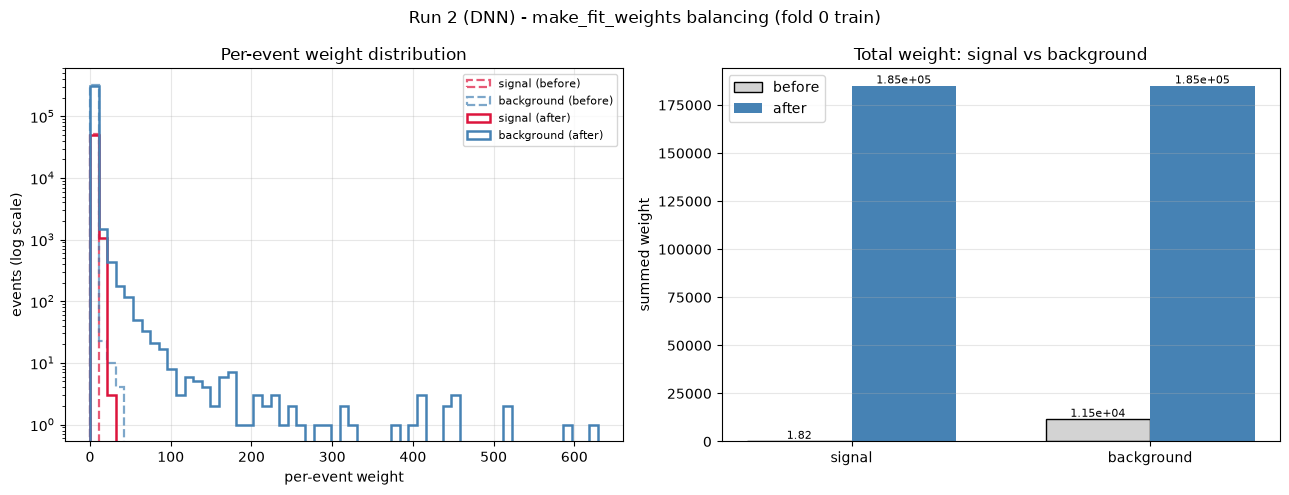

0 features had missing values in train (globally) -> added 0 __isnan flag columns (final model input width = 60 = 60 features + 0 flags)

N_eff (training sample, positive-only, post yield-rescale) by label - fold 0:
label
0     4765.991828
1    27507.190025
Name: n_eff, dtype: float64

N_eff (eval sample, signed, FULL fold-0 test partition) by label:
label
0     956.475454
1    7398.000012
Name: n_eff, dtype: float64

Dropped 44813 negative-w_phys training rows in this preview fold (kept, not abs'd, elsewhere - see prepare_fold_data).


In [59]:
# ---- Weight-balance diagnostics (Run 2, representative fold 0) ------------
PLOTS_DIR_R2 = BASE_DIR_RUN2 / "plots"
PLOTS_DIR_R2.mkdir(parents=True, exist_ok=True)

target_yields_run2 = compute_process_yield_targets(data_run2)
flag_cols_run2 = compute_flag_cols(data_run2, features_run2)
N_FEATURES_MODEL = len(features_run2) + len(flag_cols_run2)

fd0_run2 = prepare_fold_tensors(data_run2, features_run2, flag_cols_run2, target_yields_run2,
                                 cell_cols=(), n_folds=N_FOLDS, k=0)

w_before_run2 = fd0_run2["train_df"]["w_phys"].to_numpy()
w_after_run2 = fd0_run2["w_train_fit"]
y_preview_run2 = fd0_run2["train_df"]["label"].to_numpy()

plot_weight_balance(
    y_preview_run2, w_before_run2, w_after_run2,
    title="Run 2 (DNN) - make_fit_weights balancing (fold 0 train)",
    save_path=PLOTS_DIR_R2 / "Run2WeightBalance_DNN.png",
)

print(f"{len(flag_cols_run2)} features had missing values in train (globally) -> added "
      f"{len(flag_cols_run2)} __isnan flag columns (final model input width = {N_FEATURES_MODEL} = "
      f"{len(features_run2)} features + {len(flag_cols_run2)} flags)")

print("\nN_eff (training sample, positive-only, post yield-rescale) by label - fold 0:")
print(n_eff_table(fd0_run2["train_df"], ["label"]))
print("\nN_eff (eval sample, signed, FULL fold-0 test partition) by label:")
print(n_eff_table(fd0_run2["test_df"], ["label"]))
print(f"\nDropped {fd0_run2['n_dropped_train']} negative-w_phys training rows in this "
      f"preview fold (kept, not abs'd, elsewhere - see prepare_fold_data).")


Saved plot -> PPSSP_2026/1l2tau/run2/plots/Run2ScalingBeforeAfter_DNN.png


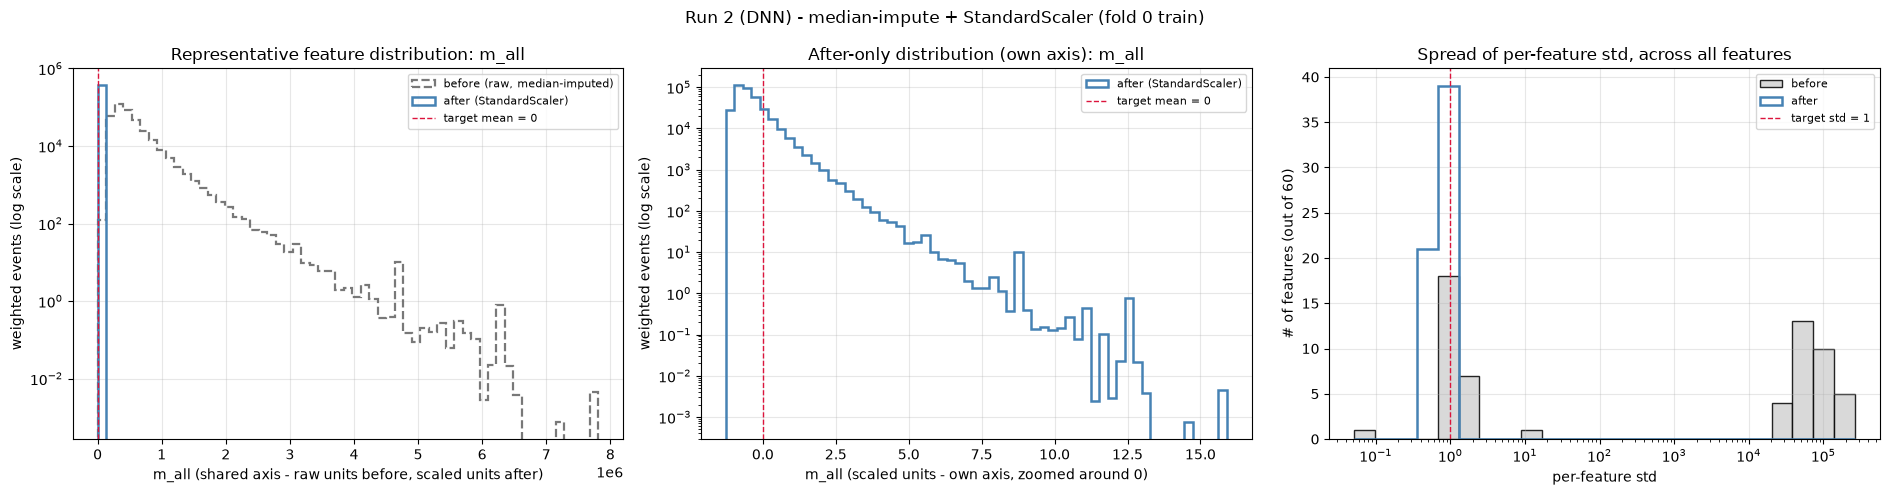

In [60]:
plot_scaling_before_after(
    fd0_run2["train_df"], features_run2, fd0_run2["train_medians"], fd0_run2["scaler"],
    weights=fd0_run2["w_train_fit"],
    title="Run 2 (DNN) - median-impute + StandardScaler (fold 0 train)",
    save_path=PLOTS_DIR_R2 / "Run2ScalingBeforeAfter_DNN.png",
)


## PyTorch Dataset & Model

In [61]:
# Model input comfortably fits in GPU memory - keep it resident there for
# the whole run instead of using a DataLoader. GPU tensors themselves now
# live inside each fold's `prepare_fold_tensors` dict (fd["X_train_t"], etc.)
# rather than as fixed globals.

BATCH_SIZE = 8192

DEFAULT_HIDDEN_SIZES = (256, 256, 128, 128, 64, 32)


class SimpleMLP(nn.Module):

    """
    A deep feed-forward binary classifier: hidden layers with ReLU
    activations and dropout, single output logit (paired with
    BCEWithLogitsLoss for numerical stability).
    """

    def __init__(self, n_features, hidden_sizes=DEFAULT_HIDDEN_SIZES, dropout=0.3):

        super().__init__()
        layers = []
        in_size = n_features

        for hidden_size in hidden_sizes:

            layers += [nn.Linear(in_size, hidden_size), nn.ReLU(), nn.Dropout(dropout)]
            in_size = hidden_size

        layers.append(nn.Linear(in_size, 1))
        self.net = nn.Sequential(*layers)

    def forward(self, x):
        return self.net(x).squeeze(-1)


def build_model(hidden_sizes=DEFAULT_HIDDEN_SIZES, dropout=0.3, n_features=None):

    """
    Factory so a hyperparameter search (or a feature-pruning retrain) can
    build a fresh model per trial without repeating the
    SimpleMLP(...).to(DEVICE) boilerplate. `n_features` defaults to the
    CURRENT track's full input width (`N_FEATURES_MODEL`, reassigned per
    track), but can be overridden when training on a feature subset.
    """

    if n_features is None:
        n_features = N_FEATURES_MODEL
    return SimpleMLP(n_features=n_features, hidden_sizes=hidden_sizes, dropout=dropout).to(DEVICE)


model = build_model(n_features=fd0_run2["n_features_model"])

print(model)


SimpleMLP(
  (net): Sequential(
    (0): Linear(in_features=60, out_features=256, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.3, inplace=False)
    (3): Linear(in_features=256, out_features=256, bias=True)
    (4): ReLU()
    (5): Dropout(p=0.3, inplace=False)
    (6): Linear(in_features=256, out_features=128, bias=True)
    (7): ReLU()
    (8): Dropout(p=0.3, inplace=False)
    (9): Linear(in_features=128, out_features=128, bias=True)
    (10): ReLU()
    (11): Dropout(p=0.3, inplace=False)
    (12): Linear(in_features=128, out_features=64, bias=True)
    (13): ReLU()
    (14): Dropout(p=0.3, inplace=False)
    (15): Linear(in_features=64, out_features=32, bias=True)
    (16): ReLU()
    (17): Dropout(p=0.3, inplace=False)
    (18): Linear(in_features=32, out_features=1, bias=True)
  )
)


## Training Loop

Weighted binary cross-entropy (per-sample weights folded in manually, since
`BCEWithLogitsLoss` has no built-in sample-weight argument), Adam optimizer,
early stopping on weighted validation AUC.

In [62]:
N_EPOCHS = 50
PATIENCE = 10
LEARNING_RATE = 1e-3


def run_epoch(model, X, y, w, criterion, optimizer, train, batch_size=BATCH_SIZE):

    """
    One pass over the GPU-resident tensors (X, y, w), split into
    `batch_size` chunks via plain tensor indexing (no DataLoader).
    """

    model.train(train)
    n = X.shape[0]
    order = torch.randperm(n, device=DEVICE) if train else torch.arange(n, device=DEVICE)

    total_loss = torch.zeros((), device=DEVICE)
    total_weight = torch.zeros((), device=DEVICE)
    all_labels, all_probs, all_weights = [], [], []

    with torch.set_grad_enabled(train):
        for start in range(0, n, batch_size):
            idx = order[start:start + batch_size]
            xb, yb, wb = X[idx], y[idx], w[idx]

            logits = model(xb)
            loss = (criterion(logits, yb) * wb).sum() / wb.sum()

            if train:
                optimizer.zero_grad()
                loss.backward()
                optimizer.step()

            total_loss += loss.detach() * wb.sum()
            total_weight += wb.sum()
            all_labels.append(yb.detach())
            all_probs.append(torch.sigmoid(logits).detach())
            all_weights.append(wb.detach())

    labels = torch.cat(all_labels).cpu().numpy()
    probs = torch.cat(all_probs).cpu().numpy()
    weights = torch.cat(all_weights).cpu().numpy()

    auc = roc_auc_score(labels, probs, sample_weight=weights)

    return (total_loss / total_weight).item(), auc


def train_model(X_train_data, y_train_data, w_train_data, X_val_data, y_val_data, w_val_data,
                 hidden_sizes=DEFAULT_HIDDEN_SIZES, dropout=0.3, lr=LEARNING_RATE, weight_decay=0.0,
                 batch_size=BATCH_SIZE, n_epochs=N_EPOCHS, patience=PATIENCE, verbose=True,
                 w_train_eval_data=None):

    """
    Build a fresh SimpleMLP(hidden_sizes, dropout) and train it with early
    stopping on weighted validation AUC. All data args are REQUIRED (no
    more defaulting to fixed module-level globals) since every fold has its
    own tensors.
    """

    w_train_eval_data = w_train_data if w_train_eval_data is None else w_train_eval_data

    trial_model = build_model(hidden_sizes=hidden_sizes, dropout=dropout, n_features=X_train_data.shape[1])
    criterion = nn.BCEWithLogitsLoss(reduction="none")
    optimizer = torch.optim.Adam(trial_model.parameters(), lr=lr, weight_decay=weight_decay)

    history = {"train_loss": [], "val_loss": [], "train_auc": [], "val_auc": [],
               "train_loss_eval": [], "train_auc_eval": []}
    best_val_auc, best_train_auc, best_train_auc_eval = -np.inf, None, None
    best_state, epochs_no_improve = None, 0

    for epoch in range(1, n_epochs + 1):

        train_loss, train_auc = run_epoch(trial_model, X_train_data, y_train_data, w_train_data, criterion, optimizer, train=True, batch_size=batch_size)
        train_loss_eval, train_auc_eval = run_epoch(trial_model, X_train_data, y_train_data, w_train_eval_data, criterion, optimizer, train=False, batch_size=batch_size)
        val_loss, val_auc = run_epoch(trial_model, X_val_data, y_val_data, w_val_data, criterion, optimizer, train=False, batch_size=batch_size)

        history["train_loss"].append(train_loss)
        history["val_loss"].append(val_loss)
        history["train_auc"].append(train_auc)
        history["val_auc"].append(val_auc)
        history["train_loss_eval"].append(train_loss_eval)
        history["train_auc_eval"].append(train_auc_eval)

        if verbose:
            print(f"Epoch {epoch:3d} | train_loss={train_loss:.4f} val_loss={val_loss:.4f} "
                  f"| train_auc={train_auc:.4f} train_auc_eval={train_auc_eval:.4f} val_auc={val_auc:.4f}")

        if val_auc > best_val_auc:
            best_val_auc, best_train_auc, best_train_auc_eval = val_auc, train_auc, train_auc_eval
            best_state, epochs_no_improve = {k: v.clone() for k, v in trial_model.state_dict().items()}, 0
        else:
            epochs_no_improve += 1
            if epochs_no_improve >= patience:
                if verbose:
                    print(f"Early stopping at epoch {epoch} (best val_auc={best_val_auc:.4f})")
                break

    trial_model.load_state_dict(best_state)
    return trial_model, history, best_val_auc, best_train_auc, best_train_auc_eval


# ---- Fold-0 preview baseline (default hyperparameters) - used only to rank
# features for the correlation-pruning stage below.
model, history, best_val_auc, best_train_auc, best_train_auc_eval = train_model(
    fd0_run2["X_train_t"], fd0_run2["y_train_t"], fd0_run2["w_train_fit_t"],
    fd0_run2["X_val_t"], fd0_run2["y_val_t"], fd0_run2["w_val_abs_t"],
    hidden_sizes=DEFAULT_HIDDEN_SIZES, w_train_eval_data=fd0_run2["w_train_abs_t"],
)

print(f"\nBest val_auc = {best_val_auc:.4f} | train_auc (dropout on) = {best_train_auc:.4f} "
      f"| train_auc_eval (dropout off, comparable) = {best_train_auc_eval:.4f}")


Epoch   1 | train_loss=0.5477 val_loss=0.5023 | train_auc=0.8148 train_auc_eval=0.8929 val_auc=0.8899
Epoch   2 | train_loss=0.4316 val_loss=0.3856 | train_auc=0.8839 train_auc_eval=0.9059 val_auc=0.9004
Epoch   3 | train_loss=0.4107 val_loss=0.3686 | train_auc=0.8960 train_auc_eval=0.9129 val_auc=0.9072
Epoch   4 | train_loss=0.3977 val_loss=0.3384 | train_auc=0.9030 train_auc_eval=0.9160 val_auc=0.9093


Epoch   5 | train_loss=0.3884 val_loss=0.3578 | train_auc=0.9073 train_auc_eval=0.9196 val_auc=0.9122
Epoch   6 | train_loss=0.3833 val_loss=0.3217 | train_auc=0.9100 train_auc_eval=0.9214 val_auc=0.9136
Epoch   7 | train_loss=0.3775 val_loss=0.3530 | train_auc=0.9125 train_auc_eval=0.9236 val_auc=0.9148
Epoch   8 | train_loss=0.3743 val_loss=0.3469 | train_auc=0.9140 train_auc_eval=0.9245 val_auc=0.9155
Epoch   9 | train_loss=0.3715 val_loss=0.3565 | train_auc=0.9156 train_auc_eval=0.9259 val_auc=0.9161
Epoch  10 | train_loss=0.3685 val_loss=0.3643 | train_auc=0.9170 train_auc_eval=0.9274 val_auc=0.9174
Epoch  11 | train_loss=0.3661 val_loss=0.3494 | train_auc=0.9181 train_auc_eval=0.9287 val_auc=0.9172
Epoch  12 | train_loss=0.3618 val_loss=0.3847 | train_auc=0.9200 train_auc_eval=0.9298 val_auc=0.9180
Epoch  13 | train_loss=0.3606 val_loss=0.3796 | train_auc=0.9204 train_auc_eval=0.9311 val_auc=0.9187
Epoch  14 | train_loss=0.3590 val_loss=0.4032 | train_auc=0.9214 train_auc_eval=0.

## Optuna Hyperparameter Search

Bayesian search (TPE sampler + median pruning) over `hidden_sizes`,
`dropout`, `lr`, `weight_decay`, `batch_size` and `patience`, scored by mean
expected significance (Asimov Z, high-score tail, `significance_scan`) -
the SAME objective family used by the XGBoost master pipelines. Runs on
`N_OPTUNA_INNER_FOLDS` folds; `trial.report`/pruning happens per-EPOCH.
Hyperparameters are frozen once here and reused for all `N_FOLDS` outer
folds later (`run_kfold_nn`).


/tmp/ipykernel_108467/730644711.py:86: ExperimentalWarning: Argument ``multivariate`` is an experimental feature. The interface can change in the future.
  sampler=optuna.samplers.TPESampler(seed=seed, multivariate=True),


  0%|          | 0/15 [00:00<?, ?it/s]


[dnn_opt_run2] completed trials: 15
[dnn_opt_run2] best mean CV significance Z (2 eventNumber-folds): 0.10515
[dnn_opt_run2] best parameters:
    hidden_sizes: 256_256_128_128_64_32
    dropout: 0.300558154239596
    lr: 0.005643008062644067
    weight_decay: 4.047499625897054e-05
    batch_size: 16384
    patience: 15


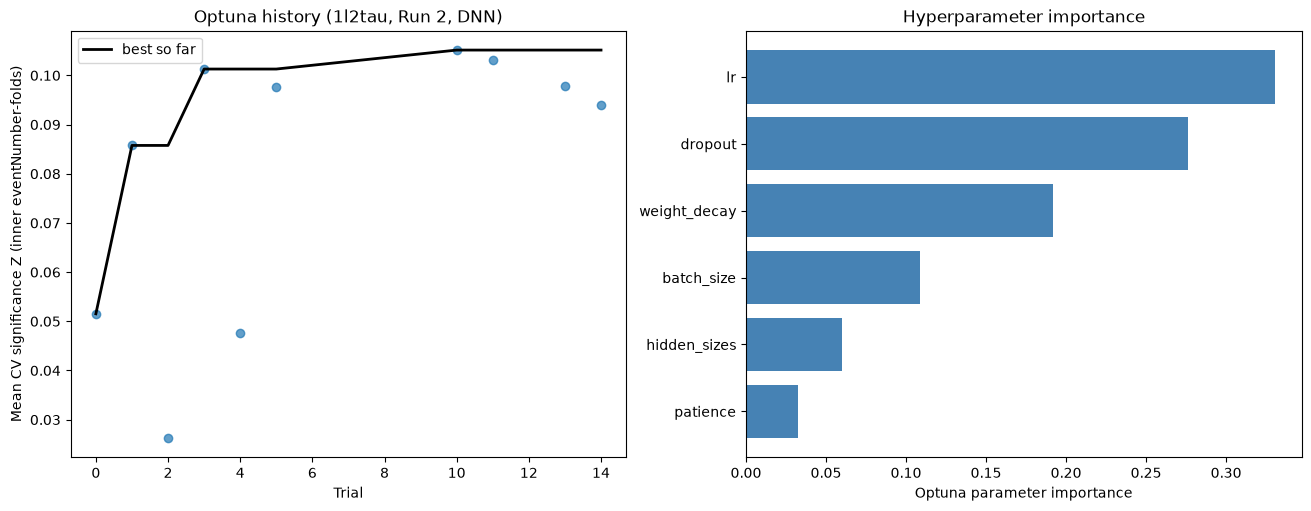


Tuned fold-0 preview: val_auc=0.9221 | hidden_sizes=(256, 256, 128, 128, 64, 32)


In [63]:
def train_model_for_search(trial, step_offset, hidden_sizes, dropout, lr, weight_decay,
                            batch_size, patience, X_train_data, y_train_data, w_train_data,
                            X_val_data, y_val_data, w_val_data, w_val_signed, n_epochs=40):

    """
    Optuna-search-only training loop: same architecture/early-stopping
    convention as `train_model`, but additionally reports the per-EPOCH
    validation significance (Asimov Z) to `trial` and raises
    `optuna.TrialPruned()` if the pruner says to stop. `step_offset` lets
    the caller give every fold's epochs a distinct, monotonically
    increasing `step` within the same trial. Returns the best-epoch
    significance Z reached in this fold.
    """

    trial_model = build_model(hidden_sizes=hidden_sizes, dropout=dropout, n_features=X_train_data.shape[1])
    criterion = nn.BCEWithLogitsLoss(reduction="none")
    optimizer = torch.optim.Adam(trial_model.parameters(), lr=lr, weight_decay=weight_decay)

    best_val_auc, best_z, epochs_no_improve = -np.inf, 0.0, 0

    for epoch in range(1, n_epochs + 1):
        run_epoch(trial_model, X_train_data, y_train_data, w_train_data, criterion, optimizer, train=True, batch_size=batch_size)
        _, val_auc = run_epoch(trial_model, X_val_data, y_val_data, w_val_data, criterion, optimizer, train=False, batch_size=batch_size)

        trial_model.eval()
        with torch.no_grad():
            val_scores = torch.sigmoid(trial_model(X_val_data)).cpu().numpy()
        z, _ = significance_scan(y_val_data.cpu().numpy(), val_scores, w_val_signed)

        trial.report(z, step=step_offset + epoch)
        if trial.should_prune():
            raise optuna.TrialPruned()

        if val_auc > best_val_auc:
            best_val_auc, best_z, epochs_no_improve = val_auc, z, 0
        else:
            epochs_no_improve += 1
            if epochs_no_improve >= patience:
                break

    return best_z, epoch


def run_optuna_search_nn(data, features, flag_cols, target_yields, cell_cols=(),
                          n_trials=N_OPTUNA_TRIALS, n_inner_folds=N_OPTUNA_INNER_FOLDS,
                          n_epochs=40, study_name="dnn_opt", seed=RANDOM_STATE):

    """
    Bayesian hyperparameter search over hidden_sizes/dropout/lr/weight_decay/
    batch_size/patience, scored by mean per-fold validation significance
    (Asimov Z). Includes the notebook's own deep DEFAULT_HIDDEN_SIZES
    architecture as one of the candidate hidden_sizes choices, alongside
    shallower options. KNOWN, ACCEPTED LEAK - NOT NESTED CV (same caveat as
    the XGBoost pipelines).
    """

    def objective(trial):
        hidden_choice = trial.suggest_categorical(
            "hidden_sizes", ["64", "128_64", "256_128", "128_64_32", "256_256_128_128_64_32"]
        )
        hidden_sizes = tuple(int(x) for x in hidden_choice.split("_"))
        dropout = trial.suggest_float("dropout", 0.1, 0.5)
        lr = trial.suggest_float("lr", 1e-4, 1e-2, log=True)
        weight_decay = trial.suggest_float("weight_decay", 1e-6, 1e-2, log=True)
        batch_size = trial.suggest_categorical("batch_size", [2048, 4096, 8192, 16384])
        patience = trial.suggest_int("patience", 5, 15)

        fold_zs, step_offset = [], 0
        for k in range(n_inner_folds):
            fd = prepare_fold_tensors(data, features, flag_cols, target_yields,
                                       cell_cols=cell_cols, n_folds=N_FOLDS, k=k)
            w_val_signed = fd["val_df"]["w_phys"].to_numpy()
            z, epochs_run = train_model_for_search(
                trial, step_offset, hidden_sizes, dropout, lr, weight_decay, batch_size, patience,
                fd["X_train_t"], fd["y_train_t"], fd["w_train_fit_t"],
                fd["X_val_t"], fd["y_val_t"], fd["w_val_abs_t"], w_val_signed, n_epochs=n_epochs,
            )
            fold_zs.append(z)
            step_offset += epochs_run

        return float(np.mean(fold_zs))

    optuna.logging.set_verbosity(optuna.logging.WARNING)
    study = optuna.create_study(
        direction="maximize",
        sampler=optuna.samplers.TPESampler(seed=seed, multivariate=True),
        pruner=optuna.pruners.MedianPruner(n_startup_trials=5, n_warmup_steps=1),
        study_name=study_name,
    )
    study.optimize(objective, n_trials=n_trials, show_progress_bar=True, gc_after_trial=True)

    print(f"\n[{study_name}] completed trials: {len(study.trials)}")
    print(f"[{study_name}] best mean CV significance Z ({n_inner_folds} eventNumber-folds): {study.best_value:.5f}")
    print(f"[{study_name}] best parameters:")
    for name, value in study.best_params.items():
        print(f"    {name}: {value}")
    return study


def params_from_study_nn(study):

    """Extract the frozen hyperparameter dict from a completed Optuna study."""

    bp = dict(study.best_params)
    bp["hidden_sizes"] = tuple(int(x) for x in bp["hidden_sizes"].split("_"))
    return bp


def plot_optuna_diagnostics_nn(study, title_suffix=""):

    """2-panel diagnostic: Optuna trial history + hyperparameter importance."""

    trials = study.trials_dataframe()
    complete = trials.loc[trials["state"] == "COMPLETE"].copy()
    param_importance = optuna.importance.get_param_importances(study)

    fig, axes = plt.subplots(1, 2, figsize=(13, 5), constrained_layout=True)

    axes[0].plot(complete["number"], complete["value"], "o", alpha=0.7)
    axes[0].plot(complete["number"], complete["value"].cummax(), color="black", linewidth=2, label="best so far")
    axes[0].set(xlabel="Trial", ylabel="Mean CV significance Z (inner eventNumber-folds)", title=f"Optuna history {title_suffix}")
    axes[0].legend()

    names = list(param_importance)
    values = [param_importance[name] for name in names]
    axes[1].barh(names[::-1], values[::-1], color="steelblue")
    axes[1].set(xlabel="Optuna parameter importance", title="Hyperparameter importance")

    plt.show()


study_run2 = run_optuna_search_nn(data_run2, features_run2, flag_cols_run2, target_yields_run2,
                                   study_name="dnn_opt_run2")
best_params_run2 = params_from_study_nn(study_run2)
best_hidden_sizes = best_params_run2["hidden_sizes"]
plot_optuna_diagnostics_nn(study_run2, title_suffix="(1l2tau, Run 2, DNN)")

# ---- Refit the fold-0 preview model with the tuned hyperparameters -------
model, history, best_val_auc, best_train_auc, best_train_auc_eval = train_model(
    fd0_run2["X_train_t"], fd0_run2["y_train_t"], fd0_run2["w_train_fit_t"],
    fd0_run2["X_val_t"], fd0_run2["y_val_t"], fd0_run2["w_val_abs_t"],
    hidden_sizes=best_params_run2["hidden_sizes"], dropout=best_params_run2["dropout"],
    lr=best_params_run2["lr"], weight_decay=best_params_run2["weight_decay"],
    batch_size=best_params_run2["batch_size"], patience=best_params_run2["patience"],
    w_train_eval_data=fd0_run2["w_train_abs_t"], verbose=False,
)
print(f"\nTuned fold-0 preview: val_auc={best_val_auc:.4f} | hidden_sizes={best_hidden_sizes}")


## Evaluation

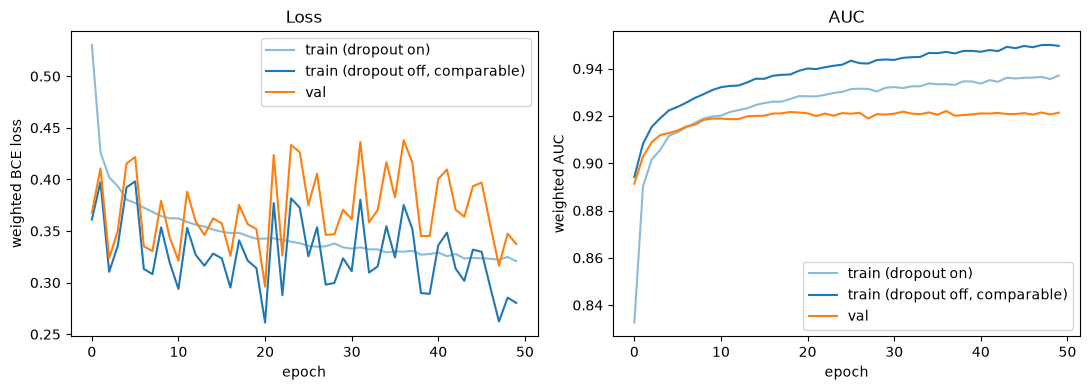

Final weighted AUC (fold-0 preview): train=0.9471 val=0.9221


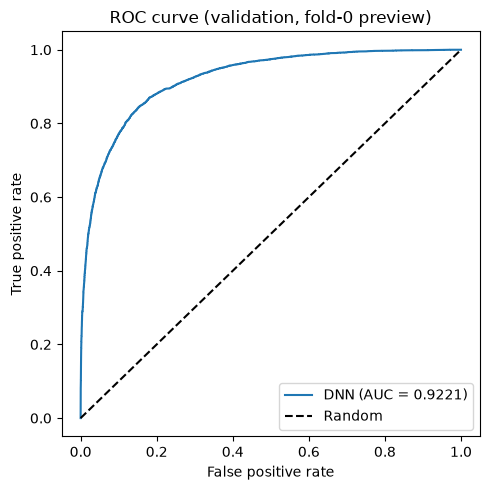

In [64]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

axes[0].plot(history["train_loss"], label="train (dropout on)", color="tab:blue", alpha=0.5)
axes[0].plot(history["train_loss_eval"], label="train (dropout off, comparable)", color="tab:blue")
axes[0].plot(history["val_loss"], label="val", color="tab:orange")
axes[0].set_xlabel("epoch")
axes[0].set_ylabel("weighted BCE loss")
axes[0].set_title("Loss")
axes[0].legend()

axes[1].plot(history["train_auc"], label="train (dropout on)", color="tab:blue", alpha=0.5)
axes[1].plot(history["train_auc_eval"], label="train (dropout off, comparable)", color="tab:blue")
axes[1].plot(history["val_auc"], label="val", color="tab:orange")
axes[1].set_xlabel("epoch")
axes[1].set_ylabel("weighted AUC")
axes[1].set_title("AUC")
axes[1].legend()

plt.tight_layout()
plt.show()

model.eval()
with torch.no_grad():
    train_probs = torch.sigmoid(model(fd0_run2["X_train_t"])).cpu().numpy()
    val_probs = torch.sigmoid(model(fd0_run2["X_val_t"])).cpu().numpy()

y_train, y_val = fd0_run2["train_df"]["label"].to_numpy(), fd0_run2["val_df"]["label"].to_numpy()
w_train_abs = fd0_run2["train_df"]["w_phys"].to_numpy()
w_val_abs = np.abs(fd0_run2["val_df"]["w_phys"].to_numpy())

auc_train = roc_auc_score(y_train, train_probs, sample_weight=w_train_abs)
auc_val = roc_auc_score(y_val, val_probs, sample_weight=w_val_abs)

print(f"Final weighted AUC (fold-0 preview): train={auc_train:.4f} val={auc_val:.4f}")

fpr, tpr, _ = roc_curve(y_val, val_probs, sample_weight=w_val_abs)
plt.figure(figsize=(5, 5))
plt.plot(fpr, tpr, label=f"DNN (AUC = {auc_val:.4f})")
plt.plot([0, 1], [0, 1], "k--", label="Random")
plt.xlabel("False positive rate")
plt.ylabel("True positive rate")
plt.title("ROC curve (validation, fold-0 preview)")
plt.legend()
plt.tight_layout()
plt.show()


## Feature Importance (Permutation)

XGBoost has a built-in gain-based importance, but a neural net doesn't - the
model-agnostic equivalent is **permutation importance**: shuffle one
feature's column across events (destroying its relationship with the
label) and measure how much the weighted validation AUC drops. Repeated a
few times per feature and averaged for stability. Computed on the
validation set so it isn't inflated by the model simply memorizing train.

In [65]:
def permutation_importance(model, X, y, w, features, n_repeats=5, random_state=RANDOM_STATE):

    """
    Model-agnostic feature importance: for each feature, shuffle its column
    across events `n_repeats` times and measure the average drop in weighted
    AUC relative to the unshuffled baseline. `X`, `y`, `w` must already be
    GPU-resident tensors (e.g. X_val_t/y_val_t/w_val_t) with columns in the
    same order as `features`. Returns a pandas Series (feature -> mean AUC
    drop), sorted descending - a bigger drop means the model relies on that
    feature more.
    """

    rng = np.random.default_rng(random_state)
    model.eval()

    y_np = y.cpu().numpy()
    w_np = w.cpu().numpy()

    with torch.no_grad():
        baseline_probs = torch.sigmoid(model(X)).cpu().numpy()

    baseline_auc = roc_auc_score(y_np, baseline_probs, sample_weight=w_np)
    print(f"Baseline weighted AUC: {baseline_auc:.4f}")

    mean_drops = []
    
    for i, feat in enumerate(features):
        drops = []
        for _ in range(n_repeats):
            perm = torch.as_tensor(rng.permutation(X.shape[0]), device=X.device)
            X_perm = X.clone()
            X_perm[:, i] = X_perm[perm, i]

            with torch.no_grad():
                probs = torch.sigmoid(model(X_perm)).cpu().numpy()
            auc = roc_auc_score(y_np, probs, sample_weight=w_np)
            drops.append(baseline_auc - auc)

        mean_drops.append(np.mean(drops))

    return pd.Series(mean_drops, index=features, name="auc_drop").sort_values(ascending=False)


def plot_importance_bar(imp, top_n=30, title="", color="lightblue", save_path=None):

    """
    Horizontal bar chart of the top `top_n` features by importance (same
    convention as the XGBoost master pipeline's plot_importance_bar). If
    `save_path` is given, the figure is written to disk (parent directories
    created as needed, dpi=150) before being displayed.
    """

    n = min(top_n, len(imp))

    fig, ax = plt.subplots(figsize=(8, max(4, 0.28 * n)))
    imp.head(top_n)[::-1].plot.barh(ax=ax, color=color)
    ax.set_xlabel("Weighted AUC drop when shuffled")
    ax.set_title(title)
    plt.tight_layout()

    if save_path is not None:
        save_path = Path(save_path)
        save_path.parent.mkdir(parents=True, exist_ok=True)
        fig.savefig(save_path, dpi=150)
        print(f"Saved plot -> {save_path}")

    plt.show()

Baseline weighted AUC: 0.9221
Saved plot -> PPSSP_2026/1l2tau/run2/plots/Run2ImportanceFull_DNN.png


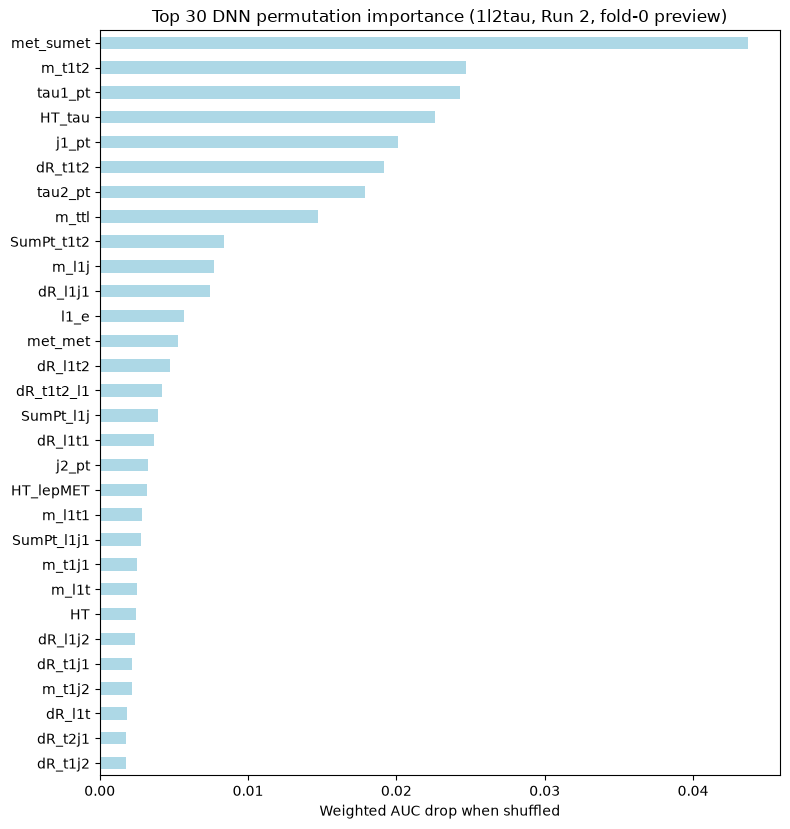

met_sumet     0.043678
m_t1t2        0.024687
tau1_pt       0.024281
HT_tau        0.022572
j1_pt         0.020109
dR_t1t2       0.019189
tau2_pt       0.017900
m_ttl         0.014719
SumPt_t1t2    0.008361
m_l1j         0.007682
dR_l1j1       0.007419
l1_e          0.005667
met_met       0.005286
dR_l1t2       0.004769
dR_t1t2_l1    0.004211
Name: auc_drop, dtype: float64

In [66]:
importance = permutation_importance(model, fd0_run2["X_val_t"], fd0_run2["y_val_t"], fd0_run2["w_val_abs_t"],
                                     features, n_repeats=5)
plot_importance_bar(importance, top_n=30, title="Top 30 DNN permutation importance (1l2tau, Run 2, fold-0 preview)",
                     save_path=PLOTS_DIR_R2 / "Run2ImportanceFull_DNN.png")
importance.head(15)


## Correlation Pruning & Retraining

Mirrors the XGBoost master pipeline's correlation-pruning stage: rank
features by importance (permutation importance here, gain there), look at
Pearson correlation among the top candidates separately for signal and
background, then walk the ranked list keeping a feature only if it isn't
too correlated (`|corr| > 0.75`) with a more important feature already kept.
The MLP is then retrained from scratch on the decorrelated feature set, and
again restricted to just the top 15 features, to see how much (if any)
performance is lost by cutting redundant/less useful inputs.

In [67]:
TOP_N_IMPORTANCE = 30   # candidate pool size, before correlation pruning
CORR_THRESH = 0.75      # |corr| above this -> considered redundant
N_KEEP = 20             # decorrelated features to keep in the main pruned model


def top_pairs(corr, thr=0.70):

    """Feature pairs with |Pearson correlation| > thr, most-correlated first."""
    
    upper = corr.abs().where(np.triu(np.ones_like(corr, dtype=bool), k=1))
    return upper.stack().sort_values(ascending=False).loc[lambda s: s > thr]


def grouped_correlations(data, feats, group_col, group_values):

    """
    Pearson correlation of `feats`, computed separately for each value of
    `group_col` (label 0/1 = background/signal here) - correlations
    genuinely differ between groups, so pruning must look at both, not just
    the pooled correlation.
    """

    return {v: data.loc[data[group_col] == v, feats].corr() for v in group_values}


def plot_group_correlations(corrs, names, feats, suptitle="", save_path=None):

    """
    Side-by-side correlation heatmaps, one per entry in `corrs`/`names`. If
    `save_path` is given, the figure is written to disk (parent directories
    created as needed, dpi=150) before being displayed.
    """

    fig, axes = plt.subplots(1, len(corrs), figsize=(11 * len(corrs), 10), constrained_layout=True)
    axes = np.atleast_1d(axes)
    im = None
    for ax, corr, name in zip(axes, corrs, names):
        im = ax.imshow(corr.values, vmin=-1, vmax=1, cmap="PuOr")
        ax.set_xticks(range(len(feats)))
        ax.set_xticklabels(feats, rotation=90, fontsize=7)
        ax.set_yticks(range(len(feats)))
        ax.set_yticklabels(feats, fontsize=7)
        ax.set_title(name)
    
    fig.colorbar(im, ax=list(axes), shrink=0.8, label="Pearson correlation")

    if suptitle:
        fig.suptitle(suptitle)

    if save_path is not None:
        save_path = Path(save_path)
        save_path.parent.mkdir(parents=True, exist_ok=True)
        fig.savefig(save_path, dpi=150)
        print(f"Saved plot -> {save_path}")

    plt.show()


def prune_correlated(top_feats, corr_max, corr_thresh=CORR_THRESH, n_keep=N_KEEP):

    """
    Walk `top_feats` (most -> least important). Keep a feature unless it is
    more than `corr_thresh` correlated with a more-important feature already
    kept (i.e. it's redundant with something better). Stop once `n_keep`
    survivors are found.
    """

    kept, dropped = [], []
    for feat in top_feats:
        redundant_with = next((k for k in kept if corr_max.loc[feat, k] > corr_thresh), None)
        if redundant_with is None:
            kept.append(feat)
        else:
            dropped.append((feat, redundant_with, corr_max.loc[feat, redundant_with]))
        if len(kept) == n_keep:
            break

    if len(kept) < n_keep:
        print(f"WARNING: only {len(kept)}/{n_keep} survivors found within the top "
              f"{len(top_feats)} candidates - raise the candidate pool or lower corr_thresh.")

    print(f"Kept {len(kept)} decorrelated features (most -> least important):")
    for i, feat in enumerate(kept, 1):
        print(f"  {i:2d}. {feat}")
    print(f"\nDropped {len(dropped)} redundant features (|corr| > {corr_thresh} with a more important feature):")
    for feat, because_of, corr_val in dropped:
        print(f"  {feat:15s} -> redundant with {because_of:15s} (|corr| = {corr_val:.3f})")

    return kept, dropped


def subset_feature_tensors_fold(fd, feature_subset, all_features):

    """
    Slice a fold's already-scaled train/val/test GPU tensors (from
    `prepare_fold_tensors`) down to `feature_subset` (columns picked by
    name, matching `all_features`'s order) - the __isnan flag columns (if
    any) are intentionally dropped, matching this notebook's original
    correlation-pruning behavior.
    """

    idx = [all_features.index(f) for f in feature_subset]
    idx_t = torch.as_tensor(idx, device=DEVICE)
    return fd["X_train_t"][:, idx_t], fd["X_val_t"][:, idx_t], fd["X_test_t"][:, idx_t]


Saved plot -> PPSSP_2026/1l2tau/run2/plots/Run2CorrelationTop30_DNN.png


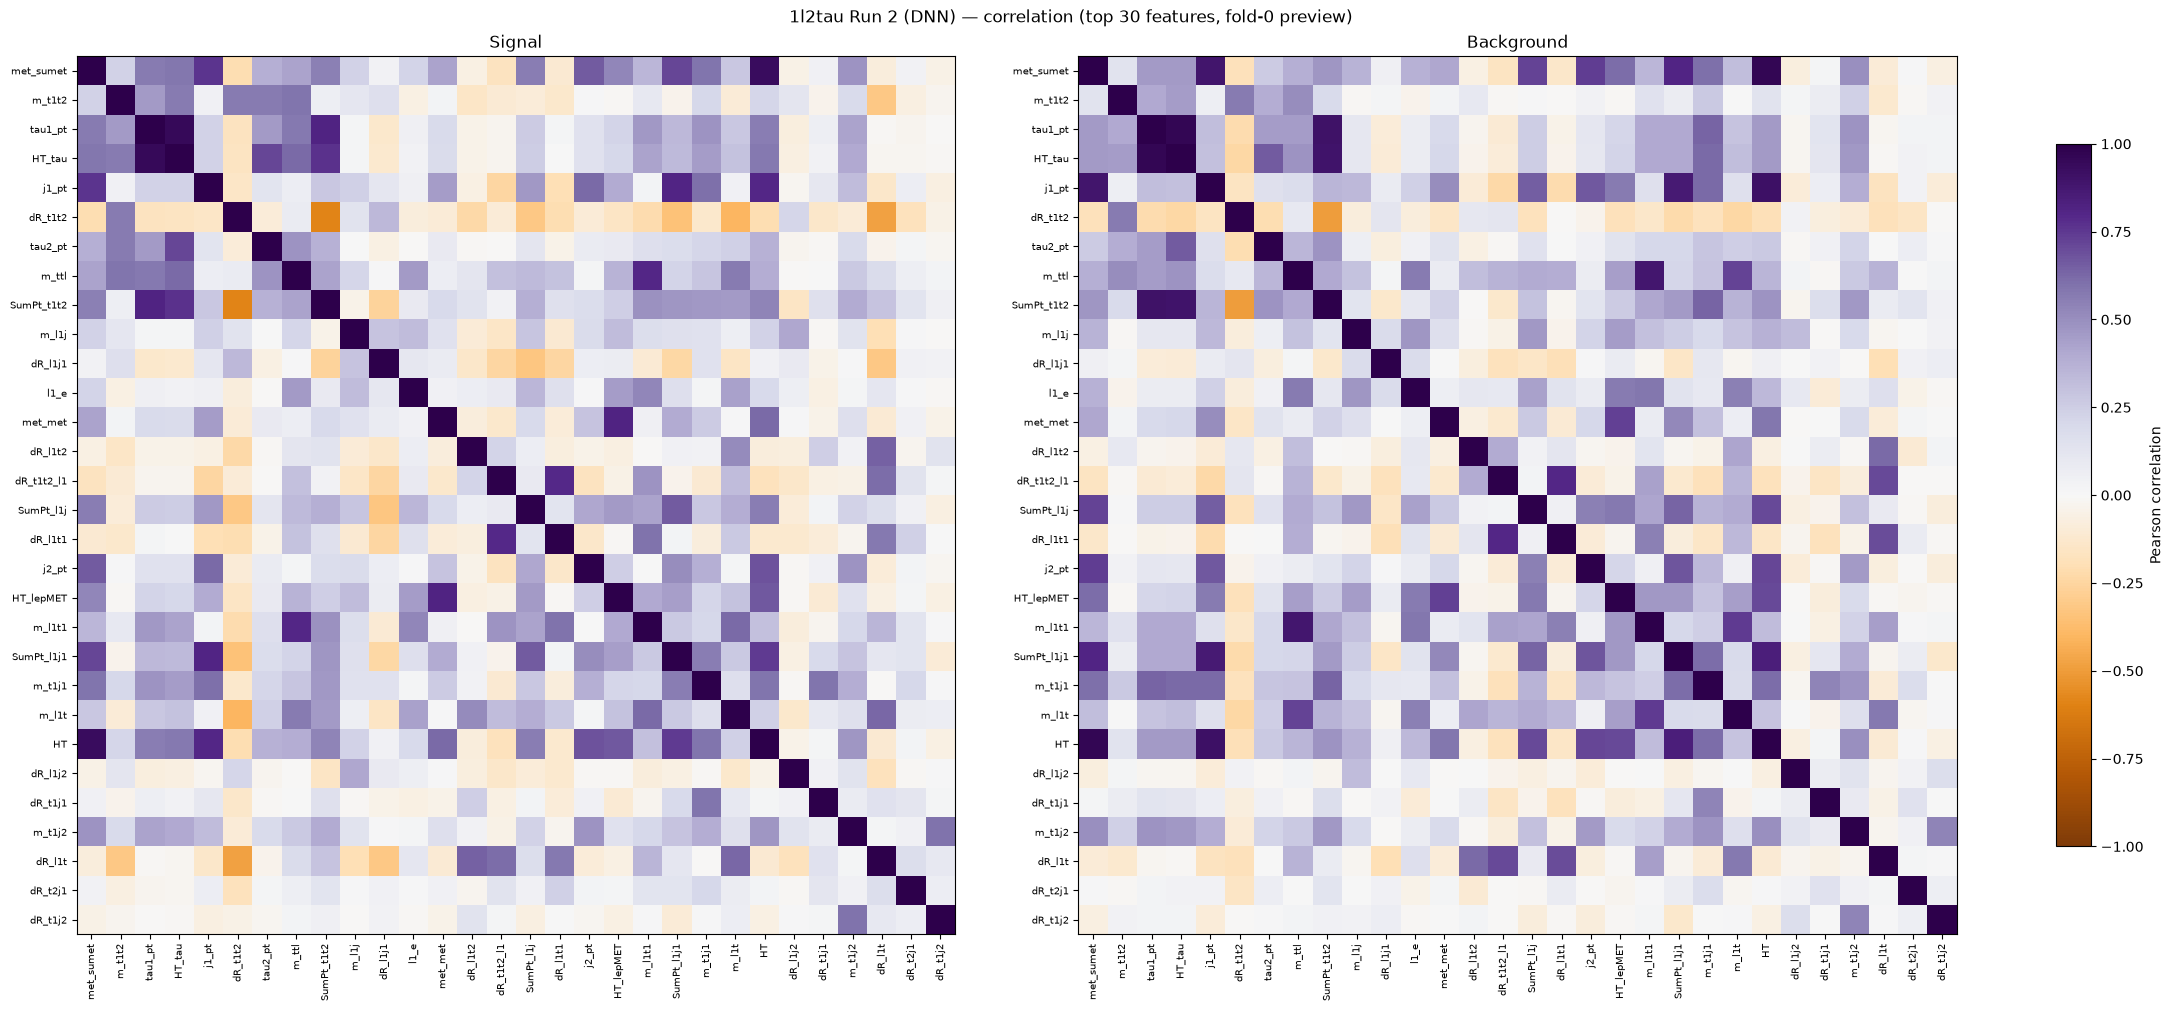

Pairs with |corr| > 0.50 (signal):
tau1_pt     HT_tau        0.946475
met_sumet   HT            0.931913
tau1_pt     SumPt_t1t2    0.815520
met_met     HT_lepMET     0.814933
j1_pt       SumPt_l1j1    0.809194
m_ttl       m_l1t1        0.803857
j1_pt       HT            0.803478
dR_t1t2_l1  dR_l1t1       0.793388
HT_tau      SumPt_t1t2    0.773080
met_sumet   j1_pt         0.761805
SumPt_l1j1  HT            0.748299
HT_tau      tau2_pt       0.717907
met_sumet   SumPt_l1j1    0.717637

Pairs with |corr| > 0.50 (background):
tau1_pt     HT_tau        0.967548
met_sumet   HT            0.965761
j1_pt       HT            0.911960
tau1_pt     SumPt_t1t2    0.904378
HT_tau      SumPt_t1t2    0.896431
met_sumet   j1_pt         0.883686
m_ttl       m_l1t1        0.877750
j1_pt       SumPt_l1j1    0.867108
SumPt_l1j1  HT            0.842983
met_sumet   SumPt_l1j1    0.806358
dR_t1t2_l1  dR_l1t1       0.800700
m_l1t1      m_l1t         0.747403
met_sumet   j2_pt         0.735930
met_met     HT_

In [68]:
# ---- Correlation of the top-30 permutation-important features -------------

top_feats = importance.index[:TOP_N_IMPORTANCE].tolist()
corrs = grouped_correlations(fd0_run2["train_df"], top_feats, group_col="label", group_values=[1, 0])

plot_group_correlations(
    [corrs[1], corrs[0]], ["Signal", "Background"], top_feats,
    suptitle=f"1l2tau Run 2 (DNN) — correlation (top {TOP_N_IMPORTANCE} features, fold-0 preview)",
    save_path=PLOTS_DIR_R2 / "Run2CorrelationTop30_DNN.png",
)

print("Pairs with |corr| > 0.50 (signal):")
print(top_pairs(corrs[1]).to_string())
print("\nPairs with |corr| > 0.50 (background):")
print(top_pairs(corrs[0]).to_string())


In [69]:
# ---- Correlation-based pruning to a decorrelated top-20 --------------------
# Conservative combination: a pair counts as redundant if EITHER regime
# (signal or background) shows near-degeneracy.

corr_max = corrs[1].abs().combine(corrs[0].abs(), np.maximum)
PRUNED_FEATURES, dropped_features = prune_correlated(top_feats, corr_max, CORR_THRESH, N_KEEP)

Kept 20 decorrelated features (most -> least important):
   1. met_sumet
   2. m_t1t2
   3. tau1_pt
   4. dR_t1t2
   5. tau2_pt
   6. m_ttl
   7. m_l1j
   8. dR_l1j1
   9. l1_e
  10. met_met
  11. dR_l1t2
  12. dR_t1t2_l1
  13. SumPt_l1j
  14. j2_pt
  15. m_t1j1
  16. m_l1t
  17. dR_l1j2
  18. dR_t1j1
  19. m_t1j2
  20. dR_l1t

Dropped 8 redundant features (|corr| > 0.75 with a more important feature):
  HT_tau          -> redundant with tau1_pt         (|corr| = 0.968)
  j1_pt           -> redundant with met_sumet       (|corr| = 0.884)
  SumPt_t1t2      -> redundant with tau1_pt         (|corr| = 0.904)
  dR_l1t1         -> redundant with dR_t1t2_l1      (|corr| = 0.801)
  HT_lepMET       -> redundant with met_met         (|corr| = 0.815)
  m_l1t1          -> redundant with m_ttl           (|corr| = 0.878)
  SumPt_l1j1      -> redundant with met_sumet       (|corr| = 0.806)
  HT              -> redundant with met_sumet       (|corr| = 0.966)


Full model      (60 features): train_auc_eval = 0.9471 | val_auc = 0.9221
Pruned model     (20 features): train_auc_eval = 0.9364 | val_auc = 0.9269
Baseline weighted AUC: 0.9269
Saved plot -> PPSSP_2026/1l2tau/run2/plots/Run2ImportancePruned_DNN.png


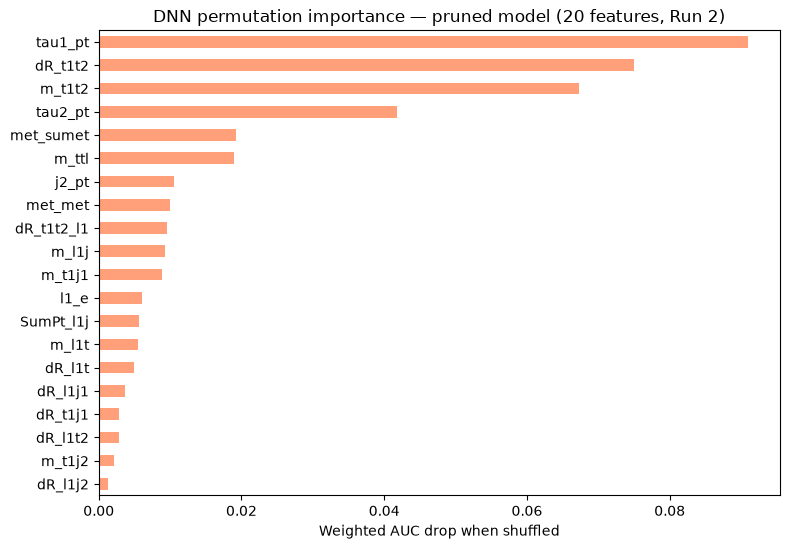

Saved plot -> PPSSP_2026/1l2tau/run2/plots/Run2CorrelationPruned_DNN.png


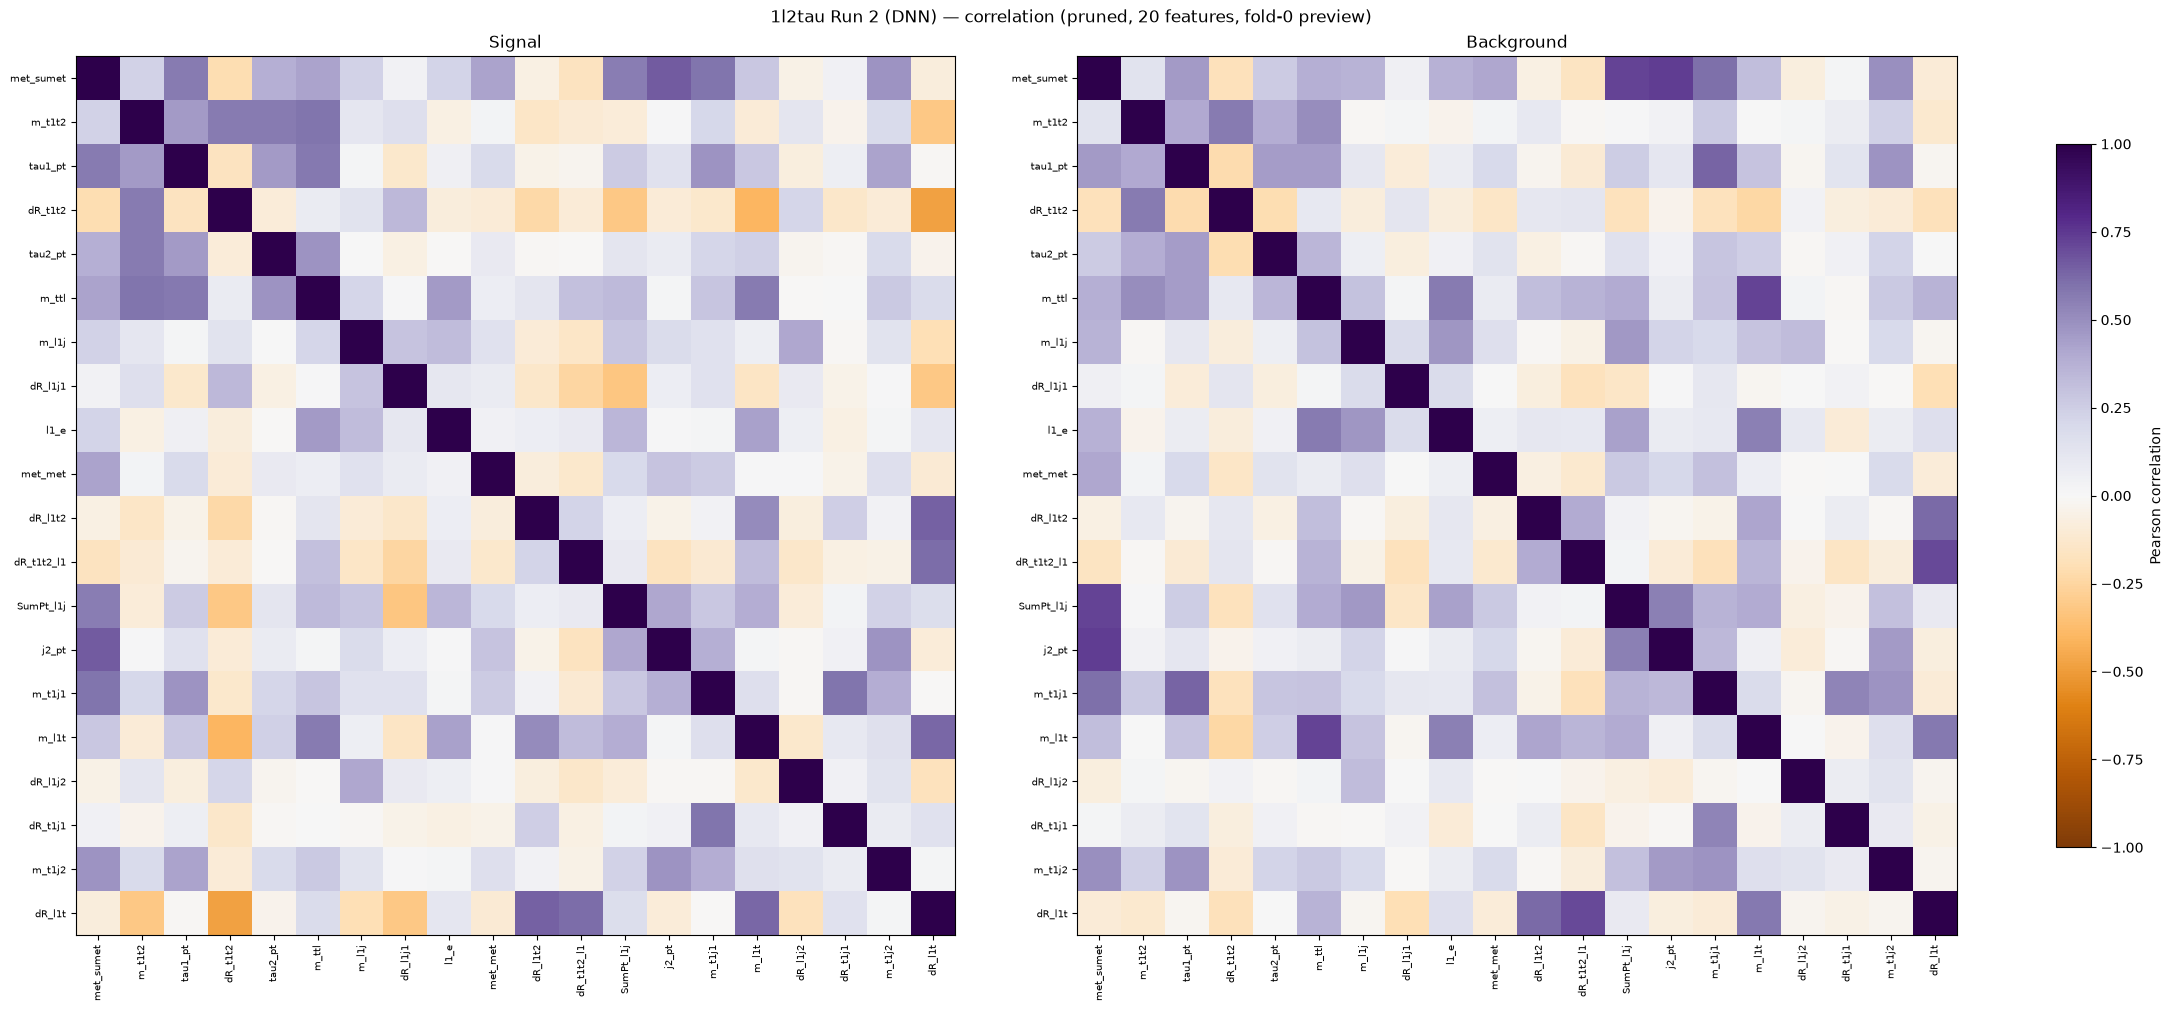

In [70]:
# ---- Retrain on the pruned feature set (fold-0 preview) --------------------
X_train_pruned_t, X_val_pruned_t, X_test_pruned_t = subset_feature_tensors_fold(fd0_run2, PRUNED_FEATURES, features)

model_pruned, history_pruned, val_auc_pruned, train_auc_pruned, train_auc_eval_pruned = train_model(
    X_train_pruned_t, fd0_run2["y_train_t"], fd0_run2["w_train_fit_t"],
    X_val_pruned_t, fd0_run2["y_val_t"], fd0_run2["w_val_abs_t"],
    hidden_sizes=best_hidden_sizes, dropout=best_params_run2["dropout"], lr=best_params_run2["lr"],
    weight_decay=best_params_run2["weight_decay"], batch_size=best_params_run2["batch_size"],
    patience=best_params_run2["patience"], w_train_eval_data=fd0_run2["w_train_abs_t"], verbose=False,
)

print(f"Full model      ({len(features):2d} features): train_auc_eval = {best_train_auc_eval:.4f} | val_auc = {best_val_auc:.4f}")
print(f"Pruned model     ({len(PRUNED_FEATURES):2d} features): train_auc_eval = {train_auc_eval_pruned:.4f} | val_auc = {val_auc_pruned:.4f}")

importance_pruned = permutation_importance(model_pruned, X_val_pruned_t, fd0_run2["y_val_t"], fd0_run2["w_val_abs_t"],
                                            PRUNED_FEATURES, n_repeats=5)
plot_importance_bar(
    importance_pruned, top_n=len(PRUNED_FEATURES),
    title=f"DNN permutation importance — pruned model ({len(PRUNED_FEATURES)} features, Run 2)",
    color="lightsalmon",
    save_path=PLOTS_DIR_R2 / "Run2ImportancePruned_DNN.png",
)

pruned_corrs = grouped_correlations(fd0_run2["train_df"], PRUNED_FEATURES, group_col="label", group_values=[1, 0])
plot_group_correlations(
    [pruned_corrs[1], pruned_corrs[0]], ["Signal", "Background"], PRUNED_FEATURES,
    suptitle=f"1l2tau Run 2 (DNN) — correlation (pruned, {len(PRUNED_FEATURES)} features, fold-0 preview)",
    save_path=PLOTS_DIR_R2 / "Run2CorrelationPruned_DNN.png",
)


## Top-15 Features Only

Same correlation-pruning walk over the same top-30 candidate pool, but
stopped once 15 decorrelated features are kept, to see how much (if any)
weighted validation AUC is lost by cutting down to a much smaller,
easier-to-interpret feature set.

Kept 15 decorrelated features (most -> least important):
   1. met_sumet
   2. m_t1t2
   3. tau1_pt
   4. dR_t1t2
   5. tau2_pt
   6. m_ttl
   7. m_l1j
   8. dR_l1j1
   9. l1_e
  10. met_met
  11. dR_l1t2
  12. dR_t1t2_l1
  13. SumPt_l1j
  14. j2_pt
  15. m_t1j1

Dropped 7 redundant features (|corr| > 0.75 with a more important feature):
  HT_tau          -> redundant with tau1_pt         (|corr| = 0.968)
  j1_pt           -> redundant with met_sumet       (|corr| = 0.884)
  SumPt_t1t2      -> redundant with tau1_pt         (|corr| = 0.904)
  dR_l1t1         -> redundant with dR_t1t2_l1      (|corr| = 0.801)
  HT_lepMET       -> redundant with met_met         (|corr| = 0.815)
  m_l1t1          -> redundant with m_ttl           (|corr| = 0.878)
  SumPt_l1j1      -> redundant with met_sumet       (|corr| = 0.806)


Baseline weighted AUC: 0.9261
Saved plot -> PPSSP_2026/1l2tau/run2/plots/Run2ImportanceTop15_DNN.png


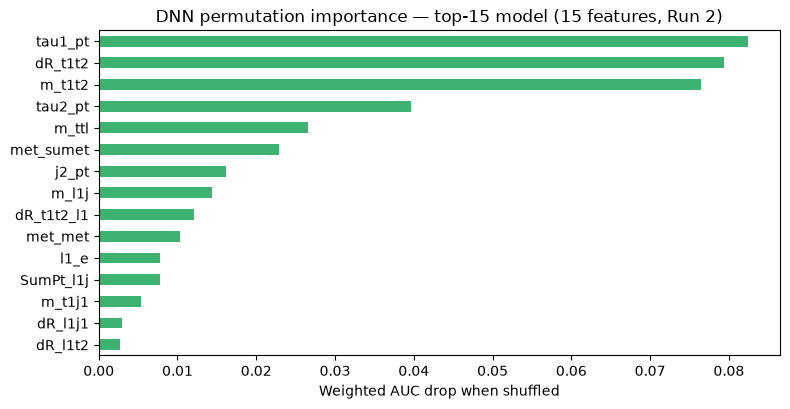


Weighted train(eval-mode)/validation AUC comparison (fold-0 preview):


,model,train_auc_eval,val_auc
1,Pruned (20 features),0.936417,0.926898
2,Top-15 (15 features),0.933361,0.926073
0,Full (60 features),0.947075,0.922086


In [71]:
TOP15_FEATURES, dropped_top15 = prune_correlated(top_feats, corr_max, CORR_THRESH, n_keep=15)

X_train_top15_t, X_val_top15_t, X_test_top15_t = subset_feature_tensors_fold(fd0_run2, TOP15_FEATURES, features)

model_top15, history_top15, val_auc_top15, train_auc_top15, train_auc_eval_top15 = train_model(
    X_train_top15_t, fd0_run2["y_train_t"], fd0_run2["w_train_fit_t"],
    X_val_top15_t, fd0_run2["y_val_t"], fd0_run2["w_val_abs_t"],
    hidden_sizes=best_hidden_sizes, dropout=best_params_run2["dropout"], lr=best_params_run2["lr"],
    weight_decay=best_params_run2["weight_decay"], batch_size=best_params_run2["batch_size"],
    patience=best_params_run2["patience"], w_train_eval_data=fd0_run2["w_train_abs_t"], verbose=False,
)

importance_top15 = permutation_importance(model_top15, X_val_top15_t, fd0_run2["y_val_t"], fd0_run2["w_val_abs_t"],
                                           TOP15_FEATURES, n_repeats=5)
plot_importance_bar(
    importance_top15, top_n=len(TOP15_FEATURES),
    title=f"DNN permutation importance — top-15 model ({len(TOP15_FEATURES)} features, Run 2)",
    color="mediumseagreen",
    save_path=PLOTS_DIR_R2 / "Run2ImportanceTop15_DNN.png",
)

comparison = pd.DataFrame([
    {"model": f"Full ({len(features)} features)", "train_auc_eval": best_train_auc_eval, "val_auc": best_val_auc},
    {"model": f"Pruned ({len(PRUNED_FEATURES)} features)", "train_auc_eval": train_auc_eval_pruned, "val_auc": val_auc_pruned},
    {"model": f"Top-15 ({len(TOP15_FEATURES)} features)", "train_auc_eval": train_auc_eval_top15, "val_auc": val_auc_top15},
]).sort_values("val_auc", ascending=False)

print("\nWeighted train(eval-mode)/validation AUC comparison (fold-0 preview):")
comparison


## Physics Figure of Merit & Final Summary

Weighted AUC is a global ranking metric; for HH what matters is significance
in the high-score region. This section reports a max-Asimov-significance
scan for the **last pruned model (top-15 features)** - the most
decorrelated/interpretable feature set from the pruning walk above - plus a
low-FPR ROC view and signal efficiency at fixed background-rejection
working points, all still on **VAL** (used for model/cut selection).

A genuinely blind estimate follows in the "Held-Out Test Evaluation" cell
below: the VAL-selected score cut is applied FROZEN to the never-before-seen
**TEST** partition (10% of the sample, held out by `make_3way_split` since
before preprocessing), reporting test AUC and test Z at that cut exactly
once - this is what actually answers "how good is this model", since VAL
was used to pick both the model and the cut.

In [72]:
# ---- Score the model with the best fold-0-preview val_auc (Full/Pruned/Top-15) -
# significance_scan is the canonical copy from the K-Fold helper library above.
FEATURE_SETS_R2 = {
    f"Full ({len(features)} features)": (model, features, fd0_run2["X_val_t"]),
    f"Pruned ({len(PRUNED_FEATURES)} features)": (model_pruned, PRUNED_FEATURES, X_val_pruned_t),
    f"Top-15 ({len(TOP15_FEATURES)} features)": (model_top15, TOP15_FEATURES, X_val_top15_t),
}
best_name = comparison.iloc[0]["model"]
final_model, FINAL_FEATURES_R2, X_val_final_t = FEATURE_SETS_R2[best_name]

final_model.eval()
with torch.no_grad():
    val_scores = torch.sigmoid(final_model(X_val_final_t)).cpu().numpy()

y_val = fd0_run2["val_df"]["label"].to_numpy()
w_val_signed = fd0_run2["val_df"]["w_phys"].to_numpy()

z_val, thr_val = significance_scan(y_val, val_scores, w_val_signed)
final_val_auc = comparison.loc[comparison["model"] == best_name, "val_auc"].iloc[0]
final_train_auc_eval = comparison.loc[comparison["model"] == best_name, "train_auc_eval"].iloc[0]

print(f"Final feature set (fold-0 preview): {best_name}")
print(f"Weighted val AUC = {final_val_auc:.4f}")
print(f"Max Asimov Z (val) = {z_val:.3f} at score cut = {thr_val:.4f}")


Final feature set (fold-0 preview): Pruned (20 features)
Weighted val AUC = 0.9269
Max Asimov Z (val) = 0.091 at score cut = 0.9930


### K-Fold Production Run & Artifacts (Run 2)

Everything above (Optuna search, correlation pruning, permutation
importance) used only fold 0 as a representative preview. This is where the
actual 5-fold OOF production run happens: `run_kfold_nn` trains one model
per fold (frozen tuned hyperparameters, `best_params_run2`, on
`FINAL_FEATURES_R2`) and scores every event with a model that never
trained on it. Replaces the old single train/val/test split's "Held-Out
Test Evaluation" cell - there is no single held-out test set anymore, only
the pooled OOF metrics below.



[Run2] fold 0: test_fold=0 val_fold=1 | train n=369706 (dropped 44813 neg) | test weighted AUC = 0.9313 | test significance Z = 0.041
[Run2] fold 1: test_fold=1 val_fold=2 | train n=370115 (dropped 44838 neg) | test weighted AUC = 0.9328 | test significance Z = 0.040
[Run2] fold 2: test_fold=2 val_fold=3 | train n=369607 (dropped 44535 neg) | test weighted AUC = 0.9338 | test significance Z = 0.049
[Run2] fold 3: test_fold=3 val_fold=4 | train n=369355 (dropped 44703 neg) | test weighted AUC = 0.9332 | test significance Z = 0.058
[Run2] fold 4: test_fold=4 val_fold=0 | train n=369757 (dropped 44623 neg) | test weighted AUC = 0.9270 | test significance Z = 0.041
[Run2] OOF weighted AUC (pooled) = 0.9313
[Run2] OOF max Asimov Z (pooled) = 0.106 at score cut = 0.9964


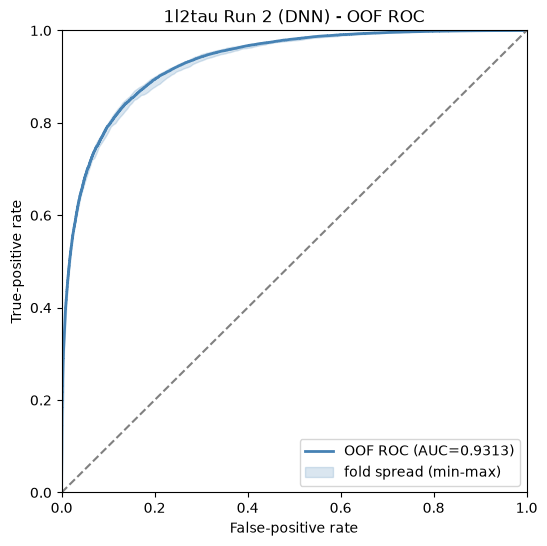

Saved 5 fold models + preprocessing + feature list + hyperparams + OOF scores -> PPSSP_2026/1l2tau/run2/ (track=run2)


In [73]:
# ---- K-FOLD PRODUCTION RUN (Run 2) -----------------------------------------
flag_cols_final_run2 = [f for f in flag_cols_run2 if f in FINAL_FEATURES_R2]

oof_df_run2, models_run2, scalers_run2, medians_run2 = run_kfold_nn(
    data_run2, FINAL_FEATURES_R2, flag_cols_final_run2, best_params_run2, target_yields_run2,
    cell_cols=(), n_folds=N_FOLDS, label="Run2",
)

oof_auc_run2 = plot_oof_roc(oof_df_run2, title="1l2tau Run 2 (DNN) - OOF ROC")

save_track_artifacts_nn(
    models_run2, scalers_run2, medians_run2, FINAL_FEATURES_R2, flag_cols_final_run2,
    best_params_run2, oof_df_run2, BASE_DIR_RUN2, "run2",
)


In [74]:
# ---- Load a tuned XGBoost fold-0 model (same 1l2tau Run 2 track, k-fold
# artifacts from Esteban/1L2Tau_Master_Pipeline.ipynb) for an apples-to-apples
# overlay, scored on this notebook's fold-0 val partition.
import xgboost as xgb

xgb_model = xgb.XGBClassifier()
xgb_model.load_model(BASE_DIR / "model_run2_fold0.json")
with open(BASE_DIR / "features_run2.json") as f:
    xgb_features = json.load(f)

xgb_val_scores = xgb_model.predict_proba(fd0_run2["val_df"][xgb_features])[:, 1]


def roc_with_auc(y_true, scores, w):
    fpr, tpr, _ = roc_curve(y_true, scores, sample_weight=w)
    auc = roc_auc_score(y_true, scores, sample_weight=w)
    return fpr, tpr, auc


fpr_val, tpr_val, _ = roc_curve(y_val, val_scores, sample_weight=w_val_abs)

curves = {
    "XGBoost (tuned, fold 0)": roc_with_auc(y_val, xgb_val_scores, w_val_abs),
    f"DNN Full ({len(features)} features)": roc_with_auc(y_val, val_probs, w_val_abs),
    f"DNN {best_name}": (fpr_val, tpr_val, final_val_auc),
}

plt.figure(figsize=(6, 6))
for name, (fpr, tpr, auc) in curves.items():
    plt.plot(fpr, tpr, label=f"{name} (AUC = {auc:.4f})")


x_random = np.logspace(-4, 0, 200)
plt.plot(x_random, x_random, "k--", label="Random (TPR=FPR)")

plt.xscale("log")
plt.xlim(1e-4, 1)
plt.xlabel("False positive rate (log scale)")
plt.ylabel("True positive rate")
plt.title("Low-FPR ROC — model comparison (val, fold-0 preview)")
plt.legend()
plt.tight_layout()
plt.show()

n_bkg_val = int((y_val == 0).sum())

for target_fpr in (1e-3, 1e-2):
    print(f"--- FPR = {target_fpr:.0e} (~{target_fpr * n_bkg_val:.0f} surviving background MC events) ---")
    for name, (fpr, tpr, _) in curves.items():
        idx = min(np.searchsorted(fpr, target_fpr), len(tpr) - 1)
        print(f"  {name:32s} TPR = {tpr[idx]:.4f}  ({tpr[idx] / target_fpr:.0f}x random lift)")


XGBoostError: [06:29:23] /__w/xgboost/xgboost/src/common/io.cc:144: Opening PPSSP_2026/1l2tau/run2/model_run2_fold0.json failed: No such file or directory
Stack trace:
  [bt] (0) /home/est3ban3/IFJ_Pan/MVA-Project/.venv/lib/python3.12/site-packages/xgboost/lib/libxgboost.so(+0x2c69bc) [0x7dc67eec69bc]
  [bt] (1) /home/est3ban3/IFJ_Pan/MVA-Project/.venv/lib/python3.12/site-packages/xgboost/lib/libxgboost.so(+0x3e3a23) [0x7dc67efe3a23]
  [bt] (2) /home/est3ban3/IFJ_Pan/MVA-Project/.venv/lib/python3.12/site-packages/xgboost/lib/libxgboost.so(+0x1db4f5) [0x7dc67eddb4f5]
  [bt] (3) /home/est3ban3/IFJ_Pan/MVA-Project/.venv/lib/python3.12/site-packages/xgboost/lib/libxgboost.so(XGBoosterLoadModel+0xbe) [0x7dc67eddb99e]
  [bt] (4) /lib/x86_64-linux-gnu/libffi.so.8(+0x7b16) [0x7dcb34df1b16]
  [bt] (5) /lib/x86_64-linux-gnu/libffi.so.8(+0x43ef) [0x7dcb34dee3ef]
  [bt] (6) /lib/x86_64-linux-gnu/libffi.so.8(ffi_call+0x12e) [0x7dcb34df10be]
  [bt] (7) /usr/lib/python3.12/lib-dynload/_ctypes.cpython

In [ ]:
# ---- Sanity checks --------------------------------------------------------

assert torch.isfinite(fd0_run2["X_train_t"]).all() and torch.isfinite(fd0_run2["X_val_t"]).all(), \
    "NaN/inf reached the model input"

set_seed(RANDOM_STATE)
_, _, det_check_a, _, _ = train_model(
    fd0_run2["X_train_t"], fd0_run2["y_train_t"], fd0_run2["w_train_fit_t"],
    fd0_run2["X_val_t"], fd0_run2["y_val_t"], fd0_run2["w_val_abs_t"],
    hidden_sizes=(64,), n_epochs=5, patience=5, verbose=False,
)

set_seed(RANDOM_STATE)
_, _, det_check_b, _, _ = train_model(
    fd0_run2["X_train_t"], fd0_run2["y_train_t"], fd0_run2["w_train_fit_t"],
    fd0_run2["X_val_t"], fd0_run2["y_val_t"], fd0_run2["w_val_abs_t"],
    hidden_sizes=(64,), n_epochs=5, patience=5, verbose=False,
)
assert det_check_a == det_check_b, f"Determinism check FAILED: {det_check_a} != {det_check_b}"

print(f"Determinism check passed: two re-seeded runs give identical val_auc = {det_check_a:.6f}")

summary = pd.DataFrame([{
    "model": best_name,
    "train_auc_eval": final_train_auc_eval,
    "val_auc": final_val_auc,
    "max_asimov_Z (val)": z_val,
}])

print("\nFold-0-preview summary (DNN, 1l2tau Run 2):")
print(summary.to_string(index=False))
summary


Determinism check passed: two re-seeded runs give identical val_auc = 0.901418

Fold-0-preview summary (DNN, 1l2tau Run 2):
               model  train_auc_eval  val_auc  max_asimov_Z (val)
Pruned (20 features)        0.932823 0.924354            0.079732


,model,train_auc_eval,val_auc,max_asimov_Z (val)
0,Pruned (20 features),0.932823,0.924354,0.079732


## Run 3 (Separate Downstream Section)

Run 2 remains the first complete pass above. To start a separate Run 3 pass,
run the next cell to switch the active dataset, then continue with your
Run 3 downstream cells.

In [ ]:
# Activate Run 3 as the downstream dataset. Everything below uses `_run3`
# suffixed variable names so the Run 2 results above remain untouched.

candidate_features, data, features = candidate_features_run3, data_run3, features_run3

BASE_DIR = BASE_DIR_RUN3
ACTIVE_RUN = "Run 3"

print(f"Switched downstream dataset to: {ACTIVE_RUN}")
print(f"Events={len(data)} | features={len(features)}")

Switched downstream dataset to: Run 3
Events=1324892 | features=64


## Sentinel Audit (-1) — Run 3

Same diagnostic as the Run 2 section above, run separately on `data_run3`/
`features_run3`.

In [ ]:
# ---- Weight-balance diagnostics (Run 3, representative fold 0) ------------
PLOTS_DIR_R3 = BASE_DIR_RUN3 / "plots"
PLOTS_DIR_R3.mkdir(parents=True, exist_ok=True)

target_yields_run3 = compute_process_yield_targets(data_run3)
flag_cols_run3 = compute_flag_cols(data_run3, features_run3)
N_FEATURES_MODEL = len(features_run3) + len(flag_cols_run3)

fd0_run3 = prepare_fold_tensors(data_run3, features_run3, flag_cols_run3, target_yields_run3,
                                 cell_cols=(), n_folds=N_FOLDS, k=0)

w_before_run3 = fd0_run3["train_df"]["w_phys"].to_numpy()
w_after_run3 = fd0_run3["w_train_fit"]
y_preview_run3 = fd0_run3["train_df"]["label"].to_numpy()

plot_weight_balance(
    y_preview_run3, w_before_run3, w_after_run3,
    title="Run 3 (DNN) - make_fit_weights balancing (fold 0 train)",
    save_path=PLOTS_DIR_R3 / "Run3WeightBalance_DNN.png",
)

print(f"{len(flag_cols_run3)} features had missing values in train (globally) -> added "
      f"{len(flag_cols_run3)} __isnan flag columns (final model input width = {N_FEATURES_MODEL} = "
      f"{len(features_run3)} features + {len(flag_cols_run3)} flags)")

print("\nN_eff (training sample, positive-only, post yield-rescale) by label - fold 0:")
print(n_eff_table(fd0_run3["train_df"], ["label"]))
print("\nN_eff (eval sample, signed, FULL fold-0 test partition) by label:")
print(n_eff_table(fd0_run3["test_df"], ["label"]))
print(f"\nDropped {fd0_run3['n_dropped_train']} negative-w_phys training rows in this "
      f"preview fold (kept, not abs'd, elsewhere - see prepare_fold_data).")


1 / 64 features have at least one row exactly equal to -1:
  feature  frac_exactly_-1  gap_to_next_value_above
l1_charge         0.474795                      2.0

NEG1_SENTINEL_FEATURES_run3 is empty - no -1 values masked.


In [ ]:
plot_scaling_before_after(
    fd0_run3["train_df"], features_run3, fd0_run3["train_medians"], fd0_run3["scaler"],
    weights=fd0_run3["w_train_fit"],
    title="Run 3 (DNN) - median-impute + StandardScaler (fold 0 train)",
    save_path=PLOTS_DIR_R3 / "Run3ScalingBeforeAfter_DNN.png",
)


## Train/Validation Split & Preprocessing — Run 3

Same 80/20 stratified split, median imputation (fit on train only),
standard scaling, and `__isnan` missingness flags as the Run 2 section,
applied to `data_run3`. Kept in separate `_run3` variables so the Run 2
train/val tensors above are unaffected.

In [ ]:
model_run3 = build_model(n_features=fd0_run3["n_features_model"])

print(model_run3)


Train:  1059912 events | signal =  164040 (yield=      1.67) | background =  895872 (yield=  15588.90) | signal weight scale factor = 9358.6
Val  :   132490 events | signal =   20505 (yield=      0.21) | background =  111985 (yield=   1910.84) | signal weight scale factor = 9270.7
Test :   132490 events | signal =   20505 (yield=      0.21) | background =  111985 (yield=   1867.19) | signal weight scale factor = 8929.3
  cross-check OK: PPSSP_2026/1l2tau/run3/splits/test.root test partition matches on 69 shared columns (132490 rows)


Wrote 132490 test events -> PPSSP_2026/1l2tau/run3/splits/test.root  (held out until final evaluation)

0 features had missing values in train -> added 0 __isnan flag columns (final input width = 64 = 64 features + 0 flags)
Signal weight scale factor (train): 12537.2


## PyTorch Dataset & Model — Run 3

In [ ]:
# ---- Fold-0 preview baseline (default hyperparameters) - used only to rank
# features for the correlation-pruning stage below.
model_run3, history_run3, best_val_auc_run3, best_train_auc_run3, best_train_auc_eval_run3 = train_model(
    fd0_run3["X_train_t"], fd0_run3["y_train_t"], fd0_run3["w_train_fit_t"],
    fd0_run3["X_val_t"], fd0_run3["y_val_t"], fd0_run3["w_val_abs_t"],
    hidden_sizes=DEFAULT_HIDDEN_SIZES, w_train_eval_data=fd0_run3["w_train_abs_t"],
)

print(f"\nBest val_auc = {best_val_auc_run3:.4f} | train_auc (dropout on) = {best_train_auc_run3:.4f} "
      f"| train_auc_eval (dropout off, comparable) = {best_train_auc_eval_run3:.4f}")


SimpleMLP(
  (net): Sequential(
    (0): Linear(in_features=64, out_features=256, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.3, inplace=False)
    (3): Linear(in_features=256, out_features=256, bias=True)
    (4): ReLU()
    (5): Dropout(p=0.3, inplace=False)
    (6): Linear(in_features=256, out_features=128, bias=True)
    (7): ReLU()
    (8): Dropout(p=0.3, inplace=False)
    (9): Linear(in_features=128, out_features=128, bias=True)
    (10): ReLU()
    (11): Dropout(p=0.3, inplace=False)
    (12): Linear(in_features=128, out_features=64, bias=True)
    (13): ReLU()
    (14): Dropout(p=0.3, inplace=False)
    (15): Linear(in_features=64, out_features=32, bias=True)
    (16): ReLU()
    (17): Dropout(p=0.3, inplace=False)
    (18): Linear(in_features=32, out_features=1, bias=True)
  )
)


## Training Loop — Run 3

Reuses the same `train_model`/`run_epoch` functions defined in the Run 2
section above, with explicit `_run3` tensors passed in so the Run 2 model/
history are untouched.

In [ ]:
study_run3 = run_optuna_search_nn(data_run3, features_run3, flag_cols_run3, target_yields_run3,
                                   study_name="dnn_opt_run3")
best_params_run3 = params_from_study_nn(study_run3)
best_hidden_sizes_run3 = best_params_run3["hidden_sizes"]
plot_optuna_diagnostics_nn(study_run3, title_suffix="(1l2tau, Run 3, DNN)")

# ---- Refit the fold-0 preview model with the tuned hyperparameters -------
model_run3, history_run3, best_val_auc_run3, best_train_auc_run3, best_train_auc_eval_run3 = train_model(
    fd0_run3["X_train_t"], fd0_run3["y_train_t"], fd0_run3["w_train_fit_t"],
    fd0_run3["X_val_t"], fd0_run3["y_val_t"], fd0_run3["w_val_abs_t"],
    hidden_sizes=best_params_run3["hidden_sizes"], dropout=best_params_run3["dropout"],
    lr=best_params_run3["lr"], weight_decay=best_params_run3["weight_decay"],
    batch_size=best_params_run3["batch_size"], patience=best_params_run3["patience"],
    w_train_eval_data=fd0_run3["w_train_abs_t"], verbose=False,
)
print(f"\nTuned fold-0 preview: val_auc={best_val_auc_run3:.4f} | hidden_sizes={best_hidden_sizes_run3}")


Epoch   1 | train_loss=0.4571 val_loss=0.6089 | train_auc=0.8716 train_auc_eval=0.9187 val_auc=0.8985
Epoch   2 | train_loss=0.3801 val_loss=0.4689 | train_auc=0.9118 train_auc_eval=0.9253 val_auc=0.9047
Epoch   3 | train_loss=0.3666 val_loss=0.4328 | train_auc=0.9181 train_auc_eval=0.9301 val_auc=0.9091
Epoch   4 | train_loss=0.3578 val_loss=0.3174 | train_auc=0.9220 train_auc_eval=0.9317 val_auc=0.9277


Epoch   5 | train_loss=0.3525 val_loss=0.3410 | train_auc=0.9244 train_auc_eval=0.9343 val_auc=0.9243
Epoch   6 | train_loss=0.3469 val_loss=0.3602 | train_auc=0.9268 train_auc_eval=0.9364 val_auc=0.9278
Epoch   7 | train_loss=0.3440 val_loss=0.3288 | train_auc=0.9281 train_auc_eval=0.9383 val_auc=0.9338
Epoch   8 | train_loss=0.3367 val_loss=0.3585 | train_auc=0.9310 train_auc_eval=0.9392 val_auc=0.9351
Epoch   9 | train_loss=0.3346 val_loss=0.3318 | train_auc=0.9319 train_auc_eval=0.9402 val_auc=0.9308
Epoch  10 | train_loss=0.3325 val_loss=0.3408 | train_auc=0.9328 train_auc_eval=0.9421 val_auc=0.9365
Epoch  11 | train_loss=0.3308 val_loss=0.3593 | train_auc=0.9335 train_auc_eval=0.9427 val_auc=0.9305
Epoch  12 | train_loss=0.3309 val_loss=0.3639 | train_auc=0.9334 train_auc_eval=0.9437 val_auc=0.9376
Epoch  13 | train_loss=0.3258 val_loss=0.3670 | train_auc=0.9355 train_auc_eval=0.9444 val_auc=0.9371
Epoch  14 | train_loss=0.3239 val_loss=0.3191 | train_auc=0.9363 train_auc_eval=0.

## Simple Hyperparameter Search (hidden layer sizes) — Run 3

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

axes[0].plot(history_run3["train_loss"], label="train (dropout on)", color="tab:blue", alpha=0.5)
axes[0].plot(history_run3["train_loss_eval"], label="train (dropout off, comparable)", color="tab:blue")
axes[0].plot(history_run3["val_loss"], label="val", color="tab:orange")
axes[0].set_xlabel("epoch")
axes[0].set_ylabel("weighted BCE loss")
axes[0].set_title("Loss")
axes[0].legend()

axes[1].plot(history_run3["train_auc"], label="train (dropout on)", color="tab:blue", alpha=0.5)
axes[1].plot(history_run3["train_auc_eval"], label="train (dropout off, comparable)", color="tab:blue")
axes[1].plot(history_run3["val_auc"], label="val", color="tab:orange")
axes[1].set_xlabel("epoch")
axes[1].set_ylabel("weighted AUC")
axes[1].set_title("AUC")
axes[1].legend()

plt.tight_layout()
plt.show()

model_run3.eval()
with torch.no_grad():
    train_probs_run3 = torch.sigmoid(model_run3(fd0_run3["X_train_t"])).cpu().numpy()
    val_probs_run3 = torch.sigmoid(model_run3(fd0_run3["X_val_t"])).cpu().numpy()

y_train_run3, y_val_run3 = fd0_run3["train_df"]["label"].to_numpy(), fd0_run3["val_df"]["label"].to_numpy()
w_train_abs_run3 = fd0_run3["train_df"]["w_phys"].to_numpy()
w_val_abs_run3 = np.abs(fd0_run3["val_df"]["w_phys"].to_numpy())

auc_train_run3 = roc_auc_score(y_train_run3, train_probs_run3, sample_weight=w_train_abs_run3)
auc_val_run3 = roc_auc_score(y_val_run3, val_probs_run3, sample_weight=w_val_abs_run3)

print(f"Final weighted AUC (fold-0 preview): train={auc_train_run3:.4f} val={auc_val_run3:.4f}")

fpr_run3, tpr_run3, _ = roc_curve(y_val_run3, val_probs_run3, sample_weight=w_val_abs_run3)
plt.figure(figsize=(5, 5))
plt.plot(fpr_run3, tpr_run3, label=f"DNN (AUC = {auc_val_run3:.4f})")
plt.plot([0, 1], [0, 1], "k--", label="Random")
plt.xlabel("False positive rate")
plt.ylabel("True positive rate")
plt.title("ROC curve (validation, fold-0 preview) — Run 3")
plt.legend()
plt.tight_layout()
plt.show()


hidden_sizes=(64,)            -> train_auc=0.9336 val_auc=0.9383
hidden_sizes=(128, 64)        -> train_auc=0.9408 val_auc=0.9401
hidden_sizes=(256, 128)       -> train_auc=0.9462 val_auc=0.9413
hidden_sizes=(128, 64, 32)    -> train_auc=0.9409 val_auc=0.9400
hidden_sizes=(256, 128, 64, 32) -> train_auc=0.9415 val_auc=0.9403

Best architecture: hidden_sizes=(256, 128) | val_auc=0.9413


## Evaluation — Run 3

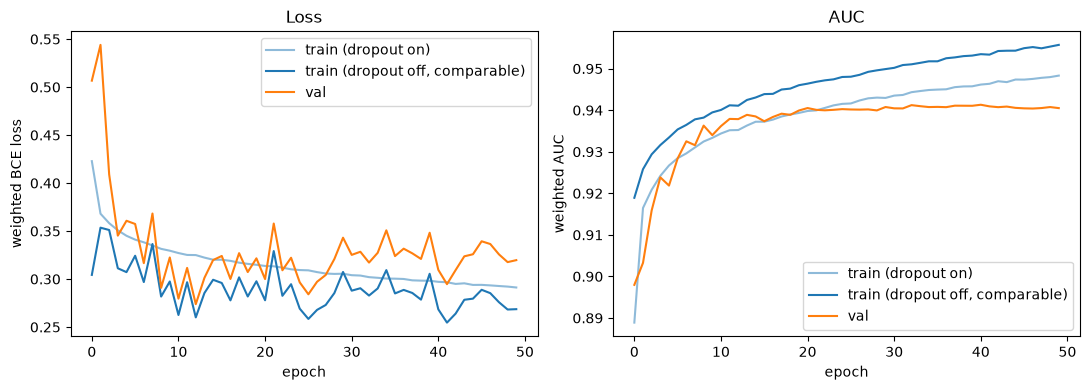

Final weighted AUC: train=0.9535 val=0.9413


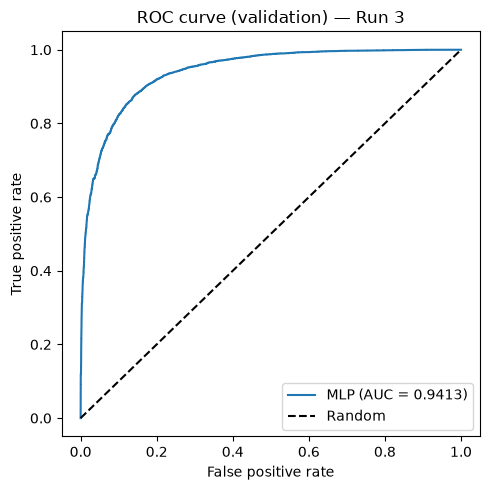

In [ ]:
importance_run3 = permutation_importance(model_run3, fd0_run3["X_val_t"], fd0_run3["y_val_t"], fd0_run3["w_val_abs_t"],
                                          features_run3, n_repeats=5)
plot_importance_bar(importance_run3, top_n=30, title="Top 30 DNN permutation importance (1l2tau, Run 3, fold-0 preview)",
                     save_path=PLOTS_DIR_R3 / "Run3ImportanceFull_DNN.png")
importance_run3.head(15)


## Feature Importance (Permutation) — Run 3

Reuses the same `permutation_importance`/`plot_importance_bar` helpers
defined in the Run 2 section.

Baseline weighted AUC: 0.9413


Saved plot -> PPSSP_2026/1l2tau/run3/plots/Run3ImportanceFull_DNN.png


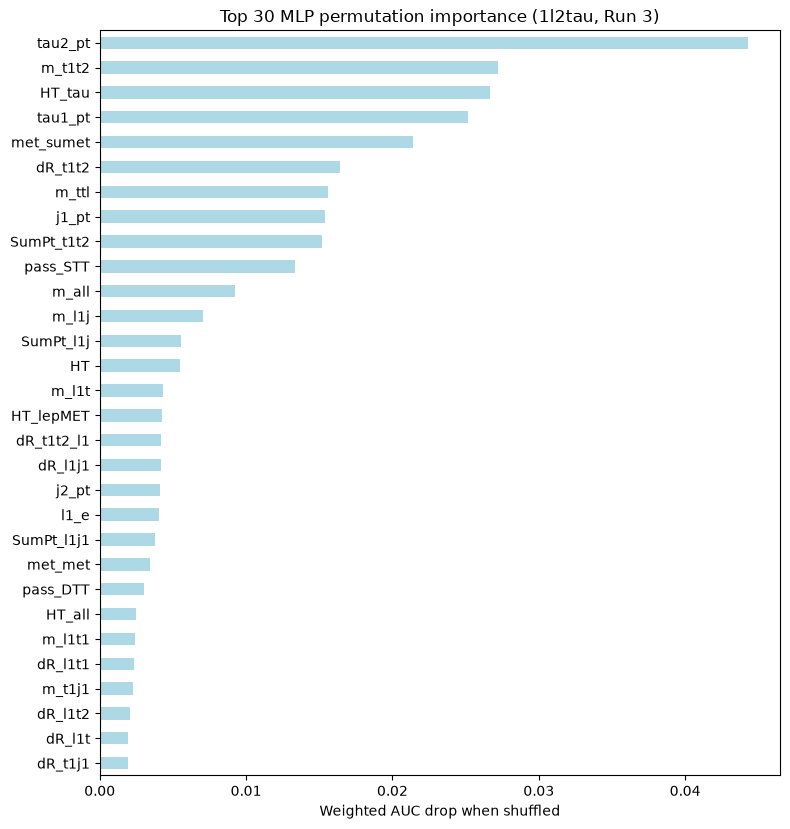

tau2_pt       0.044267
m_t1t2        0.027238
HT_tau        0.026674
tau1_pt       0.025166
met_sumet     0.021434
dR_t1t2       0.016416
m_ttl         0.015585
j1_pt         0.015406
SumPt_t1t2    0.015154
pass_STT      0.013309
m_all         0.009232
m_l1j         0.007032
SumPt_l1j     0.005572
HT            0.005497
m_l1t         0.004331
Name: auc_drop, dtype: float64

In [ ]:
# ---- Correlation of the top-30 permutation-important features -------------
top_feats_run3 = importance_run3.index[:TOP_N_IMPORTANCE].tolist()
corrs_run3 = grouped_correlations(fd0_run3["train_df"], top_feats_run3, group_col="label", group_values=[1, 0])

plot_group_correlations(
    [corrs_run3[1], corrs_run3[0]], ["Signal", "Background"], top_feats_run3,
    suptitle=f"1l2tau Run 3 (DNN) — correlation (top {TOP_N_IMPORTANCE} features, fold-0 preview)",
    save_path=PLOTS_DIR_R3 / "Run3CorrelationTop30_DNN.png",
)

print("Pairs with |corr| > 0.50 (signal):")
print(top_pairs(corrs_run3[1]).to_string())
print("\nPairs with |corr| > 0.50 (background):")
print(top_pairs(corrs_run3[0]).to_string())


## Correlation Pruning & Retraining — Run 3

Reuses `top_pairs`/`grouped_correlations`/`plot_group_correlations`/
`prune_correlated` from the Run 2 section (they take `data`/features as
plain arguments, so they work unchanged on Run 3 inputs).

Saved plot -> PPSSP_2026/1l2tau/run3/plots/Run3CorrelationTop30_DNN.png


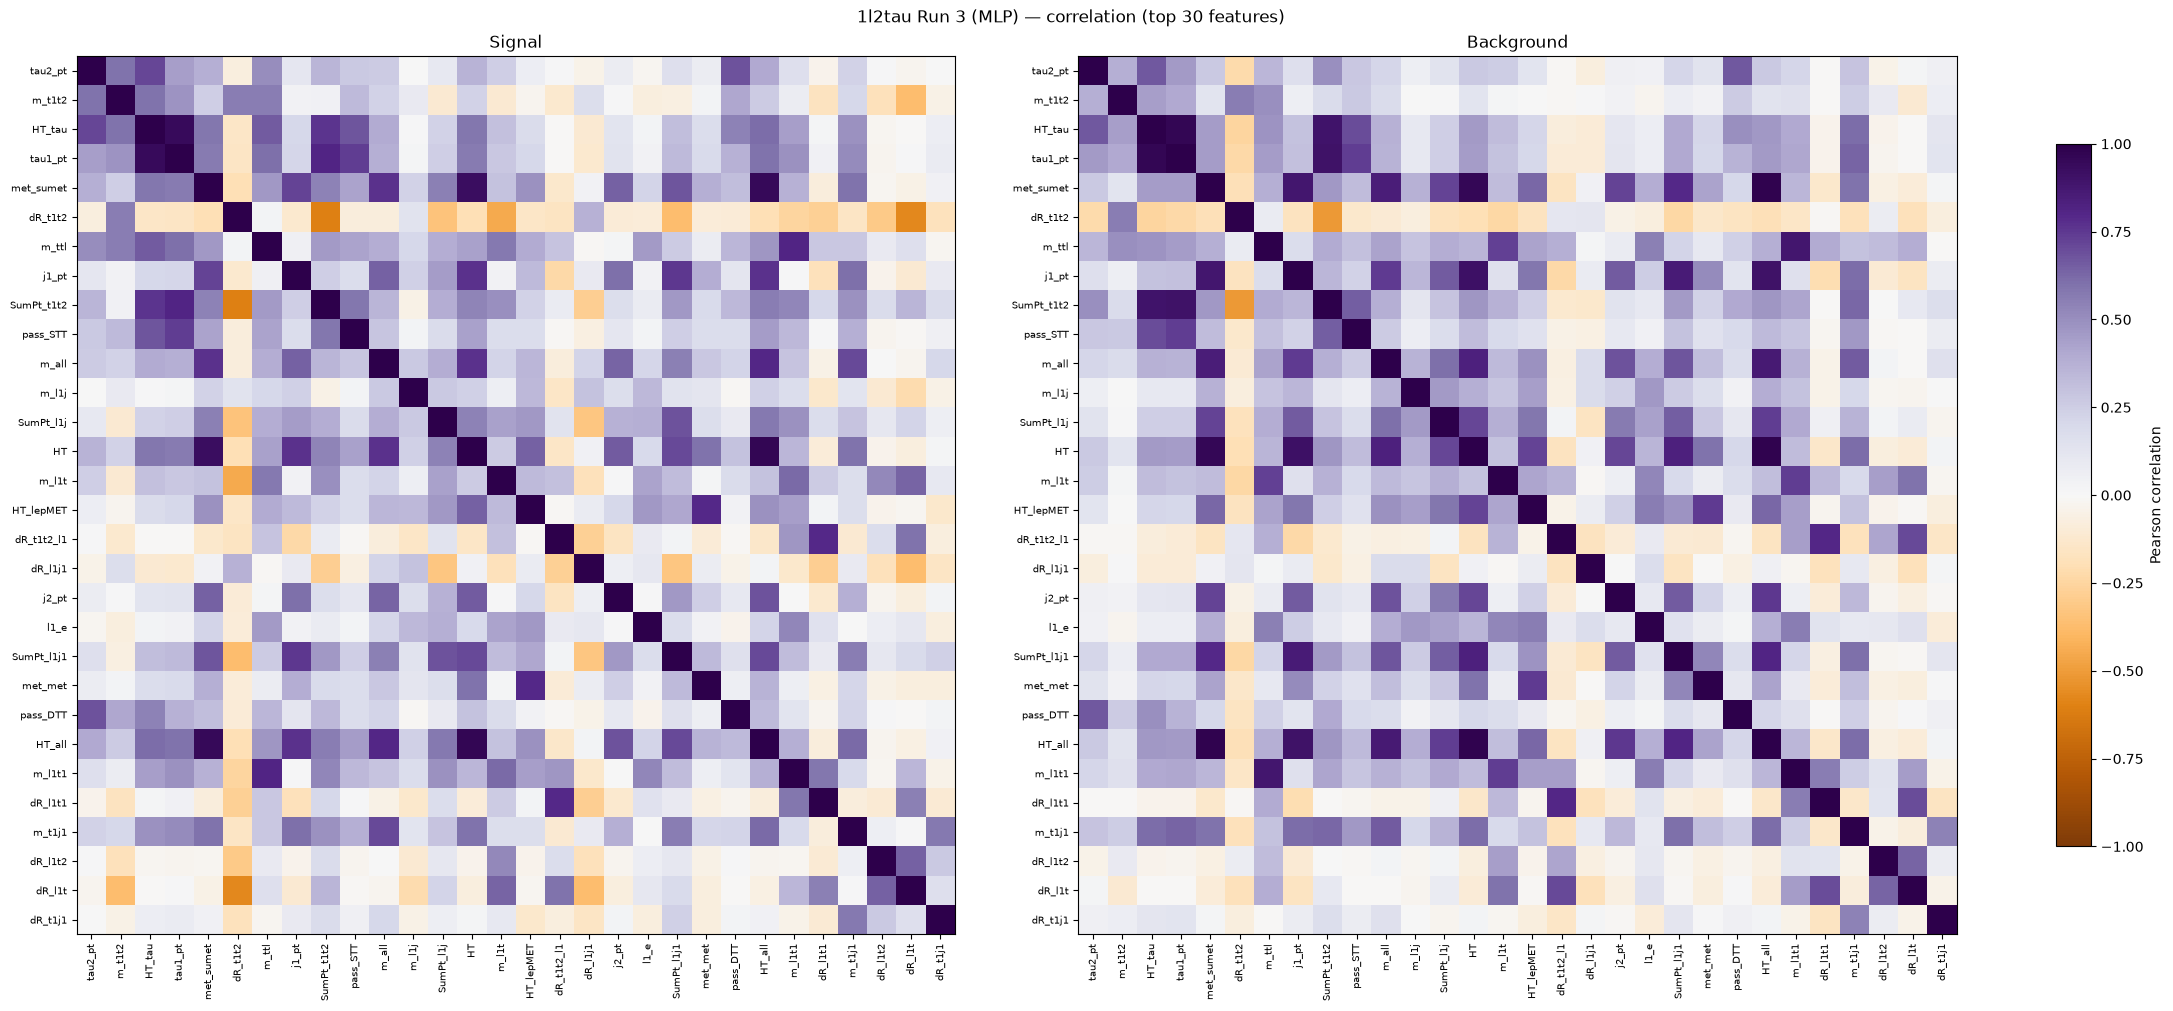

Pairs with |corr| > 0.50 (signal):
HT          HT_all        0.965227
met_sumet   HT_all        0.948426
HT_tau      tau1_pt       0.944209
met_sumet   HT            0.924214
m_ttl       m_l1t1        0.809769
tau1_pt     SumPt_t1t2    0.809316
m_all       HT_all        0.803421
dR_t1t2_l1  dR_l1t1       0.794290
HT_lepMET   met_met       0.792861
m_all       HT            0.770698
j1_pt       HT            0.770172
met_sumet   m_all         0.768420
j1_pt       HT_all        0.767195
HT_tau      SumPt_t1t2    0.763878
j1_pt       SumPt_l1j1    0.752508
tau1_pt     pass_STT      0.738444
met_sumet   j1_pt         0.725144
tau2_pt     HT_tau        0.711260
m_all       m_t1j1        0.706645
SumPt_l1j1  HT_all        0.706386
HT          SumPt_l1j1    0.703519

Pairs with |corr| > 0.50 (background):
met_sumet   HT_all        0.979360
HT          HT_all        0.978909
HT_tau      tau1_pt       0.967156
met_sumet   HT            0.960698
j1_pt       HT            0.911466
tau1_pt     Sum

In [ ]:
# ---- Correlation-based pruning to a decorrelated top-20 --------------------

corr_max_run3 = corrs_run3[1].abs().combine(corrs_run3[0].abs(), np.maximum)
PRUNED_FEATURES_run3, dropped_features_run3 = prune_correlated(top_feats_run3, corr_max_run3, CORR_THRESH, N_KEEP)


In [ ]:
# ---- Retrain on the pruned feature set (fold-0 preview) --------------------
X_train_pruned_t_run3, X_val_pruned_t_run3, X_test_pruned_t_run3 = subset_feature_tensors_fold(fd0_run3, PRUNED_FEATURES_run3, features_run3)

model_pruned_run3, history_pruned_run3, val_auc_pruned_run3, train_auc_pruned_run3, train_auc_eval_pruned_run3 = train_model(
    X_train_pruned_t_run3, fd0_run3["y_train_t"], fd0_run3["w_train_fit_t"],
    X_val_pruned_t_run3, fd0_run3["y_val_t"], fd0_run3["w_val_abs_t"],
    hidden_sizes=best_hidden_sizes_run3, dropout=best_params_run3["dropout"], lr=best_params_run3["lr"],
    weight_decay=best_params_run3["weight_decay"], batch_size=best_params_run3["batch_size"],
    patience=best_params_run3["patience"], w_train_eval_data=fd0_run3["w_train_abs_t"], verbose=False,
)

print(f"Full model      ({len(features_run3):2d} features): train_auc_eval = {best_train_auc_eval_run3:.4f} | val_auc = {best_val_auc_run3:.4f}")
print(f"Pruned model     ({len(PRUNED_FEATURES_run3):2d} features): train_auc_eval = {train_auc_eval_pruned_run3:.4f} | val_auc = {val_auc_pruned_run3:.4f}")

importance_pruned_run3 = permutation_importance(model_pruned_run3, X_val_pruned_t_run3, fd0_run3["y_val_t"], fd0_run3["w_val_abs_t"],
                                                 PRUNED_FEATURES_run3, n_repeats=5)
plot_importance_bar(
    importance_pruned_run3, top_n=len(PRUNED_FEATURES_run3),
    title=f"DNN permutation importance — pruned model ({len(PRUNED_FEATURES_run3)} features, Run 3)",
    color="lightsalmon",
    save_path=PLOTS_DIR_R3 / "Run3ImportancePruned_DNN.png",
)

pruned_corrs_run3 = grouped_correlations(fd0_run3["train_df"], PRUNED_FEATURES_run3, group_col="label", group_values=[1, 0])
plot_group_correlations(
    [pruned_corrs_run3[1], pruned_corrs_run3[0]], ["Signal", "Background"], PRUNED_FEATURES_run3,
    suptitle=f"1l2tau Run 3 (DNN) — correlation (pruned, {len(PRUNED_FEATURES_run3)} features, fold-0 preview)",
    save_path=PLOTS_DIR_R3 / "Run3CorrelationPruned_DNN.png",
)


Kept 20 decorrelated features (most -> least important):
   1. tau2_pt
   2. m_t1t2
   3. HT_tau
   4. met_sumet
   5. dR_t1t2
   6. m_ttl
   7. pass_STT
   8. m_l1j
   9. SumPt_l1j
  10. m_l1t
  11. HT_lepMET
  12. dR_t1t2_l1
  13. dR_l1j1
  14. j2_pt
  15. l1_e
  16. pass_DTT
  17. m_t1j1
  18. dR_l1t2
  19. dR_l1t
  20. dR_t1j1

Dropped 10 redundant features (|corr| > 0.75 with a more important feature):
  tau1_pt         -> redundant with HT_tau          (|corr| = 0.967)
  j1_pt           -> redundant with met_sumet       (|corr| = 0.879)
  SumPt_t1t2      -> redundant with HT_tau          (|corr| = 0.898)
  m_all           -> redundant with met_sumet       (|corr| = 0.851)
  HT              -> redundant with met_sumet       (|corr| = 0.961)
  SumPt_l1j1      -> redundant with met_sumet       (|corr| = 0.793)
  met_met         -> redundant with HT_lepMET       (|corr| = 0.793)
  HT_all          -> redundant with met_sumet       (|corr| = 0.979)
  m_l1t1          -> redundant with m

Full model      (64 features): train_auc_eval = 0.9535 | val_auc = 0.9413
Pruned model     (20 features): train_auc_eval = 0.9451 | val_auc = 0.9413
Baseline weighted AUC: 0.9413
Saved plot -> PPSSP_2026/1l2tau/run3/plots/Run3ImportancePruned_DNN.png


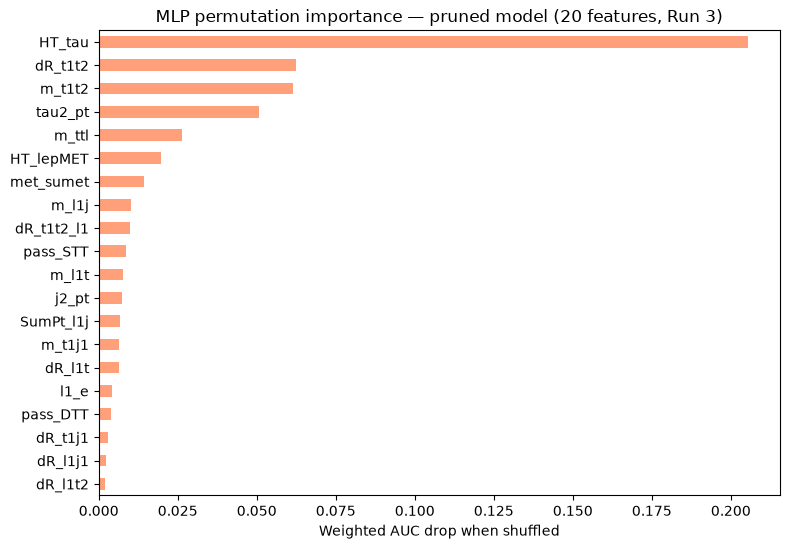

Saved plot -> PPSSP_2026/1l2tau/run3/plots/Run3CorrelationPruned_DNN.png


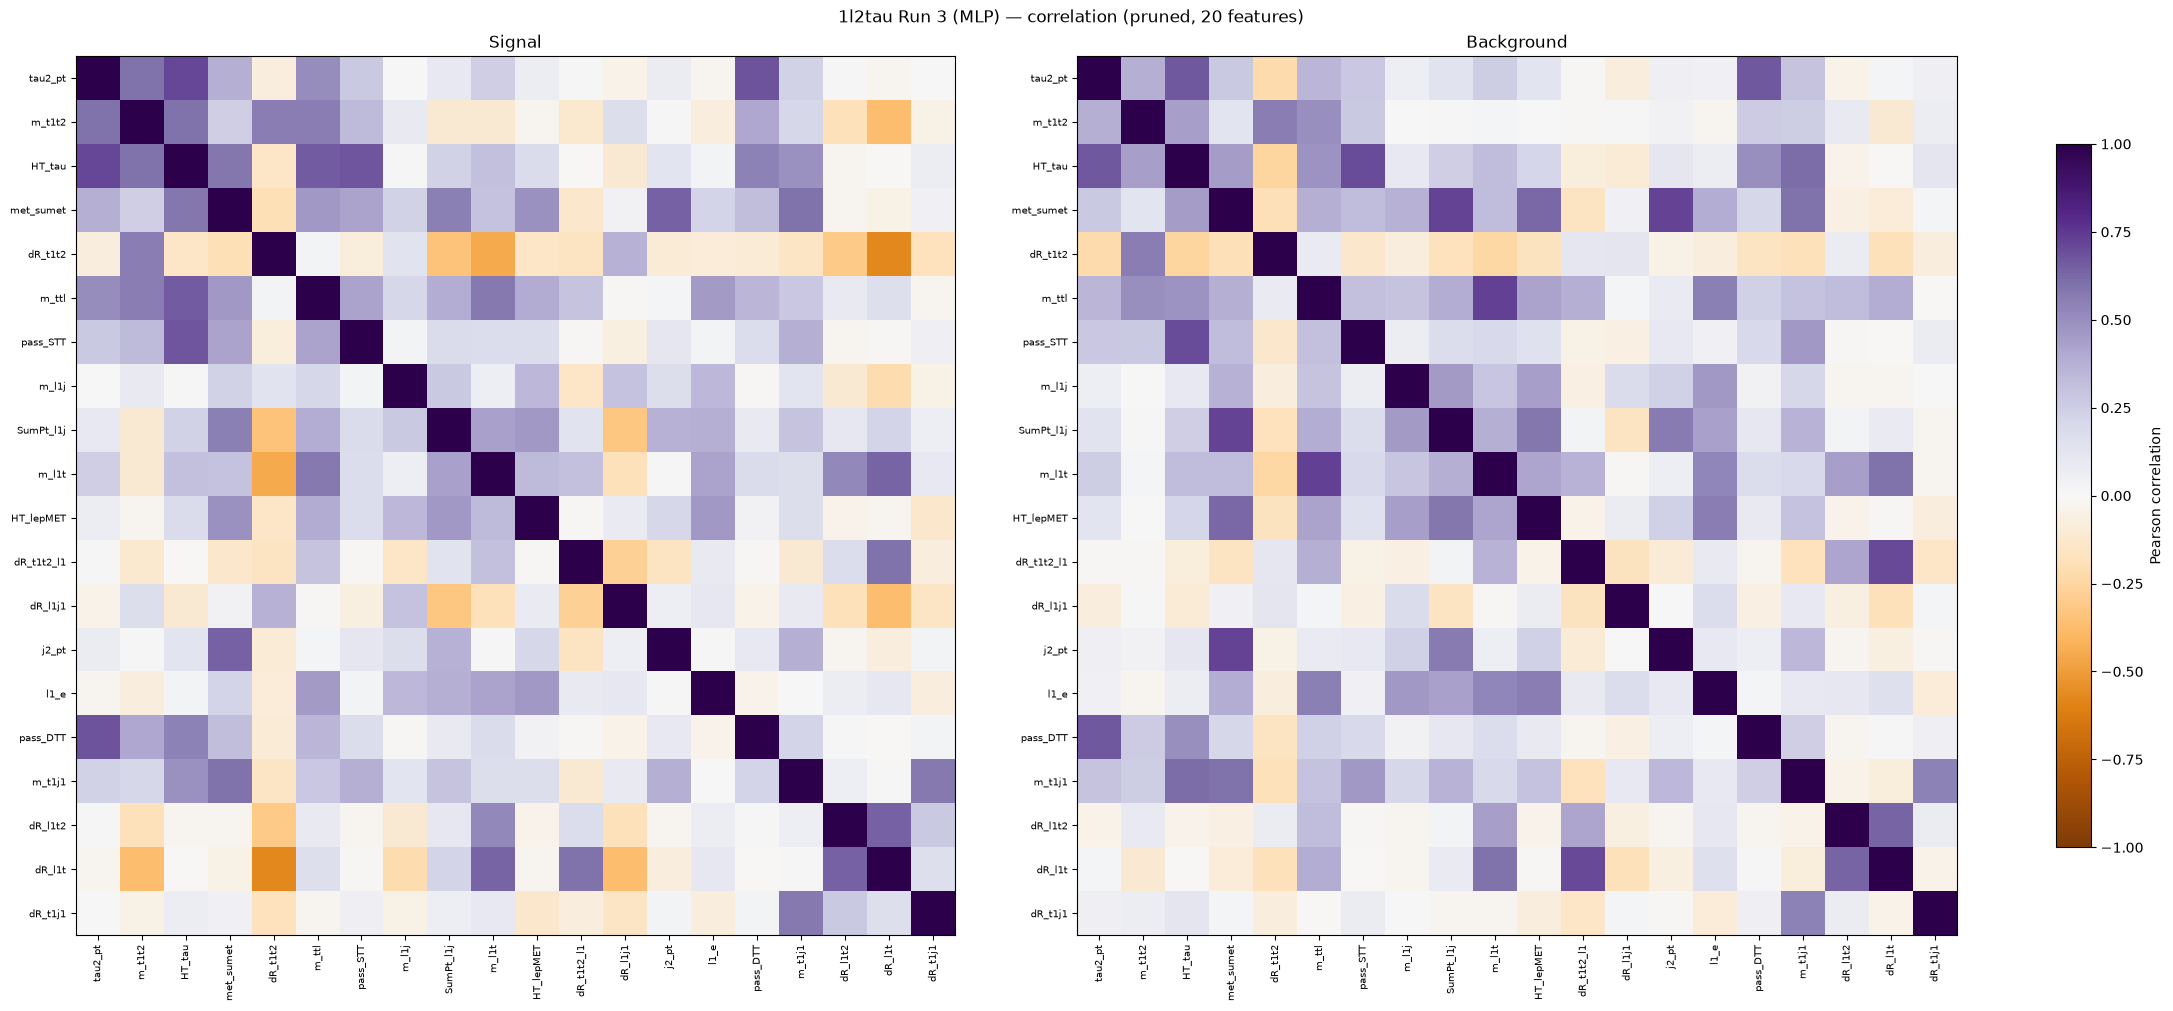

In [ ]:
TOP15_FEATURES_run3, dropped_top15_run3 = prune_correlated(top_feats_run3, corr_max_run3, CORR_THRESH, n_keep=15)

X_train_top15_t_run3, X_val_top15_t_run3, X_test_top15_t_run3 = subset_feature_tensors_fold(fd0_run3, TOP15_FEATURES_run3, features_run3)

model_top15_run3, history_top15_run3, val_auc_top15_run3, train_auc_top15_run3, train_auc_eval_top15_run3 = train_model(
    X_train_top15_t_run3, fd0_run3["y_train_t"], fd0_run3["w_train_fit_t"],
    X_val_top15_t_run3, fd0_run3["y_val_t"], fd0_run3["w_val_abs_t"],
    hidden_sizes=best_hidden_sizes_run3, dropout=best_params_run3["dropout"], lr=best_params_run3["lr"],
    weight_decay=best_params_run3["weight_decay"], batch_size=best_params_run3["batch_size"],
    patience=best_params_run3["patience"], w_train_eval_data=fd0_run3["w_train_abs_t"], verbose=False,
)

importance_top15_run3 = permutation_importance(model_top15_run3, X_val_top15_t_run3, fd0_run3["y_val_t"], fd0_run3["w_val_abs_t"],
                                                TOP15_FEATURES_run3, n_repeats=5)
plot_importance_bar(
    importance_top15_run3, top_n=len(TOP15_FEATURES_run3),
    title=f"DNN permutation importance — top-15 model ({len(TOP15_FEATURES_run3)} features, Run 3)",
    color="mediumseagreen",
    save_path=PLOTS_DIR_R3 / "Run3ImportanceTop15_DNN.png",
)

comparison_run3 = pd.DataFrame([
    {"model": f"Full ({len(features_run3)} features)", "train_auc_eval": best_train_auc_eval_run3, "val_auc": best_val_auc_run3},
    {"model": f"Pruned ({len(PRUNED_FEATURES_run3)} features)", "train_auc_eval": train_auc_eval_pruned_run3, "val_auc": val_auc_pruned_run3},
    {"model": f"Top-15 ({len(TOP15_FEATURES_run3)} features)", "train_auc_eval": train_auc_eval_top15_run3, "val_auc": val_auc_top15_run3},
]).sort_values("val_auc", ascending=False)

print("\nWeighted train(eval-mode)/validation AUC comparison (Run 3, fold-0 preview):")
comparison_run3


## Top-15 Features Only — Run 3

## Physics Figure of Merit & Final Summary — Run 3

Reuses `significance_scan` from the Run 2 section, on VAL (model/cut
selection set). A genuinely blind estimate follows in the "Held-Out Test
Evaluation" cell below: the VAL-selected score cut applied FROZEN to Run 3's
held-out TEST partition.


In [ ]:
# ---- Score the model with the best fold-0-preview val_auc (Full/Pruned/Top-15) -
FEATURE_SETS_R3 = {
    f"Full ({len(features_run3)} features)": (model_run3, features_run3, fd0_run3["X_val_t"]),
    f"Pruned ({len(PRUNED_FEATURES_run3)} features)": (model_pruned_run3, PRUNED_FEATURES_run3, X_val_pruned_t_run3),
    f"Top-15 ({len(TOP15_FEATURES_run3)} features)": (model_top15_run3, TOP15_FEATURES_run3, X_val_top15_t_run3),
}
best_name_run3 = comparison_run3.iloc[0]["model"]
final_model_run3, FINAL_FEATURES_R3, X_val_final_t_run3 = FEATURE_SETS_R3[best_name_run3]

final_model_run3.eval()
with torch.no_grad():
    val_scores_run3 = torch.sigmoid(final_model_run3(X_val_final_t_run3)).cpu().numpy()

y_val_run3 = fd0_run3["val_df"]["label"].to_numpy()
w_val_signed_run3 = fd0_run3["val_df"]["w_phys"].to_numpy()

z_val_run3, thr_val_run3 = significance_scan(y_val_run3, val_scores_run3, w_val_signed_run3)
final_val_auc_run3 = comparison_run3.loc[comparison_run3["model"] == best_name_run3, "val_auc"].iloc[0]
final_train_auc_eval_run3 = comparison_run3.loc[comparison_run3["model"] == best_name_run3, "train_auc_eval"].iloc[0]

print(f"Final feature set (fold-0 preview): {best_name_run3}")
print(f"Weighted val AUC = {final_val_auc_run3:.4f}")
print(f"Max Asimov Z (val) = {z_val_run3:.3f} at score cut = {thr_val_run3:.4f}")


Final model: Top-15 (15 features)
Weighted val AUC = 0.9392
Max Asimov Z (val) = 0.020 at score cut = 0.9787


### K-Fold Production Run & Artifacts (Run 3)

Same as the Run 2 section: `run_kfold_nn` trains one model per fold (frozen
tuned hyperparameters, `best_params_run3`, on `FINAL_FEATURES_R3`) and
scores every event with a model that never trained on it.


In [ ]:
# ---- K-FOLD PRODUCTION RUN (Run 3) -----------------------------------------
flag_cols_final_run3 = [f for f in flag_cols_run3 if f in FINAL_FEATURES_R3]

oof_df_run3, models_run3, scalers_run3, medians_run3 = run_kfold_nn(
    data_run3, FINAL_FEATURES_R3, flag_cols_final_run3, best_params_run3, target_yields_run3,
    cell_cols=(), n_folds=N_FOLDS, label="Run3",
)

oof_auc_run3 = plot_oof_roc(oof_df_run3, title="1l2tau Run 3 (DNN) - OOF ROC")

save_track_artifacts_nn(
    models_run3, scalers_run3, medians_run3, FINAL_FEATURES_R3, flag_cols_final_run3,
    best_params_run3, oof_df_run3, BASE_DIR_RUN3, "run3",
)


Final model: Top-15 (15 features)
Weighted AUC: val = 0.9392  |  test (held-out, scored once) = 0.9410
At the VAL-selected score cut = 0.9787 (frozen, NOT re-scanned on test):
  test S = 0.06 | test B = 6.02 | test Z = 0.023  (val Z was 0.020)


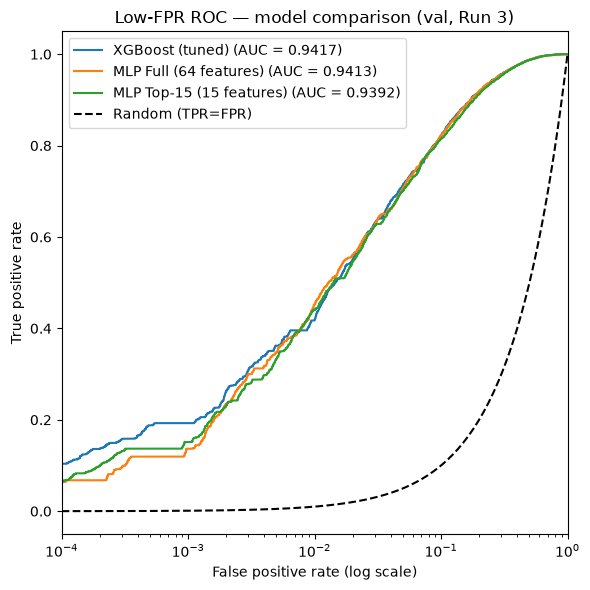

--- FPR = 1e-03 (~112 surviving background MC events) ---
  XGBoost (tuned)                  TPR = 0.1927  (193x random lift)
  MLP Full (64 features)           TPR = 0.1365  (137x random lift)
  MLP Top-15 (15 features)         TPR = 0.1512  (151x random lift)
--- FPR = 1e-02 (~1120 surviving background MC events) ---
  XGBoost (tuned)                  TPR = 0.4172  (42x random lift)
  MLP Full (64 features)           TPR = 0.4528  (45x random lift)
  MLP Top-15 (15 features)         TPR = 0.4408  (44x random lift)


In [ ]:
# ---- Load a tuned XGBoost fold-0 model (same 1l2tau Run 3 track, k-fold
# artifacts from Esteban/1L2Tau_Master_Pipeline.ipynb) for an apples-to-apples
# overlay.
import xgboost as xgb

xgb_model_run3 = xgb.XGBClassifier()
xgb_model_run3.load_model(BASE_DIR_RUN3 / "model_run3_fold0.json")
with open(BASE_DIR_RUN3 / "features_run3.json") as f:
    xgb_features_run3 = json.load(f)

xgb_val_scores_run3 = xgb_model_run3.predict_proba(fd0_run3["val_df"][xgb_features_run3])[:, 1]

fpr_val_run3, tpr_val_run3, _ = roc_curve(y_val_run3, val_scores_run3, sample_weight=w_val_abs_run3)

curves_run3 = {
    "XGBoost (tuned, fold 0)": roc_with_auc(y_val_run3, xgb_val_scores_run3, w_val_abs_run3),
    f"DNN Full ({len(features_run3)} features)": roc_with_auc(y_val_run3, val_probs_run3, w_val_abs_run3),
    f"DNN {best_name_run3}": (fpr_val_run3, tpr_val_run3, final_val_auc_run3),
}

plt.figure(figsize=(6, 6))
for name, (fpr, tpr, auc) in curves_run3.items():
    plt.plot(fpr, tpr, label=f"{name} (AUC = {auc:.4f})")

x_random = np.logspace(-4, 0, 200)
plt.plot(x_random, x_random, "k--", label="Random (TPR=FPR)")

plt.xscale("log")
plt.xlim(1e-4, 1)
plt.xlabel("False positive rate (log scale)")
plt.ylabel("True positive rate")
plt.title("Low-FPR ROC — model comparison (val, Run 3, fold-0 preview)")
plt.legend()
plt.tight_layout()
plt.show()

n_bkg_val_run3 = int((y_val_run3 == 0).sum())
for target_fpr in (1e-3, 1e-2):
    print(f"--- FPR = {target_fpr:.0e} (~{target_fpr * n_bkg_val_run3:.0f} surviving background MC events) ---")
    for name, (fpr, tpr, _) in curves_run3.items():
        idx = min(np.searchsorted(fpr, target_fpr), len(tpr) - 1)
        print(f"  {name:32s} TPR = {tpr[idx]:.4f}  ({tpr[idx] / target_fpr:.0f}x random lift)")


In [ ]:
# ---- Sanity checks --------------------------------------------------------
assert torch.isfinite(fd0_run3["X_train_t"]).all() and torch.isfinite(fd0_run3["X_val_t"]).all(), \
    "NaN/inf reached the model input (Run 3)"

set_seed(RANDOM_STATE)
_, _, det_check_a_run3, _, _ = train_model(
    fd0_run3["X_train_t"], fd0_run3["y_train_t"], fd0_run3["w_train_fit_t"],
    fd0_run3["X_val_t"], fd0_run3["y_val_t"], fd0_run3["w_val_abs_t"],
    hidden_sizes=(64,), n_epochs=5, patience=5, verbose=False,
)

set_seed(RANDOM_STATE)
_, _, det_check_b_run3, _, _ = train_model(
    fd0_run3["X_train_t"], fd0_run3["y_train_t"], fd0_run3["w_train_fit_t"],
    fd0_run3["X_val_t"], fd0_run3["y_val_t"], fd0_run3["w_val_abs_t"],
    hidden_sizes=(64,), n_epochs=5, patience=5, verbose=False,
)
assert det_check_a_run3 == det_check_b_run3, f"Determinism check FAILED: {det_check_a_run3} != {det_check_b_run3}"

print(f"Determinism check passed: two re-seeded runs give identical val_auc = {det_check_a_run3:.6f}")

summary_run3 = pd.DataFrame([{
    "model": best_name_run3,
    "train_auc_eval": final_train_auc_eval_run3,
    "val_auc": final_val_auc_run3,
    "max_asimov_Z (val)": z_val_run3,
}])

print("\nFold-0-preview summary (DNN, 1l2tau Run 3):")
print(summary_run3.to_string(index=False))
summary_run3


Determinism check passed: two re-seeded runs give identical val_auc = 0.902861

Final summary (MLP, 1l2tau Run 3):
               model  train_auc_eval  val_auc  max_asimov_Z (val)  test_auc (held-out, scored once)  test_Z_at_val_cut (held-out)
Top-15 (15 features)        0.940616 0.939236            0.020346                          0.941017                      0.023209


,model,train_auc_eval,val_auc,max_asimov_Z (val),"test_auc (held-out, scored once)",test_Z_at_val_cut (held-out)
0,Top-15 (15 features),0.940616,0.939236,0.020346,0.941017,0.023209


## Run 2 + Run 3 — Combined Track

Chains (concatenates) Run 2 and Run 3 events into a single training sample,
mirroring `1L2Tau_Master_Pipeline.ipynb`'s Section 5. The candidate feature
set is restricted to branches common to BOTH runs (the intersection of
`features_run2` and `features_run3`, equivalent to discovering common
branches across all process files in both directories). An extra `run`
bookkeeping column (2 or 3) is kept (never a training feature) so the
Run2/Run3 mix can be checked, and so the train/val split can be stratified
on `label` AND `run` jointly. Everything below uses `_comb`-suffixed
variable names so the Run 2 and Run 3 results above remain untouched.

In [ ]:
# Combined uses features common to BOTH runs (equivalent to discovering
# common branches across all process files in both directories).

candidate_features_comb = sorted(set(features_run2) & set(features_run3))

keep_cols_comb = candidate_features_comb + ["w_phys", "label", "process", EVENT_ID_BRANCH]

data_run2_tagged = data_run2[keep_cols_comb].copy()
data_run2_tagged["run"] = 2

data_run3_tagged = data_run3[keep_cols_comb].copy()
data_run3_tagged["run"] = 3

data_comb_raw = pd.concat([data_run2_tagged, data_run3_tagged], ignore_index=True)
data_comb, features_comb = clean_data(data_comb_raw, candidate_features_comb)
data_comb = assign_folds(data_comb)

print(f"\nCombined: {len(data_comb)} events, {len(features_comb)} features "
      f"(intersection of Run2's {len(features_run2)} and Run3's {len(features_run3)})")

for run_label in (2, 3):
    sub = data_comb[data_comb["run"] == run_label]
    print(f"Run {run_label}: signal yield = {sub.loc[sub.label==1,'w_phys'].sum():.2f} | "
          f"background yield = {sub.loc[sub.label==0,'w_phys'].sum():.2f} | n_events = {len(sub)}")

print(f"\nFold sizes (fold = eventNumber % {N_FOLDS}):")
print(data_comb["fold"].value_counts().sort_index())


Dropped 0 constant/empty features:
  []

64 final features
Total: 2015576 events | signal = 293764 | background = 1721812
Yield (w_phys): signal = 3.91 | background = 30834.21

Combined: 2015576 events, 64 features (intersection of Run2's 64 and Run3's 64)
Run 2: signal yield = 1.82 | background yield = 11467.29 | n_events = 690684
Run 3: signal yield = 2.08 | background yield = 19366.92 | n_events = 1324892


## Sentinel Audit (-1) — Combined

Same diagnostic as the Run 2/Run 3 sections above, run on the combined
sample.

In [ ]:
NEG1_SENTINEL_FEATURES_comb = set()

neg1_rows_comb = []
for f in features_comb:
    vals = data_comb[f]
    frac_neg1 = (vals == -1).mean()
    if frac_neg1 == 0:
        continue
    above = vals[vals > -1]
    gap = (above.min() - (-1)) if len(above) else np.nan
    neg1_rows_comb.append({"feature": f, "frac_exactly_-1": frac_neg1, "gap_to_next_value_above": gap})

neg1_df_comb = pd.DataFrame(neg1_rows_comb).sort_values("frac_exactly_-1", ascending=False)
print(f"{len(neg1_df_comb)} / {len(features_comb)} features have at least one row exactly equal to -1:")
print(neg1_df_comb.to_string(index=False))

for f in NEG1_SENTINEL_FEATURES_comb:
    data_comb[f] = data_comb[f].mask(data_comb[f] == -1)
if NEG1_SENTINEL_FEATURES_comb:
    print(f"\nMasked -1 -> NaN for: {sorted(NEG1_SENTINEL_FEATURES_comb)}")
else:
    print("\nNEG1_SENTINEL_FEATURES_comb is empty - no -1 values masked.")

1 / 64 features have at least one row exactly equal to -1:
  feature  frac_exactly_-1  gap_to_next_value_above
l1_charge         0.474537                      2.0

NEG1_SENTINEL_FEATURES_comb is empty - no -1 values masked.


## Train/Validation/Test Split & Preprocessing — Combined

Same 80/10/10 `make_3way_split`, but stratified on `label` AND `run` jointly
(not just `label`) so all three partitions keep the same Run2/Run3 mix -
passed via `extra_stratify_col="run"`. TEST is held out (persisted + never
used for imputation/scaling/pruning/tuning/early stopping) the same way as
the Run 2/Run 3 sections. Preprocessing (median imputation, standard
scaling, `__isnan` flags) otherwise follows the same convention.


In [ ]:
# ---- Weight-balance diagnostics (Combined, representative fold 0) ---------
BASE_DIR_COMB = Path("PPSSP_2026/1l2tau/combined")
PLOTS_DIR_COMB = BASE_DIR_COMB / "plots"
PLOTS_DIR_COMB.mkdir(parents=True, exist_ok=True)

target_yields_comb = compute_process_yield_targets(data_comb)
flag_cols_comb = compute_flag_cols(data_comb, features_comb)
N_FEATURES_MODEL = len(features_comb) + len(flag_cols_comb)

fd0_comb = prepare_fold_tensors(data_comb, features_comb, flag_cols_comb, target_yields_comb,
                                 cell_cols=("run",), n_folds=N_FOLDS, k=0)

w_before_comb = fd0_comb["train_df"]["w_phys"].to_numpy()
w_after_comb = fd0_comb["w_train_fit"]
y_preview_comb = fd0_comb["train_df"]["label"].to_numpy()

plot_weight_balance(
    y_preview_comb, w_before_comb, w_after_comb,
    title="Combined (DNN) - make_fit_weights balancing (fold 0 train, per-run cell)",
    save_path=PLOTS_DIR_COMB / "CombinedWeightBalance_DNN.png",
)

print(f"{len(flag_cols_comb)} features had missing values in train (globally) -> added "
      f"{len(flag_cols_comb)} __isnan flag columns (final model input width = {N_FEATURES_MODEL} = "
      f"{len(features_comb)} features + {len(flag_cols_comb)} flags)")

print("\nN_eff (training sample, positive-only, post yield-rescale) by run x label - fold 0:")
print(n_eff_table(fd0_comb["train_df"], ["run", "label"]))
print("\nN_eff (eval sample, signed, FULL fold-0 test partition) by run x label:")
print(n_eff_table(fd0_comb["test_df"], ["run", "label"]))
print(f"\nDropped {fd0_comb['n_dropped_train']} negative-w_phys training rows in this "
      f"preview fold (kept, not abs'd, elsewhere - see prepare_fold_data).")


Train:  1612460 events | signal =  235011 (yield=      3.13) | background = 1377449 (yield=  24677.47) | signal weight scale factor = 7886.8
       run mix: {2: 552547, 3: 1059913}
Val  :   201558 events | signal =   29377 (yield=      0.39) | background =  172181 (yield=   3213.90) | signal weight scale factor = 8315.5
       run mix: {2: 69069, 3: 132489}
Test :   201558 events | signal =   29376 (yield=      0.39) | background =  172182 (yield=   2942.84) | signal weight scale factor = 7548.5
       run mix: {2: 69068, 3: 132490}
  cross-check OK: PPSSP_2026/1l2tau/combined/splits/test.root test partition matches on 67 shared columns (201558 rows)
Wrote 201558 test events -> PPSSP_2026/1l2tau/combined/splits/test.root  (held out until final evaluation)

0 features had missing values in train -> added 0 __isnan flag columns (final input width = 64 = 64 features + 0 flags)
Signal weight scale factor (train): 10813.0


In [ ]:
plot_scaling_before_after(
    fd0_comb["train_df"], features_comb, fd0_comb["train_medians"], fd0_comb["scaler"],
    weights=fd0_comb["w_train_fit"],
    title="Combined (DNN) - median-impute + StandardScaler (fold 0 train)",
    save_path=PLOTS_DIR_COMB / "CombinedScalingBeforeAfter_DNN.png",
)


## PyTorch Dataset & Model — Combined

In [ ]:
model_comb = build_model(n_features=fd0_comb["n_features_model"])

print(model_comb)


SimpleMLP(
  (net): Sequential(
    (0): Linear(in_features=64, out_features=256, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.3, inplace=False)
    (3): Linear(in_features=256, out_features=256, bias=True)
    (4): ReLU()
    (5): Dropout(p=0.3, inplace=False)
    (6): Linear(in_features=256, out_features=128, bias=True)
    (7): ReLU()
    (8): Dropout(p=0.3, inplace=False)
    (9): Linear(in_features=128, out_features=128, bias=True)
    (10): ReLU()
    (11): Dropout(p=0.3, inplace=False)
    (12): Linear(in_features=128, out_features=64, bias=True)
    (13): ReLU()
    (14): Dropout(p=0.3, inplace=False)
    (15): Linear(in_features=64, out_features=32, bias=True)
    (16): ReLU()
    (17): Dropout(p=0.3, inplace=False)
    (18): Linear(in_features=32, out_features=1, bias=True)
  )
)


## Training Loop — Combined

Reuses the same `train_model`/`run_epoch` functions defined in the Run 2
section above, with explicit `_comb` tensors passed in so the Run 2/Run 3
models/histories are untouched.

In [ ]:
# ---- Fold-0 preview baseline (default hyperparameters) ---------------------

model_comb, history_comb, best_val_auc_comb, best_train_auc_comb, best_train_auc_eval_comb = train_model(
    fd0_comb["X_train_t"], fd0_comb["y_train_t"], fd0_comb["w_train_fit_t"],
    fd0_comb["X_val_t"], fd0_comb["y_val_t"], fd0_comb["w_val_abs_t"],
    hidden_sizes=DEFAULT_HIDDEN_SIZES, w_train_eval_data=fd0_comb["w_train_abs_t"],
)

print(f"\nBest val_auc = {best_val_auc_comb:.4f} | train_auc (dropout on) = {best_train_auc_comb:.4f} "
      f"| train_auc_eval (dropout off, comparable) = {best_train_auc_eval_comb:.4f}")


Epoch   1 | train_loss=0.4523 val_loss=0.3679 | train_auc=0.8834 train_auc_eval=0.9191 val_auc=0.9208
Epoch   2 | train_loss=0.3873 val_loss=0.3264 | train_auc=0.9129 train_auc_eval=0.9269 val_auc=0.9271
Epoch   3 | train_loss=0.3615 val_loss=0.3031 | train_auc=0.9205 train_auc_eval=0.9309 val_auc=0.9293
Epoch   4 | train_loss=0.3542 val_loss=0.3446 | train_auc=0.9236 train_auc_eval=0.9333 val_auc=0.9311
Epoch   5 | train_loss=0.3477 val_loss=0.3813 | train_auc=0.9264 train_auc_eval=0.9356 val_auc=0.9326
Epoch   6 | train_loss=0.3453 val_loss=0.3084 | train_auc=0.9275 train_auc_eval=0.9368 val_auc=0.9336
Epoch   7 | train_loss=0.3424 val_loss=0.3395 | train_auc=0.9286 train_auc_eval=0.9372 val_auc=0.9339
Epoch   8 | train_loss=0.3390 val_loss=0.3378 | train_auc=0.9300 train_auc_eval=0.9385 val_auc=0.9344
Epoch   9 | train_loss=0.3363 val_loss=0.3386 | train_auc=0.9312 train_auc_eval=0.9402 val_auc=0.9358
Epoch  10 | train_loss=0.3347 val_loss=0.3185 | train_auc=0.9318 train_auc_eval=0.

## Simple Hyperparameter Search (hidden layer sizes) — Combined

In [ ]:
study_comb = run_optuna_search_nn(data_comb, features_comb, flag_cols_comb, target_yields_comb,
                                   cell_cols=("run",), study_name="dnn_opt_combined")
best_params_comb = params_from_study_nn(study_comb)
best_hidden_sizes_comb = best_params_comb["hidden_sizes"]
plot_optuna_diagnostics_nn(study_comb, title_suffix="(1l2tau, Combined, DNN)")

# ---- Refit the fold-0 preview model with the tuned hyperparameters -------
model_comb, history_comb, best_val_auc_comb, best_train_auc_comb, best_train_auc_eval_comb = train_model(
    fd0_comb["X_train_t"], fd0_comb["y_train_t"], fd0_comb["w_train_fit_t"],
    fd0_comb["X_val_t"], fd0_comb["y_val_t"], fd0_comb["w_val_abs_t"],
    hidden_sizes=best_params_comb["hidden_sizes"], dropout=best_params_comb["dropout"],
    lr=best_params_comb["lr"], weight_decay=best_params_comb["weight_decay"],
    batch_size=best_params_comb["batch_size"], patience=best_params_comb["patience"],
    w_train_eval_data=fd0_comb["w_train_abs_t"], verbose=False,
)
print(f"\nTuned fold-0 preview: val_auc={best_val_auc_comb:.4f} | hidden_sizes={best_hidden_sizes_comb}")


hidden_sizes=(64,)            -> train_auc=0.9317 val_auc=0.9354


hidden_sizes=(128, 64)        -> train_auc=0.9396 val_auc=0.9398
hidden_sizes=(256, 128)       -> train_auc=0.9429 val_auc=0.9401
hidden_sizes=(128, 64, 32)    -> train_auc=0.9385 val_auc=0.9395
hidden_sizes=(256, 128, 64, 32) -> train_auc=0.9431 val_auc=0.9405

Best architecture: hidden_sizes=(256, 128, 64, 32) | val_auc=0.9405


## Evaluation — Combined

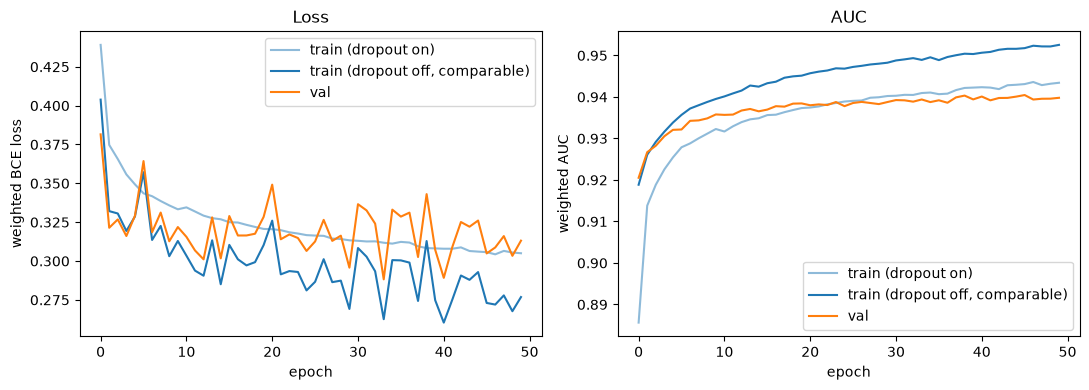

Final weighted AUC: train=0.9518 val=0.9405


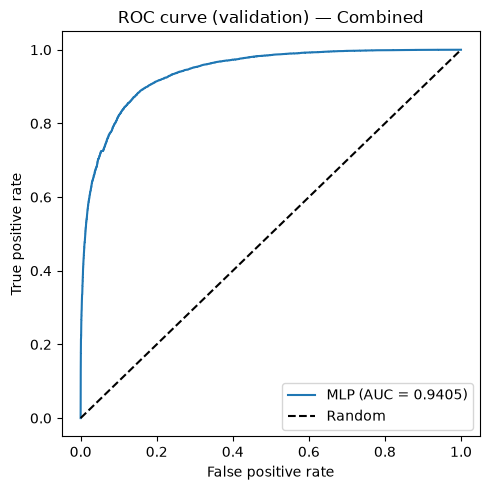

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

axes[0].plot(history_comb["train_loss"], label="train (dropout on)", color="tab:blue", alpha=0.5)
axes[0].plot(history_comb["train_loss_eval"], label="train (dropout off, comparable)", color="tab:blue")
axes[0].plot(history_comb["val_loss"], label="val", color="tab:orange")
axes[0].set_xlabel("epoch")
axes[0].set_ylabel("weighted BCE loss")
axes[0].set_title("Loss")
axes[0].legend()

axes[1].plot(history_comb["train_auc"], label="train (dropout on)", color="tab:blue", alpha=0.5)
axes[1].plot(history_comb["train_auc_eval"], label="train (dropout off, comparable)", color="tab:blue")
axes[1].plot(history_comb["val_auc"], label="val", color="tab:orange")
axes[1].set_xlabel("epoch")
axes[1].set_ylabel("weighted AUC")
axes[1].set_title("AUC")
axes[1].legend()

plt.tight_layout()
plt.show()

model_comb.eval()
with torch.no_grad():
    train_probs_comb = torch.sigmoid(model_comb(fd0_comb["X_train_t"])).cpu().numpy()
    val_probs_comb = torch.sigmoid(model_comb(fd0_comb["X_val_t"])).cpu().numpy()

y_train_comb, y_val_comb = fd0_comb["train_df"]["label"].to_numpy(), fd0_comb["val_df"]["label"].to_numpy()
w_train_abs_comb = fd0_comb["train_df"]["w_phys"].to_numpy()
w_val_abs_comb = np.abs(fd0_comb["val_df"]["w_phys"].to_numpy())

auc_train_comb = roc_auc_score(y_train_comb, train_probs_comb, sample_weight=w_train_abs_comb)
auc_val_comb = roc_auc_score(y_val_comb, val_probs_comb, sample_weight=w_val_abs_comb)

print(f"Final weighted AUC (fold-0 preview): train={auc_train_comb:.4f} val={auc_val_comb:.4f}")

fpr_comb, tpr_comb, _ = roc_curve(y_val_comb, val_probs_comb, sample_weight=w_val_abs_comb)
plt.figure(figsize=(5, 5))
plt.plot(fpr_comb, tpr_comb, label=f"DNN (AUC = {auc_val_comb:.4f})")
plt.plot([0, 1], [0, 1], "k--", label="Random")
plt.xlabel("False positive rate")
plt.ylabel("True positive rate")
plt.title("ROC curve (validation, fold-0 preview) — Combined")
plt.legend()
plt.tight_layout()
plt.show()


## Feature Importance (Permutation) — Combined

Reuses the same `permutation_importance`/`plot_importance_bar` helpers
defined in the Run 2 section.

Baseline weighted AUC: 0.9405


Saved plot -> PPSSP_2026/1l2tau/combined/plots/CombinedImportanceFull_DNN.png


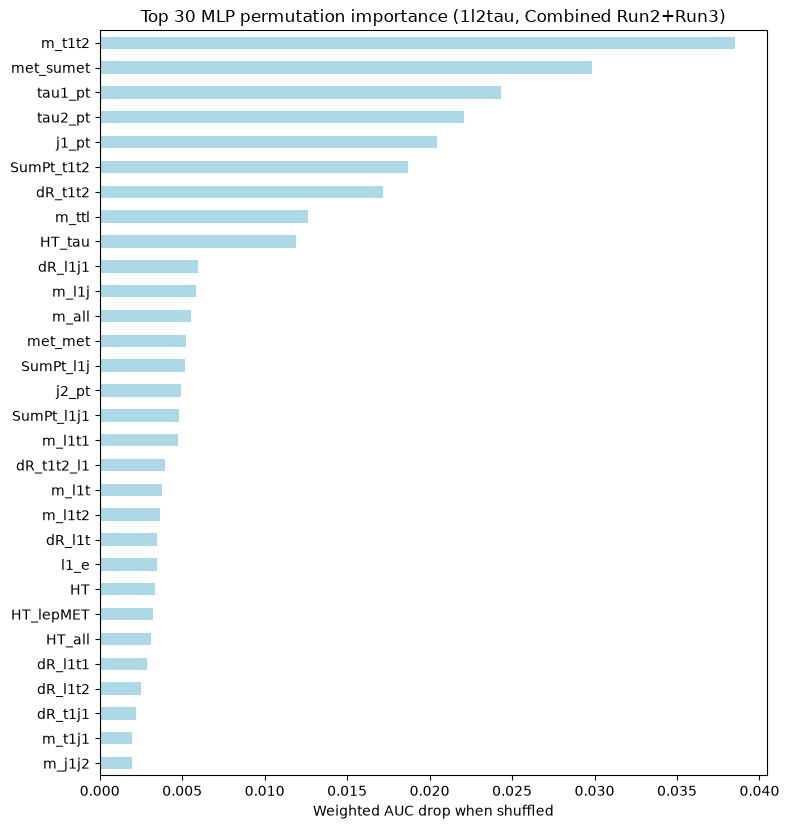

m_t1t2        0.038532
met_sumet     0.029843
tau1_pt       0.024355
tau2_pt       0.022103
j1_pt         0.020424
SumPt_t1t2    0.018713
dR_t1t2       0.017169
m_ttl         0.012623
HT_tau        0.011896
dR_l1j1       0.005948
m_l1j         0.005854
m_all         0.005543
met_met       0.005209
SumPt_l1j     0.005163
j2_pt         0.004907
Name: auc_drop, dtype: float64

In [ ]:
importance_comb = permutation_importance(model_comb, fd0_comb["X_val_t"], fd0_comb["y_val_t"], fd0_comb["w_val_abs_t"],
                                          features_comb, n_repeats=5)
plot_importance_bar(importance_comb, top_n=30, title="Top 30 DNN permutation importance (1l2tau, Combined Run2+Run3, fold-0 preview)",
                     save_path=PLOTS_DIR_COMB / "CombinedImportanceFull_DNN.png")
importance_comb.head(15)


## Correlation Pruning & Retraining — Combined

Reuses `top_pairs`/`grouped_correlations`/`plot_group_correlations`/
`prune_correlated` from the Run 2 section (they take `data`/features as
plain arguments, so they work unchanged on the combined inputs).

Saved plot -> PPSSP_2026/1l2tau/combined/plots/CombinedCorrelationTop30_DNN.png


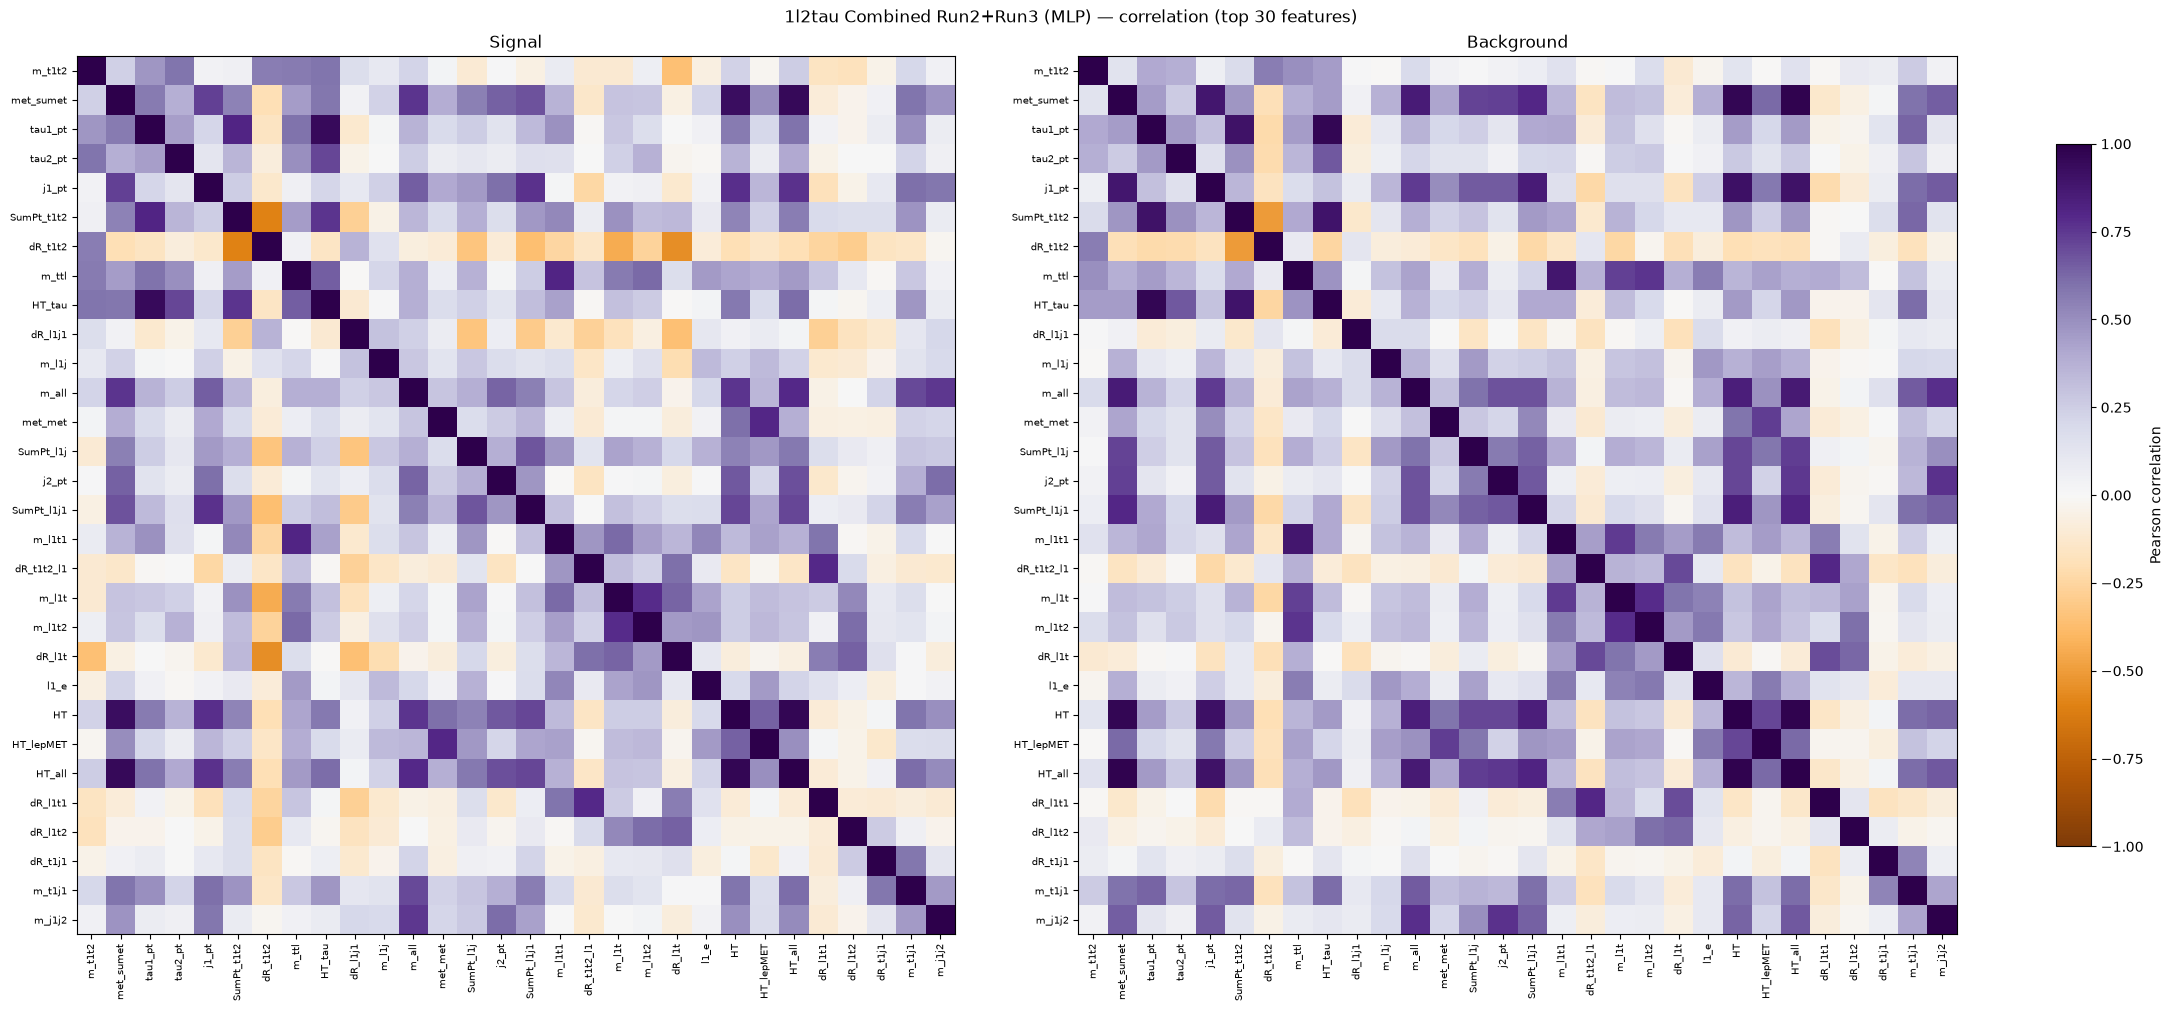

Pairs with |corr| > 0.50 (signal):
HT          HT_all        0.966265
met_sumet   HT_all        0.949262
tau1_pt     HT_tau        0.944697
met_sumet   HT            0.925993
tau1_pt     SumPt_t1t2    0.810478
m_ttl       m_l1t1        0.808434
met_met     HT_lepMET     0.797994
dR_t1t2_l1  dR_l1t1       0.794381
m_all       HT_all        0.792123
m_l1t       m_l1t2        0.784638
j1_pt       HT            0.778276
            HT_all        0.773087
            SumPt_l1j1    0.768729
SumPt_t1t2  HT_tau        0.765479
m_all       HT            0.762113
met_sumet   m_all         0.758895
m_all       m_j1j2        0.751064
met_sumet   j1_pt         0.733829
SumPt_l1j1  HT_all        0.717315
            HT            0.715588
tau2_pt     HT_tau        0.712720
m_all       m_t1j1        0.707748

Pairs with |corr| > 0.50 (background):
met_sumet   HT_all        0.980921
HT          HT_all        0.979413
tau1_pt     HT_tau        0.967221
met_sumet   HT            0.962378
j1_pt       HT 

In [ ]:
# ---- Correlation of the top-30 permutation-important features -------------
top_feats_comb = importance_comb.index[:TOP_N_IMPORTANCE].tolist()
corrs_comb = grouped_correlations(fd0_comb["train_df"], top_feats_comb, group_col="label", group_values=[1, 0])

plot_group_correlations(
    [corrs_comb[1], corrs_comb[0]], ["Signal", "Background"], top_feats_comb,
    suptitle=f"1l2tau Combined Run2+Run3 (DNN) — correlation (top {TOP_N_IMPORTANCE} features, fold-0 preview)",
    save_path=PLOTS_DIR_COMB / "CombinedCorrelationTop30_DNN.png",
)

print("Pairs with |corr| > 0.50 (signal):")
print(top_pairs(corrs_comb[1]).to_string())
print("\nPairs with |corr| > 0.50 (background):")
print(top_pairs(corrs_comb[0]).to_string())


In [ ]:
# ---- Correlation-based pruning to a decorrelated top-20 --------------------
corr_max_comb = corrs_comb[1].abs().combine(corrs_comb[0].abs(), np.maximum)
PRUNED_FEATURES_comb, dropped_features_comb = prune_correlated(top_feats_comb, corr_max_comb, CORR_THRESH, N_KEEP)

Kept 18 decorrelated features (most -> least important):
   1. m_t1t2
   2. met_sumet
   3. tau1_pt
   4. tau2_pt
   5. dR_t1t2
   6. m_ttl
   7. dR_l1j1
   8. m_l1j
   9. met_met
  10. SumPt_l1j
  11. j2_pt
  12. dR_t1t2_l1
  13. m_l1t
  14. dR_l1t
  15. l1_e
  16. dR_l1t2
  17. dR_t1j1
  18. m_t1j1

Dropped 12 redundant features (|corr| > 0.75 with a more important feature):
  j1_pt           -> redundant with met_sumet       (|corr| = 0.880)
  SumPt_t1t2      -> redundant with tau1_pt         (|corr| = 0.903)
  HT_tau          -> redundant with tau1_pt         (|corr| = 0.967)
  m_all           -> redundant with met_sumet       (|corr| = 0.854)
  SumPt_l1j1      -> redundant with met_sumet       (|corr| = 0.797)
  m_l1t1          -> redundant with m_ttl           (|corr| = 0.879)
  m_l1t2          -> redundant with m_ttl           (|corr| = 0.761)
  HT              -> redundant with met_sumet       (|corr| = 0.962)
  HT_lepMET       -> redundant with met_met         (|corr| = 0.798)

Full model      (64 features): train_auc_eval = 0.9518 | val_auc = 0.9405
Pruned model     (18 features): train_auc_eval = 0.9437 | val_auc = 0.9396
Baseline weighted AUC: 0.9396
Saved plot -> PPSSP_2026/1l2tau/combined/plots/CombinedImportancePruned_DNN.png


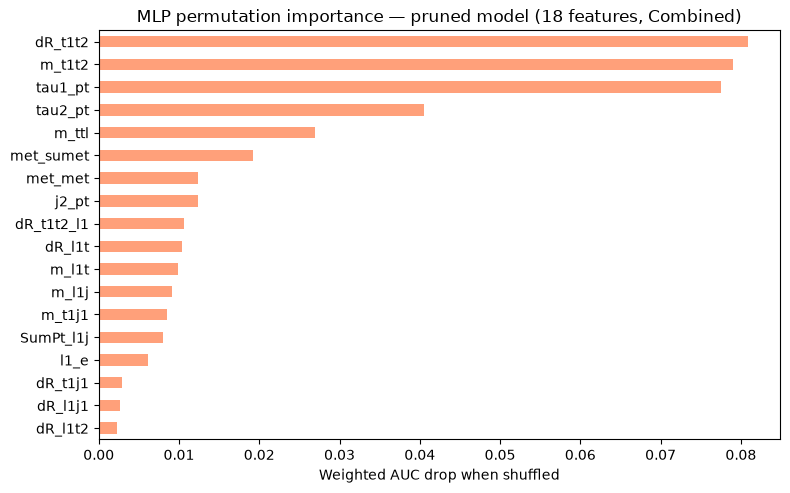

Saved plot -> PPSSP_2026/1l2tau/combined/plots/CombinedCorrelationPruned_DNN.png


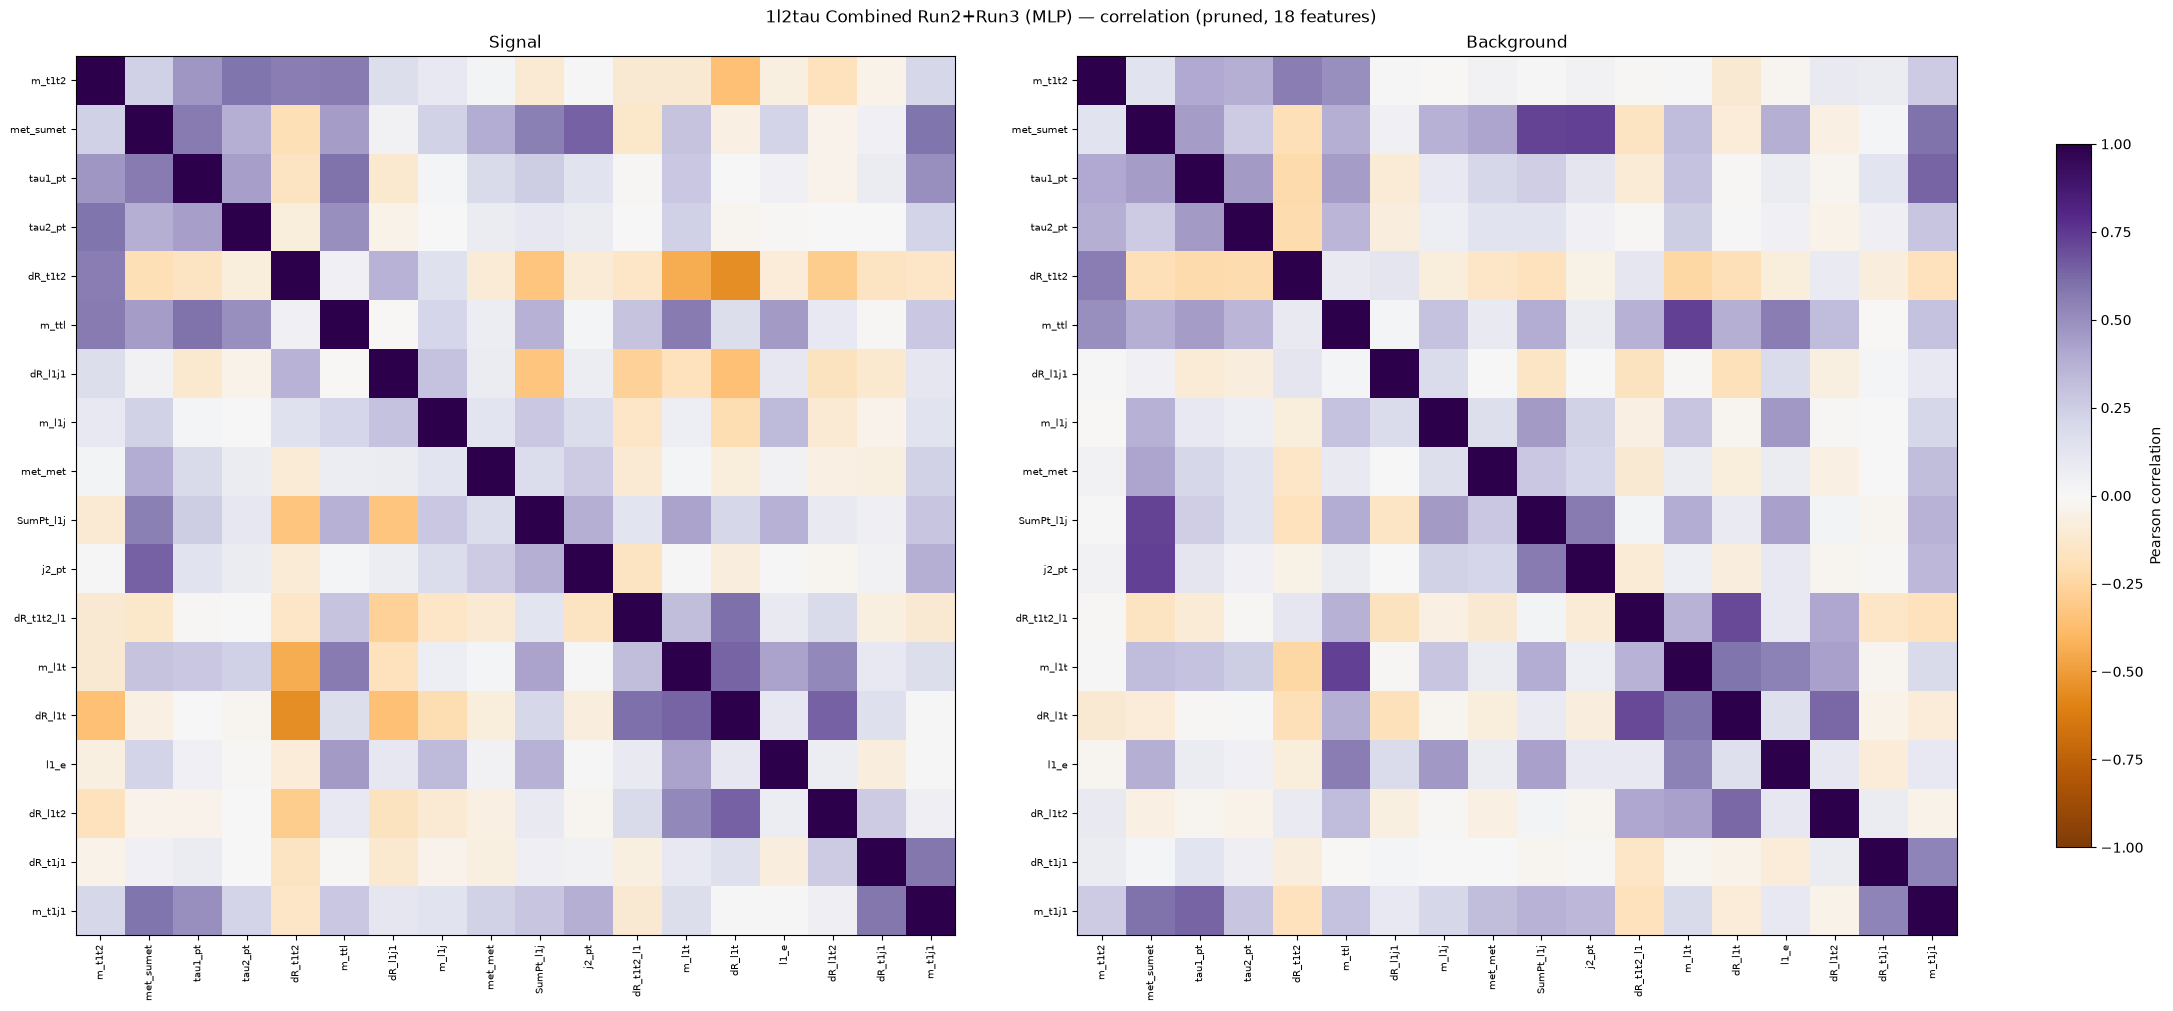

In [ ]:
# ---- Retrain on the pruned feature set (fold-0 preview) --------------------
X_train_pruned_t_comb, X_val_pruned_t_comb, X_test_pruned_t_comb = subset_feature_tensors_fold(fd0_comb, PRUNED_FEATURES_comb, features_comb)

model_pruned_comb, history_pruned_comb, val_auc_pruned_comb, train_auc_pruned_comb, train_auc_eval_pruned_comb = train_model(
    X_train_pruned_t_comb, fd0_comb["y_train_t"], fd0_comb["w_train_fit_t"],
    X_val_pruned_t_comb, fd0_comb["y_val_t"], fd0_comb["w_val_abs_t"],
    hidden_sizes=best_hidden_sizes_comb, dropout=best_params_comb["dropout"], lr=best_params_comb["lr"],
    weight_decay=best_params_comb["weight_decay"], batch_size=best_params_comb["batch_size"],
    patience=best_params_comb["patience"], w_train_eval_data=fd0_comb["w_train_abs_t"], verbose=False,
)

print(f"Full model      ({len(features_comb):2d} features): train_auc_eval = {best_train_auc_eval_comb:.4f} | val_auc = {best_val_auc_comb:.4f}")
print(f"Pruned model     ({len(PRUNED_FEATURES_comb):2d} features): train_auc_eval = {train_auc_eval_pruned_comb:.4f} | val_auc = {val_auc_pruned_comb:.4f}")

importance_pruned_comb = permutation_importance(model_pruned_comb, X_val_pruned_t_comb, fd0_comb["y_val_t"], fd0_comb["w_val_abs_t"],
                                                 PRUNED_FEATURES_comb, n_repeats=5)
plot_importance_bar(
    importance_pruned_comb, top_n=len(PRUNED_FEATURES_comb),
    title=f"DNN permutation importance — pruned model ({len(PRUNED_FEATURES_comb)} features, Combined)",
    color="lightsalmon",
    save_path=PLOTS_DIR_COMB / "CombinedImportancePruned_DNN.png",
)

pruned_corrs_comb = grouped_correlations(fd0_comb["train_df"], PRUNED_FEATURES_comb, group_col="label", group_values=[1, 0])
plot_group_correlations(
    [pruned_corrs_comb[1], pruned_corrs_comb[0]], ["Signal", "Background"], PRUNED_FEATURES_comb,
    suptitle=f"1l2tau Combined Run2+Run3 (DNN) — correlation (pruned, {len(PRUNED_FEATURES_comb)} features, fold-0 preview)",
    save_path=PLOTS_DIR_COMB / "CombinedCorrelationPruned_DNN.png",
)


## Top-15 Features Only — Combined

In [ ]:
TOP15_FEATURES_comb, dropped_top15_comb = prune_correlated(top_feats_comb, corr_max_comb, CORR_THRESH, n_keep=15)

X_train_top15_t_comb, X_val_top15_t_comb, X_test_top15_t_comb = subset_feature_tensors_fold(fd0_comb, TOP15_FEATURES_comb, features_comb)

model_top15_comb, history_top15_comb, val_auc_top15_comb, train_auc_top15_comb, train_auc_eval_top15_comb = train_model(
    X_train_top15_t_comb, fd0_comb["y_train_t"], fd0_comb["w_train_fit_t"],
    X_val_top15_t_comb, fd0_comb["y_val_t"], fd0_comb["w_val_abs_t"],
    hidden_sizes=best_hidden_sizes_comb, dropout=best_params_comb["dropout"], lr=best_params_comb["lr"],
    weight_decay=best_params_comb["weight_decay"], batch_size=best_params_comb["batch_size"],
    patience=best_params_comb["patience"], w_train_eval_data=fd0_comb["w_train_abs_t"], verbose=False,
)

importance_top15_comb = permutation_importance(model_top15_comb, X_val_top15_t_comb, fd0_comb["y_val_t"], fd0_comb["w_val_abs_t"],
                                                TOP15_FEATURES_comb, n_repeats=5)
plot_importance_bar(
    importance_top15_comb, top_n=len(TOP15_FEATURES_comb),
    title=f"DNN permutation importance — top-15 model ({len(TOP15_FEATURES_comb)} features, Combined)",
    color="mediumseagreen",
    save_path=PLOTS_DIR_COMB / "CombinedImportanceTop15_DNN.png",
)

comparison_comb = pd.DataFrame([
    {"model": f"Full ({len(features_comb)} features)", "train_auc_eval": best_train_auc_eval_comb, "val_auc": best_val_auc_comb},
    {"model": f"Pruned ({len(PRUNED_FEATURES_comb)} features)", "train_auc_eval": train_auc_eval_pruned_comb, "val_auc": val_auc_pruned_comb},
    {"model": f"Top-15 ({len(TOP15_FEATURES_comb)} features)", "train_auc_eval": train_auc_eval_top15_comb, "val_auc": val_auc_top15_comb},
]).sort_values("val_auc", ascending=False)

print("\nWeighted train(eval-mode)/validation AUC comparison (Combined, fold-0 preview):")
comparison_comb


Kept 15 decorrelated features (most -> least important):
   1. m_t1t2
   2. met_sumet
   3. tau1_pt
   4. tau2_pt
   5. dR_t1t2
   6. m_ttl
   7. dR_l1j1
   8. m_l1j
   9. met_met
  10. SumPt_l1j
  11. j2_pt
  12. dR_t1t2_l1
  13. m_l1t
  14. dR_l1t
  15. l1_e

Dropped 7 redundant features (|corr| > 0.75 with a more important feature):
  j1_pt           -> redundant with met_sumet       (|corr| = 0.880)
  SumPt_t1t2      -> redundant with tau1_pt         (|corr| = 0.903)
  HT_tau          -> redundant with tau1_pt         (|corr| = 0.967)
  m_all           -> redundant with met_sumet       (|corr| = 0.854)
  SumPt_l1j1      -> redundant with met_sumet       (|corr| = 0.797)
  m_l1t1          -> redundant with m_ttl           (|corr| = 0.879)
  m_l1t2          -> redundant with m_ttl           (|corr| = 0.761)


KeyboardInterrupt: 

## Physics Figure of Merit & Final Summary — Combined

Reuses `significance_scan` from the Run 2 section, on VAL (model/cut
selection set). A genuinely blind estimate follows in the "Held-Out Test
Evaluation" cell below: the VAL-selected score cut applied FROZEN to the
Combined track's held-out TEST partition.


In [ ]:
# ---- Score the model with the best fold-0-preview val_auc (Full/Pruned/Top-15) -
FEATURE_SETS_COMB = {
    f"Full ({len(features_comb)} features)": (model_comb, features_comb, fd0_comb["X_val_t"]),
    f"Pruned ({len(PRUNED_FEATURES_comb)} features)": (model_pruned_comb, PRUNED_FEATURES_comb, X_val_pruned_t_comb),
    f"Top-15 ({len(TOP15_FEATURES_comb)} features)": (model_top15_comb, TOP15_FEATURES_comb, X_val_top15_t_comb),
}
best_name_comb = comparison_comb.iloc[0]["model"]
final_model_comb, FINAL_FEATURES_COMB, X_val_final_t_comb = FEATURE_SETS_COMB[best_name_comb]

final_model_comb.eval()
with torch.no_grad():
    val_scores_comb = torch.sigmoid(final_model_comb(X_val_final_t_comb)).cpu().numpy()

y_val_comb = fd0_comb["val_df"]["label"].to_numpy()
w_val_signed_comb = fd0_comb["val_df"]["w_phys"].to_numpy()

z_val_comb, thr_val_comb = significance_scan(y_val_comb, val_scores_comb, w_val_signed_comb)
final_val_auc_comb = comparison_comb.loc[comparison_comb["model"] == best_name_comb, "val_auc"].iloc[0]
final_train_auc_eval_comb = comparison_comb.loc[comparison_comb["model"] == best_name_comb, "train_auc_eval"].iloc[0]

print(f"Final feature set (fold-0 preview): {best_name_comb}")
print(f"Weighted val AUC = {final_val_auc_comb:.4f}")
print(f"Max Asimov Z (val) = {z_val_comb:.3f} at score cut = {thr_val_comb:.4f}")


Final model: Top-15 (15 features)
Weighted val AUC = 0.9375
Max Asimov Z (val) = 0.046 at score cut = 0.9875


### K-Fold Production Run & Artifacts (Combined)

Same as the Run 2/Run 3 sections: `run_kfold_nn` trains one model per fold
(frozen tuned hyperparameters, `best_params_comb`, on `FINAL_FEATURES_COMB`,
per-run cell-balanced via `cell_cols=("run",)`) and scores every event with
a model that never trained on it.


In [ ]:
# ---- K-FOLD PRODUCTION RUN (Combined) --------------------------------------
flag_cols_final_comb = [f for f in flag_cols_comb if f in FINAL_FEATURES_COMB]

oof_df_comb, models_comb, scalers_comb, medians_comb = run_kfold_nn(
    data_comb, FINAL_FEATURES_COMB, flag_cols_final_comb, best_params_comb, target_yields_comb,
    cell_cols=("run",), n_folds=N_FOLDS, label="Combined",
)

oof_auc_comb = plot_oof_roc(oof_df_comb, title="1l2tau Combined Run2+Run3 (DNN) - OOF ROC")

save_track_artifacts_nn(
    models_comb, scalers_comb, medians_comb, FINAL_FEATURES_COMB, flag_cols_final_comb,
    best_params_comb, oof_df_comb, BASE_DIR_COMB, "combined",
)


Final model: Top-15 (15 features)
Weighted AUC: val = 0.9375  |  test (held-out, scored once) = 0.9392
At the VAL-selected score cut = 0.9875 (frozen, NOT re-scanned on test):
  test S = 0.07 | test B = 3.47 | test Z = 0.039  (val Z was 0.046)


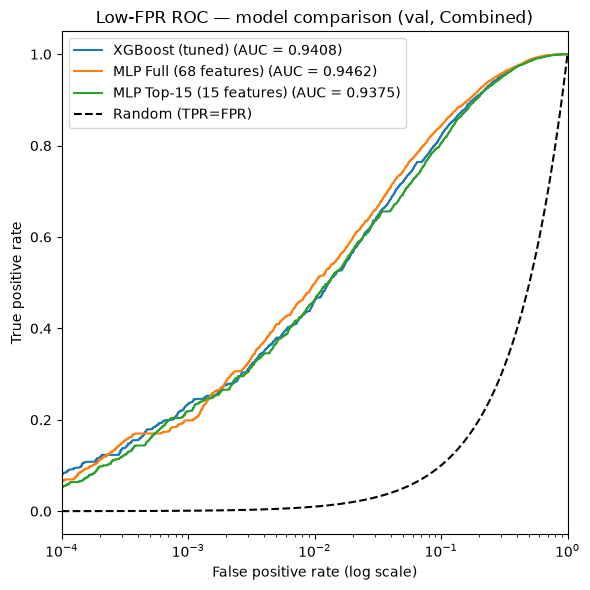

--- FPR = 1e-03 (~172 surviving background MC events) ---
  XGBoost (tuned)                  TPR = 0.2346  (235x random lift)
  MLP Full (68 features)           TPR = 0.1986  (199x random lift)
  MLP Top-15 (15 features)         TPR = 0.2181  (218x random lift)
--- FPR = 1e-02 (~1722 surviving background MC events) ---
  XGBoost (tuned)                  TPR = 0.4596  (46x random lift)
  MLP Full (68 features)           TPR = 0.4985  (50x random lift)
  MLP Top-15 (15 features)         TPR = 0.4622  (46x random lift)


In [ ]:
# ---- Load a tuned XGBoost fold-0 model (Combined Run2+Run3 track, k-fold
# artifacts from Esteban/1L2Tau_Master_Pipeline.ipynb) for an apples-to-apples
# overlay, scored on this notebook's fold-0 val partition.
import xgboost as xgb

BASE_DIR_COMB = Path("PPSSP_2026/1l2tau/combined")

xgb_model_comb = xgb.XGBClassifier()
xgb_model_comb.load_model(BASE_DIR_COMB / "model_combined_fold0.json")
with open(BASE_DIR_COMB / "features_combined.json") as f:
    xgb_features_comb = json.load(f)

xgb_val_scores_comb = xgb_model_comb.predict_proba(fd0_comb["val_df"][xgb_features_comb])[:, 1]

fpr_val_comb, tpr_val_comb, _ = roc_curve(y_val_comb, val_scores_comb, sample_weight=w_val_abs_comb)

curves_comb = {
    "XGBoost (tuned, fold 0)": roc_with_auc(y_val_comb, xgb_val_scores_comb, w_val_abs_comb),
    f"DNN Full ({len(features_comb)} features)": roc_with_auc(y_val_comb, val_probs_comb, w_val_abs_comb),
    f"DNN {best_name_comb}": (fpr_val_comb, tpr_val_comb, final_val_auc_comb),
}

plt.figure(figsize=(6, 6))
for name, (fpr, tpr, auc) in curves_comb.items():
    plt.plot(fpr, tpr, label=f"{name} (AUC = {auc:.4f})")

x_random = np.logspace(-4, 0, 200)
plt.plot(x_random, x_random, "k--", label="Random (TPR=FPR)")

plt.xscale("log")
plt.xlim(1e-4, 1)
plt.xlabel("False positive rate (log scale)")
plt.ylabel("True positive rate")
plt.title("Low-FPR ROC — model comparison (val, Combined, fold-0 preview)")
plt.legend()
plt.tight_layout()
plt.show()

n_bkg_val_comb = int((y_val_comb == 0).sum())
for target_fpr in (1e-3, 1e-2):
    print(f"--- FPR = {target_fpr:.0e} (~{target_fpr * n_bkg_val_comb:.0f} surviving background MC events) ---")
    for name, (fpr, tpr, _) in curves_comb.items():
        idx = min(np.searchsorted(fpr, target_fpr), len(tpr) - 1)
        print(f"  {name:32s} TPR = {tpr[idx]:.4f}  ({tpr[idx] / target_fpr:.0f}x random lift)")


In [ ]:
# ---- Sanity checks --------------------------------------------------------
assert torch.isfinite(fd0_comb["X_train_t"]).all() and torch.isfinite(fd0_comb["X_val_t"]).all(), \
    "NaN/inf reached the model input (Combined)"

set_seed(RANDOM_STATE)
_, _, det_check_a_comb, _, _ = train_model(
    fd0_comb["X_train_t"], fd0_comb["y_train_t"], fd0_comb["w_train_fit_t"],
    fd0_comb["X_val_t"], fd0_comb["y_val_t"], fd0_comb["w_val_abs_t"],
    hidden_sizes=(64,), n_epochs=5, patience=5, verbose=False,
)

set_seed(RANDOM_STATE)
_, _, det_check_b_comb, _, _ = train_model(
    fd0_comb["X_train_t"], fd0_comb["y_train_t"], fd0_comb["w_train_fit_t"],
    fd0_comb["X_val_t"], fd0_comb["y_val_t"], fd0_comb["w_val_abs_t"],
    hidden_sizes=(64,), n_epochs=5, patience=5, verbose=False,
)
assert det_check_a_comb == det_check_b_comb, f"Determinism check FAILED: {det_check_a_comb} != {det_check_b_comb}"

print(f"Determinism check passed: two re-seeded runs give identical val_auc = {det_check_a_comb:.6f}")

summary_comb = pd.DataFrame([{
    "model": best_name_comb,
    "train_auc_eval": final_train_auc_eval_comb,
    "val_auc": final_val_auc_comb,
    "max_asimov_Z (val)": z_val_comb,
}])

print("\nFold-0-preview summary (DNN, 1l2tau Combined Run2+Run3):")
summary_comb


Determinism check passed: two re-seeded runs give identical val_auc = 0.928532

Final summary (MLP, 1l2tau Combined Run2+Run3):
               model  train_auc_eval  val_auc  max_asimov_Z (val)  test_auc (held-out, scored once)  test_Z_at_val_cut (held-out)
Top-15 (15 features)        0.940157 0.937487            0.046078                          0.939173                      0.039404


,model,train_auc_eval,val_auc,max_asimov_Z (val),"test_auc (held-out, scored once)",test_Z_at_val_cut (held-out)
0,Top-15 (15 features),0.940157,0.937487,0.046078,0.939173,0.039404


## Run 2 vs Run 3 — Domain-Shift Check

Self-contained check, independent of the DNN models above - it only reuses
the Combined track's tuned, decorrelated **feature list** persisted by
`1L2Tau_Master_Pipeline.ipynb` (`PPSSP_2026/1l2tau/combined/
optuna_features_combined.json`), since the question ("do Run 2 and Run 3
agree on the features that matter") is about the input data, not about
which downstream classifier (XGBoost/MLP/DNN) is used. Methodology,
outputs and file paths are identical to the XGBoost master pipeline's
Section 6/7 (same bootstrap-CI forest plot + AUC-tolerance pooling-decision
plot), so results are directly comparable rather than a near-duplicate
under a different name.

**Label convention:** Run 2 = 0, Run 3 = 1. **Weights:** the raw `weights`
branch is used AS-IS. **Reading the AUC:** ≈0.5 = indistinguishable runs;
well above 0.5 = a genuine shift, `AUC - 0.5` ≈ effect size.


In [ ]:
# ---- Setup: load the Combined track's tuned feature list + Run2/Run3 signal events
import xgboost as xgb
from sklearn.model_selection import StratifiedKFold

PLOTS_DIR_DOMAIN = Path("run2_vs_run3_plots")
PLOTS_DIR_DOMAIN.mkdir(exist_ok=True)
RESULTS_CSV_DOMAIN = Path("run2_vs_run3_auc_summary.csv")

BASE_DIR_COMB_DOMAIN = Path("PPSSP_2026/1l2tau/combined")
with open(BASE_DIR_COMB_DOMAIN / "features_combined.json") as f:
    domain_features = json.load(f)
print(f"Loaded {len(domain_features)} features from {BASE_DIR_COMB_DOMAIN / 'features_combined.json'}")

SIGNAL_FILES = {"signal_ggF": "signal_ggF.root", "signal_VBF": "signal_VBF.root"}
WEIGHT_BRANCH = "weights"

frames = []
for run_label, run_name, base_dir in [(0, "Run 2", BASE_DIR_RUN2), (1, "Run 3", BASE_DIR_RUN3)]:
    for proc, fname in SIGNAL_FILES.items():
        tree = uproot.open({str(base_dir / fname): TREE_NAME})
        df = tree.arrays(domain_features + [WEIGHT_BRANCH], cut=PRESELECTION, library="pd")
        df["run_label"] = run_label
        frames.append(df)
        print(f"{run_name:5s} {proc:12s}: {len(df):>8d} events after preselection")

domain_data = pd.concat(frames, ignore_index=True)
for feat in domain_features:
    m = domain_data[feat] < -100
    if m.any():
        domain_data[feat] = domain_data[feat].mask(m)

X_domain = domain_data[domain_features]
y_domain = domain_data["run_label"].to_numpy()
w_domain_raw = domain_data[WEIGHT_BRANCH].to_numpy()
w_domain_abs = np.abs(w_domain_raw)

w_domain_fit = w_domain_abs.copy()
sum_r2, sum_r3 = w_domain_fit[y_domain == 0].sum(), w_domain_fit[y_domain == 1].sum()
w_domain_fit[y_domain == 1] *= sum_r2 / sum_r3
w_domain_fit *= len(w_domain_fit) / w_domain_fit.sum()


def bootstrap_weighted_auc_ci(y, pred, w_abs, n_boot=1000, ci=0.95, random_state=RANDOM_STATE):
    """Percentile bootstrap CI for a weighted AUC over out-of-fold
    predictions - see 1L2Tau_Master_Pipeline.ipynb Section 6 for the
    full derivation/verification of this O(n) resample trick."""
    rng = np.random.default_rng(random_state)
    y, pred, w_abs = np.asarray(y), np.asarray(pred), np.asarray(w_abs)
    n = len(y)
    trapz = np.trapezoid if hasattr(np, "trapezoid") else np.trapz

    order = np.argsort(pred, kind="stable")
    y_s, w_s = y[order], w_abs[order]
    y_desc = y_s[::-1]
    pred_desc = pred[order][::-1]
    is_pos_desc = y_desc == 1
    distinct_desc = np.empty(n, dtype=bool)
    distinct_desc[:-1] = pred_desc[:-1] != pred_desc[1:]
    distinct_desc[-1] = True

    boot_aucs = []
    attempts = 0
    while len(boot_aucs) < n_boot and attempts < n_boot * 20:
        attempts += 1
        idx = rng.integers(0, n, n)
        counts = np.bincount(idx, minlength=n)
        eff_w_desc = (w_s * counts[order])[::-1]
        tp_weight = np.where(is_pos_desc, eff_w_desc, 0.0)
        fp_weight = np.where(~is_pos_desc, eff_w_desc, 0.0)
        cum_tp, cum_fp = np.cumsum(tp_weight), np.cumsum(fp_weight)
        total_tp, total_fp = cum_tp[-1], cum_fp[-1]
        if total_tp == 0 or total_fp == 0:
            continue
        tpr = np.concatenate(([0.0], cum_tp[distinct_desc] / total_tp))
        fpr = np.concatenate(([0.0], cum_fp[distinct_desc] / total_fp))
        boot_aucs.append(trapz(tpr, fpr))

    boot_aucs = np.array(boot_aucs)
    lo, hi = np.percentile(boot_aucs, [100 * (1 - ci) / 2, 100 * (1 + ci) / 2])
    return lo, hi, boot_aucs


# ---- Stratified K-Fold with out-of-fold predictions (no early stopping - see master pipeline notes) --
N_FOLDS_DOMAIN = 5
cv_domain = StratifiedKFold(n_splits=N_FOLDS_DOMAIN, shuffle=True, random_state=RANDOM_STATE)
domain_fold_aucs = []
oof_pred_signal = np.full(len(y_domain), np.nan)

for fold, (idx_tr, idx_te) in enumerate(cv_domain.split(X_domain, y_domain), start=1):
    fold_model = xgb.XGBClassifier(
        n_estimators=300, learning_rate=0.05, max_depth=4, subsample=0.8,
        colsample_bytree=0.8, reg_lambda=1.0, tree_method="hist",
        n_jobs=-1, random_state=RANDOM_STATE,
    )
    fold_model.fit(X_domain.iloc[idx_tr], y_domain[idx_tr], sample_weight=w_domain_fit[idx_tr])
    pred = fold_model.predict_proba(X_domain.iloc[idx_te])[:, 1]
    oof_pred_signal[idx_te] = pred
    fold_auc = roc_auc_score(y_domain[idx_te], pred, sample_weight=w_domain_abs[idx_te])
    domain_fold_aucs.append(fold_auc)
    print(f"Fold {fold}/{N_FOLDS_DOMAIN}: weighted AUC = {fold_auc:.4f}")

domain_fold_aucs = np.array(domain_fold_aucs)
print(f"\nMean weighted AUC across {N_FOLDS_DOMAIN} folds: {domain_fold_aucs.mean():.4f} \u00b1 {domain_fold_aucs.std():.4f}")

ci_lo_signal, ci_hi_signal, _ = bootstrap_weighted_auc_ci(y_domain, oof_pred_signal, w_domain_abs, n_boot=2000)
print(f"Bootstrap 95% CI on OOF weighted AUC: [{ci_lo_signal:.4f}, {ci_hi_signal:.4f}]")


In [ ]:
# ---- All-processes scan: repeat the two-sample test for every process ------
def run_two_sample_test(process_name, fname, features=domain_features, n_folds=3, n_estimators=200):
    frames = []
    for run_label, base_dir in [(0, BASE_DIR_RUN2), (1, BASE_DIR_RUN3)]:
        tree = uproot.open({str(base_dir / fname): TREE_NAME})
        df = tree.arrays(features + [WEIGHT_BRANCH], cut=PRESELECTION, library="pd")
        df["run_label"] = run_label
        frames.append(df)
    data = pd.concat(frames, ignore_index=True)
    for feat in features:
        m = data[feat] < -100
        if m.any():
            data[feat] = data[feat].mask(m)

    n_r2 = int((data.run_label == 0).sum())
    n_r3 = int((data.run_label == 1).sum())
    X_proc, y_proc = data[features], data["run_label"].to_numpy()
    w_abs_proc = np.abs(data[WEIGHT_BRANCH].to_numpy())

    w_fit_proc = w_abs_proc.copy()
    sum_r2p, sum_r3p = w_fit_proc[y_proc == 0].sum(), w_fit_proc[y_proc == 1].sum()
    if sum_r2p > 0 and sum_r3p > 0:
        w_fit_proc[y_proc == 1] *= sum_r2p / sum_r3p
        w_fit_proc *= len(w_fit_proc) / w_fit_proc.sum()

    n_splits = min(n_folds, n_r2, n_r3)
    fold_aucs = []
    oof_pred_proc = np.full(len(y_proc), np.nan)
    if n_splits >= 2:
        cv_proc = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=RANDOM_STATE)
        for idx_tr, idx_te in cv_proc.split(X_proc, y_proc):
            fm = xgb.XGBClassifier(n_estimators=n_estimators, learning_rate=0.05, max_depth=4,
                                    subsample=0.8, colsample_bytree=0.8, reg_lambda=1.0,
                                    tree_method="hist", n_jobs=-1, random_state=RANDOM_STATE)
            fm.fit(X_proc.iloc[idx_tr], y_proc[idx_tr], sample_weight=w_fit_proc[idx_tr])
            pred = fm.predict_proba(X_proc.iloc[idx_te])[:, 1]
            oof_pred_proc[idx_te] = pred
            fold_aucs.append(roc_auc_score(y_proc[idx_te], pred, sample_weight=w_abs_proc[idx_te]))

    fold_aucs = np.array(fold_aucs)
    mean_auc = float(fold_aucs.mean()) if len(fold_aucs) else np.nan
    std_auc = float(fold_aucs.std()) if len(fold_aucs) else np.nan
    if n_splits >= 2:
        ci_lo, ci_hi, _ = bootstrap_weighted_auc_ci(y_proc, oof_pred_proc, w_abs_proc, n_boot=1000)
    else:
        ci_lo = ci_hi = np.nan

    print(f"{process_name:12s}: Run2 = {n_r2:>7d} | Run3 = {n_r3:>7d} | "
          f"weighted AUC = {mean_auc:.4f} \u00b1 {std_auc:.4f} ({n_splits} folds)")

    return {"process": process_name, "n_run2": n_r2, "n_run3": n_r3,
            "n_folds": n_splits, "mean_auc": mean_auc, "std_auc": std_auc,
            "ci_lo": ci_lo, "ci_hi": ci_hi}


results = [run_two_sample_test(proc, fname) for proc, (fname, _label) in FILES.items()]
results_df = pd.DataFrame(results).sort_values("mean_auc", ascending=False).reset_index(drop=True)
results_df.to_csv(RESULTS_CSV_DOMAIN, index=False)
print(f"\nSaved AUC summary ({len(results_df)} processes) -> {RESULTS_CSV_DOMAIN}")
results_df


In [ ]:
# ---- Setup for the pooling-check plot below (no separate forest plot in
# this notebook - just the pooling-decision view) ----------------------------
PLOTS_DIR_SUMMARY = Path("PPSSP_2026/1l2tau/summary_plots")
PLOTS_DIR_SUMMARY.mkdir(parents=True, exist_ok=True)

is_signal_process = results_df["process"].map(lambda p: FILES.get(p, (None, 0))[1] == 1)


In [ ]:
# ---- Domain-shift plot: can Run 2 and Run 3 be pooled? ----------------------
AUC_NEGLIGIBLE = 0.55
AUC_TOLERABLE = 0.60

bkg_df = results_df.loc[~is_signal_process].dropna(subset=["ci_lo", "ci_hi"]).copy()
signal_row_pool = pd.DataFrame([{
    "process": "Signal (ggF+VBF)", "mean_auc": domain_fold_aucs.mean(),
    "ci_lo": ci_lo_signal, "ci_hi": ci_hi_signal,
}])
plot_df_pool = pd.concat(
    [bkg_df[["process", "mean_auc", "ci_lo", "ci_hi"]], signal_row_pool], ignore_index=True
).sort_values("mean_auc").reset_index(drop=True)

y_pos = np.arange(len(plot_df_pool))
mean_auc_p = plot_df_pool["mean_auc"].to_numpy()
ci_lo_p, ci_hi_p = plot_df_pool["ci_lo"].to_numpy(), plot_df_pool["ci_hi"].to_numpy()
is_signal_p = (plot_df_pool["process"] == "Signal (ggF+VBF)").to_numpy()
is_watch_p = mean_auc_p >= AUC_NEGLIGIBLE
INK, MUTED = "#22201d", "#6b6862"
C_LOW, C_WATCH = "#6BA3C7", "#1F5C8B"

fig, ax = plt.subplots(figsize=(8.5, max(4.5, 0.46 * len(plot_df_pool))))
ax.axvspan(0.50, AUC_NEGLIGIBLE, color="#4C9A6A", alpha=0.10, zorder=0)
ax.axvspan(AUC_NEGLIGIBLE, AUC_TOLERABLE, color="#BA7517", alpha=0.10, zorder=0)
ax.axvspan(AUC_TOLERABLE, 0.70, color="#A62B1F", alpha=0.10, zorder=0)
for x in (AUC_NEGLIGIBLE, AUC_TOLERABLE):
    ax.axvline(x, color=MUTED, lw=1, ls=":", zorder=1)
ax.axvline(0.5, color=INK, lw=1.2, ls="--", zorder=1)

for label, colour, mask, marker, size in [
    ("background, negligible (< 0.55)", C_LOW, ~is_watch_p & ~is_signal_p, "o", 55),
    ("background, mild (0.55 - 0.60)", C_WATCH, is_watch_p & ~is_signal_p, "o", 55),
    ("signal (ggF+VBF, combined)", C_WATCH if is_watch_p[is_signal_p][0] else C_LOW, is_signal_p, "D", 95),
]:
    if not mask.any():
        continue
    ax.hlines(y_pos[mask], 0.5, mean_auc_p[mask], color=colour, lw=1.5, zorder=2)
    ax.errorbar(mean_auc_p[mask], y_pos[mask], xerr=[mean_auc_p[mask] - ci_lo_p[mask], ci_hi_p[mask] - mean_auc_p[mask]],
                fmt="none", ecolor=colour, capsize=3, lw=1.2, zorder=2)
    ax.scatter(mean_auc_p[mask], y_pos[mask], color=colour, s=size, marker=marker, zorder=3,
               label=label, edgecolor="white", linewidth=0.8)

for yi in y_pos:
    ax.text(ci_hi_p[yi] + 0.0035, yi, f"{mean_auc_p[yi]:.3f}", va="center", fontsize=9, color=INK)

x_max = max(AUC_TOLERABLE + 0.012, ci_hi_p.max() + 0.022)
ax.set(yticks=y_pos, yticklabels=plot_df_pool["process"], xlim=(0.492, x_max),
       ylim=(-0.8, len(plot_df_pool) - 0.2),
       xlabel="Run 2 vs Run 3 domain AUC (0.5 = indistinguishable; bootstrap 95% CI)")
worst = plot_df_pool.iloc[-1]
verdict = "supports pooling" if mean_auc_p.max() < AUC_TOLERABLE else "pooling NOT supported"
ax.set_title(f"Run 2 / Run 3 compatibility (DNN feature set) — {verdict}\n"
             f"largest shift: {worst['process']} at AUC {worst['mean_auc']:.3f}", fontsize=11, loc="left")
ax.grid(axis="x", alpha=0.25, zorder=0)
for side in ("top", "right", "left"):
    ax.spines[side].set_visible(False)
ax.tick_params(axis="y", length=0)
ax.legend(loc="lower right", fontsize=8, frameon=True, framealpha=0.95)
plt.tight_layout()

pool_plot_path = PLOTS_DIR_SUMMARY / "AUCSummaryDomainShiftPoolingCheck_DNN.png"
fig.savefig(pool_plot_path, dpi=150, bbox_inches="tight")
print(f"Saved plot -> {pool_plot_path}")
plt.show()

print(f"\nMax domain AUC = {mean_auc_p.max():.3f}  (tolerance {AUC_TOLERABLE:g})")
print(f"Verdict: {verdict}")


In [ ]:
# ---- Export standardized AUC summary for cross-notebook comparison ---------
model_summary_rows = [
    {"channel": "1l2tau", "model": "dnn", "track": "Run 2",
      "val_auc": final_val_auc, "test_auc": oof_auc_run2},
    {"channel": "1l2tau", "model": "dnn", "track": "Run 3",
      "val_auc": final_val_auc_run3, "test_auc": oof_auc_run3},
    {"channel": "1l2tau", "model": "dnn", "track": "Combined",
      "val_auc": final_val_auc_comb, "test_auc": oof_auc_comb},
]
model_summary_df = pd.DataFrame(model_summary_rows)
PLOTS_DIR_SUMMARY_EXPORT = Path("PPSSP_2026/1l2tau/summary_plots")
PLOTS_DIR_SUMMARY_EXPORT.mkdir(parents=True, exist_ok=True)
model_summary_path = PLOTS_DIR_SUMMARY_EXPORT / "model_summary_dnn.csv"
model_summary_df.to_csv(model_summary_path, index=False)
print(f"Saved model comparison summary -> {model_summary_path}")
model_summary_df
